# Arabic Bank Check Amount Extraction and Processing


## Project Setup
### Google Colab Environment and Project Paths


In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
from pathlib import Path
import ast
import glob
import os
import random
import re
import shutil
import subprocess
subprocess.run(["pip", "install", "-q", "ultralytics", "editdistance"], check=True)
DRIVE_ROOT = Path("/content/drive/MyDrive")
PROJECT_FOLDER_NAME = "Arabic-Bank-Check-Amount-Extraction-and-Processing"
PROJECT_DIR = DRIVE_ROOT / PROJECT_FOLDER_NAME
if not PROJECT_DIR.exists():
    matches = sorted(DRIVE_ROOT.glob("Arabic-Bank-Check-*"))
    if len(matches) == 1:
        PROJECT_DIR = matches[0]
    else:
        raise FileNotFoundError(
            f"Could not find {PROJECT_FOLDER_NAME!r} under {DRIVE_ROOT}. "
            "Update PROJECT_FOLDER_NAME to match the Google Drive folder name."
        )

IMAGES_DIR = PROJECT_DIR / "Images"
BOUNDING_BOXES_DIR = PROJECT_DIR / "BoundingBoxes"
COURTESY_AMOUNTS_DIR = PROJECT_DIR / "CourtesyAmounts"
LEGAL_AMOUNTS_DIR = PROJECT_DIR / "LegalAmounts"

# Mitigate Colab Drive FUSE OSError 107 ("Transport endpoint is not connected"):
# stage the small label folders to local /content once, then read from local.
STAGE_DRIVE_LABELS_LOCALLY = True
LOCAL_DATA_DIR = Path("/content/local_data")
if STAGE_DRIVE_LABELS_LOCALLY:
    LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)
    for src_dir, name in [
        (BOUNDING_BOXES_DIR, "BoundingBoxes"),
        (COURTESY_AMOUNTS_DIR, "CourtesyAmounts"),
        (LEGAL_AMOUNTS_DIR, "LegalAmounts"),
    ]:
        local_target = LOCAL_DATA_DIR / name
        if not local_target.exists():
            print(f"Staging {name} from Drive to {local_target} ...")
            shutil.copytree(src_dir, local_target)
        else:
            print(f"Using cached local copy: {local_target}")
    BOUNDING_BOXES_DIR = LOCAL_DATA_DIR / "BoundingBoxes"
    COURTESY_AMOUNTS_DIR = LOCAL_DATA_DIR / "CourtesyAmounts"
    LEGAL_AMOUNTS_DIR = LOCAL_DATA_DIR / "LegalAmounts"

WORK_DIR = Path("/content/arabic_bank_check_work")
YOLO_DATASET_DIR = WORK_DIR / "yolo_dataset"
COURTESY_IMAGES_DIR = WORK_DIR / "courtesy_images"
LEGAL_IMAGES_DIR = WORK_DIR / "legal_images"
RESULTS_DIR = PROJECT_DIR / "results"
OUTPUTS_DIR = RESULTS_DIR
RESULTS_TABLES_DIR = RESULTS_DIR / "tables"
RESULTS_FIGURES_DIR = RESULTS_DIR / "figures"
RESULTS_JSON_DIR = RESULTS_DIR / "json"
RUNS_DIR = PROJECT_DIR / "runs"
TRAIN_FRACTION = 0.85
VALIDATION_FRACTION = 1.0 - TRAIN_FRACTION
SPLIT_SEED = 42
HYPERPARAMETER_DEVELOPMENT_COMPLETE = False
RUN_FINAL_TEST_EVALUATION = False

def train_validation_sizes(total_count):
    if total_count < 2:
        raise ValueError("At least two samples are required for a train/validation split.")
    validation_size = max(1, int(round(total_count * VALIDATION_FRACTION)))
    train_size = total_count - validation_size
    if train_size <= 0:
        raise ValueError(f"Invalid train/validation split for {total_count} samples.")
    return train_size, validation_size


Mounted at /content/drive
Staging BoundingBoxes from Drive to /content/local_data/BoundingBoxes ...
Staging CourtesyAmounts from Drive to /content/local_data/CourtesyAmounts ...
Staging LegalAmounts from Drive to /content/local_data/LegalAmounts ...


### Checkpoint and Output Paths


In [2]:
CHECKPOINTS_DIR = PROJECT_DIR / "checkpoints"
PART_A_CHECKPOINT_DIR = CHECKPOINTS_DIR / "partA_yolov8n"
PART_A_BEST_MODEL = PART_A_CHECKPOINT_DIR / "best.pt"
PART_A_LAST_MODEL = PART_A_CHECKPOINT_DIR / "last.pt"
PART_A_MODEL_INFO = PART_A_CHECKPOINT_DIR / "model_info.json"
PART_A_DATA_YAML = PART_A_CHECKPOINT_DIR / "data.yaml"
PART_A_OUTPUT = OUTPUTS_DIR / "partA_output.txt"
PART_A_METRICS = OUTPUTS_DIR / "partA_metrics.txt"
PART_A_AUDIT = OUTPUTS_DIR / "partA_annotation_audit.json"
PART_A_SPLIT = OUTPUTS_DIR / "partA_split.json"
PART_B_OUTPUT = OUTPUTS_DIR / "partB_output.txt"
PART_B_METRICS = OUTPUTS_DIR / "partB_metrics.txt"
PART_B_CROP_AUDIT = OUTPUTS_DIR / "partB_crop_audit.json"
PART_B_CHECKPOINT_DIR = CHECKPOINTS_DIR / "partB_courtesy_crnn"
PART_B_BEST_MODEL = PART_B_CHECKPOINT_DIR / "best.pt"
PART_B_LAST_MODEL = PART_B_CHECKPOINT_DIR / "last.pt"
PART_B_MODEL_INFO = PART_B_CHECKPOINT_DIR / "model_info.json"
PART_C_OUTPUT = OUTPUTS_DIR / "partC_output.txt"
PART_C_METRICS = OUTPUTS_DIR / "partC_metrics.txt"
PART_C_CROP_AUDIT = OUTPUTS_DIR / "partC_crop_audit.json"
PART_C_CHECKPOINT_DIR = CHECKPOINTS_DIR / "partC_legal_crnn"
PART_C_BEST_MODEL = PART_C_CHECKPOINT_DIR / "best.pt"
PART_C_LAST_MODEL = PART_C_CHECKPOINT_DIR / "last.pt"
PART_C_MODEL_INFO = PART_C_CHECKPOINT_DIR / "model_info.json"
PART_D_OUTPUT = OUTPUTS_DIR / "partD_output.txt"
PART_D_METRICS = OUTPUTS_DIR / "partD_metrics.txt"
PART_D_DETAILS = OUTPUTS_DIR / "partD_details.json"
TEST_IMAGES_DIR = PROJECT_DIR / "CheckImages-Test"
TEST_ANNOTATIONS_DIR = PROJECT_DIR / "CheckAnnotations-Test"
TEST_EVAL_DIR = WORK_DIR / "test_evaluation"
TEST_COURTESY_CROPS_DIR = TEST_EVAL_DIR / "courtesy_crops"
TEST_LEGAL_CROPS_DIR = TEST_EVAL_DIR / "legal_crops"
PART_A_TEST_OUTPUT = OUTPUTS_DIR / "partA_test_output.txt"
PART_A_TEST_METRICS = OUTPUTS_DIR / "partA_test_metrics.txt"
PART_B_TEST_OUTPUT = OUTPUTS_DIR / "partB_test_output.txt"
PART_B_TEST_METRICS = OUTPUTS_DIR / "partB_test_metrics.txt"
PART_C_TEST_OUTPUT = OUTPUTS_DIR / "partC_test_output.txt"
PART_C_TEST_METRICS = OUTPUTS_DIR / "partC_test_metrics.txt"
PART_D_TEST_OUTPUT = OUTPUTS_DIR / "partD_test_output.txt"
PART_D_TEST_METRICS = OUTPUTS_DIR / "partD_test_metrics.txt"
PART_D_TEST_DETAILS = OUTPUTS_DIR / "partD_test_details.json"
VALIDATION_SUMMARY_CSV = RESULTS_TABLES_DIR / "validation_summary.csv"
VALIDATION_SUMMARY_JSON = RESULTS_JSON_DIR / "validation_summary.json"
VALIDATION_SUMMARY_PNG = RESULTS_FIGURES_DIR / "validation_summary.png"
TEST_SUMMARY_CSV = RESULTS_TABLES_DIR / "test_summary.csv"
TEST_SUMMARY_JSON = RESULTS_JSON_DIR / "test_summary.json"
TEST_SUMMARY_PNG = RESULTS_FIGURES_DIR / "test_summary.png"

# Ensure every artifact / checkpoint directory exists up front so no save
# site downstream needs its own mkdir.
for _dir in [
    CHECKPOINTS_DIR, PART_A_CHECKPOINT_DIR, PART_B_CHECKPOINT_DIR, PART_C_CHECKPOINT_DIR,
    RESULTS_DIR, RESULTS_TABLES_DIR, RESULTS_FIGURES_DIR, RESULTS_JSON_DIR,
    RUNS_DIR, WORK_DIR, YOLO_DATASET_DIR, COURTESY_IMAGES_DIR, LEGAL_IMAGES_DIR,
    TEST_EVAL_DIR, TEST_COURTESY_CROPS_DIR, TEST_LEGAL_CROPS_DIR,
]:
    _dir.mkdir(parents=True, exist_ok=True)


### Test-Set Path Configuration


In [3]:
for directory in [
    WORK_DIR,
    YOLO_DATASET_DIR,
    COURTESY_IMAGES_DIR,
    LEGAL_IMAGES_DIR,
    RESULTS_DIR,
    RESULTS_TABLES_DIR,
    RESULTS_FIGURES_DIR,
    RESULTS_JSON_DIR,
    OUTPUTS_DIR,
    RUNS_DIR,
    CHECKPOINTS_DIR,
    PART_A_CHECKPOINT_DIR,
    PART_B_CHECKPOINT_DIR,
    PART_C_CHECKPOINT_DIR,
    TEST_EVAL_DIR,
    TEST_COURTESY_CROPS_DIR,
    TEST_LEGAL_CROPS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

required_dirs = {
    "Images": IMAGES_DIR,
    "BoundingBoxes": BOUNDING_BOXES_DIR,
    "CourtesyAmounts": COURTESY_AMOUNTS_DIR,
    "LegalAmounts": LEGAL_AMOUNTS_DIR,
}

ignored_dirs = {
    "CourtesyAmounts_raw": PROJECT_DIR / "CourtesyAmounts_raw",
    "LegalAmounts_raw_text": PROJECT_DIR / "LegalAmounts_raw_text",
}

missing = [name for name, folder in required_dirs.items() if not folder.exists()]

if missing:
    raise FileNotFoundError(f"Missing required project folders in {PROJECT_DIR}: {missing}")


### Shared Filename Helpers


In [4]:
def normalize_check_id(filename, prefix=None):
    name = Path(str(filename).lstrip("\ufeff")).stem
    if prefix and name.startswith(prefix):
        name = name[len(prefix):]
    if name.startswith("ac") and name[2:].isdigit():
        return "ac" + name[2:].zfill(5)
    match = re.search(r"(\d+)", name)
    if match:
        return "ac" + match.group(1).zfill(5)
    return name

print("Project directory:", PROJECT_DIR)

for name, folder in required_dirs.items():
    count = len(list(folder.glob("*.txt"))) if name != "Images" else len(list(folder.glob("*.tif")))
    print(f"{name}: {count} files")
print("Results:", RESULTS_DIR)
print("Part-A checkpoints:", PART_A_CHECKPOINT_DIR)
print("Test images folder:", TEST_IMAGES_DIR if TEST_IMAGES_DIR.exists() else "not found yet")
print("Test annotations folder:", TEST_ANNOTATIONS_DIR if TEST_ANNOTATIONS_DIR.exists() else "not found yet")
existing_ignored = [name for name, folder in ignored_dirs.items() if folder.exists()]

if existing_ignored:
    print("Ignored raw/reference folders:", existing_ignored)


Project directory: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing
Images: 1800 files
BoundingBoxes: 1799 files
CourtesyAmounts: 24 files
LegalAmounts: 24 files
Results: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results
Part-A checkpoints: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/checkpoints/partA_yolov8n
Test images folder: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/CheckImages-Test
Test annotations folder: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/CheckAnnotations-Test
Ignored raw/reference folders: ['CourtesyAmounts_raw', 'LegalAmounts_raw_text']


### Report Analysis Helpers
These shared utilities produce the report-style error analysis artifacts used after Parts A, B, C, and D.


In [5]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image, ImageDraw
ERROR_ANALYSIS_DIR = RESULTS_DIR / "error_analysis"
ERROR_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

PART_A_ERRORS_JSON = ERROR_ANALYSIS_DIR / "partA_detection_errors.json"
PART_B_ERRORS_JSON = ERROR_ANALYSIS_DIR / "partB_courtesy_errors.json"
PART_C_ERRORS_JSON = ERROR_ANALYSIS_DIR / "partC_legal_errors.json"
PART_D_ERRORS_JSON = ERROR_ANALYSIS_DIR / "partD_verification_errors.json"
ABLATION_SUMMARY_JSON = ERROR_ANALYSIS_DIR / "ablation_summary.json"
PART_A_TEST_ERRORS_JSON = ERROR_ANALYSIS_DIR / "partA_test_detection_errors.json"
PART_B_TEST_ERRORS_JSON = ERROR_ANALYSIS_DIR / "partB_test_courtesy_errors.json"
PART_C_TEST_ERRORS_JSON = ERROR_ANALYSIS_DIR / "partC_test_legal_errors.json"
PART_D_TEST_ERRORS_JSON = ERROR_ANALYSIS_DIR / "partD_test_verification_errors.json"

def write_error_json(path, records):
    Path(path).write_text(
        json.dumps(records, ensure_ascii=False, indent=2, default=str),
        encoding="utf-8",
    )
    print("Saved:", path)

def as_sequence(value):
    if isinstance(value, str):
        return list(value)
    return [str(item) for item in value]


In [6]:
def align_sequences(true_seq, pred_seq):
    true_items = as_sequence(true_seq)
    pred_items = as_sequence(pred_seq)
    rows, cols = len(true_items), len(pred_items)
    dp = [[0] * (cols + 1) for _ in range(rows + 1)]

    for row in range(1, rows + 1):
        dp[row][0] = row
    for col in range(1, cols + 1):
        dp[0][col] = col

    for row in range(1, rows + 1):
        for col in range(1, cols + 1):
            cost = 0 if true_items[row - 1] == pred_items[col - 1] else 1
            dp[row][col] = min(
                dp[row - 1][col] + 1,
                dp[row][col - 1] + 1,
                dp[row - 1][col - 1] + cost,
            )

    alignment = []
    row, col = rows, cols
    while row > 0 or col > 0:
        if row > 0 and col > 0:
            cost = 0 if true_items[row - 1] == pred_items[col - 1] else 1
            if dp[row][col] == dp[row - 1][col - 1] + cost:
                op = "match" if cost == 0 else "substitution"
                alignment.append({"op": op, "true": true_items[row - 1], "pred": pred_items[col - 1]})
                row -= 1
                col -= 1
                continue
        if row > 0 and dp[row][col] == dp[row - 1][col] + 1:
            alignment.append({"op": "deletion", "true": true_items[row - 1], "pred": ""})
            row -= 1
        else:
            alignment.append({"op": "insertion", "true": "", "pred": pred_items[col - 1]})
            col -= 1

    return list(reversed(alignment))


In [7]:
def alignment_summary(true_seq, pred_seq):
    alignment = align_sequences(true_seq, pred_seq)
    counts = {"insertion": 0, "deletion": 0, "substitution": 0}
    fragments = []

    for item in alignment:
        op = item["op"]
        if op == "match":
            continue
        counts[op] += 1
        if op == "substitution":
            fragments.append(f"S:{item['true']}->{item['pred']}")
        elif op == "deletion":
            fragments.append(f"D:{item['true']}")
        else:
            fragments.append(f"I:{item['pred']}")

    return {
        "alignment": alignment,
        "insertions": counts["insertion"],
        "deletions": counts["deletion"],
        "substitutions": counts["substitution"],
        "edit_count": sum(counts.values()),
        "operations": "; ".join(fragments[:20]),
    }

def display_error_examples(records, columns, max_examples=10):
    selected = records[:max_examples]
    if not selected:
        print("No incorrect examples found for this split.")
        return pd.DataFrame()
    frame = pd.DataFrame(selected)
    visible_columns = [column for column in columns if column in frame.columns]
    display(frame[visible_columns])
    return frame


In [8]:
def build_confusion_matrix(true_sequences, pred_sequences, labels):
    labels = [str(label) for label in labels]
    matrix = pd.DataFrame(0, index=labels + ["Insertion"], columns=labels + ["Deletion"])

    for true_seq, pred_seq in zip(true_sequences, pred_sequences):
        for item in align_sequences(true_seq, pred_seq):
            if item["op"] in {"match", "substitution"}:
                row_label, col_label = str(item["true"]), str(item["pred"])
            elif item["op"] == "deletion":
                row_label, col_label = str(item["true"]), "Deletion"
            else:
                row_label, col_label = "Insertion", str(item["pred"])

            if row_label not in matrix.index:
                matrix.loc[row_label] = 0
            if col_label not in matrix.columns:
                matrix[col_label] = 0
            matrix.loc[row_label, col_label] += 1

    return matrix

def readable_matrix_label(label):
    return "space" if label == " " else str(label)


In [9]:
def plot_confusion_matrix(matrix, title, output_path):
    display_matrix = matrix.rename(index=readable_matrix_label, columns=readable_matrix_label)
    values = display_matrix.to_numpy()
    width = max(8, min(18, 0.45 * len(display_matrix.columns)))
    height = max(7, min(18, 0.45 * len(display_matrix.index)))
    fig, ax = plt.subplots(figsize=(width, height))
    image = ax.imshow(values, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted labels")
    ax.set_ylabel("True labels")
    ax.set_xticks(range(len(display_matrix.columns)))
    ax.set_yticks(range(len(display_matrix.index)))
    ax.set_xticklabels(display_matrix.columns, rotation=90, fontsize=8)
    ax.set_yticklabels(display_matrix.index, fontsize=8)

    for row in range(values.shape[0]):
        for col in range(values.shape[1]):
            value = int(values[row, col])
            if value:
                ax.text(col, row, str(value), ha="center", va="center", fontsize=7)

    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)


In [10]:
def save_metrics_json(path, payload):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    Path(path).write_text(
        json.dumps(payload, ensure_ascii=False, indent=2, default=str),
        encoding="utf-8",
    )
    print("Saved:", path)


def save_dataframe(frame, path, show=False):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(path, index=False, encoding="utf-8-sig")
    if show:
        display(frame)
    print("Saved:", path)
    return frame


In [11]:
def plot_metric_histogram(values, title, xlabel, output_path, bins=20):
    values = [value for value in values if value is not None]
    if not values:
        print("No values available for histogram:", title)
        return

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.hist(values, bins=bins, color="#4C78A8", edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Sample count")
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)


In [12]:
def plot_training_history(history, title, output_path):
    if not history:
        print("No training history available for:", title)
        return

    frame = pd.DataFrame(history)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(frame["epoch"], frame["train_loss"], label="train loss")
    ax.plot(frame["epoch"], frame["val_loss"], label="validation loss")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("CTC loss")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)


In [13]:
def save_table_image(frame, title, output_path):
    if frame.empty:
        print("No rows available for table image:", title)
        return

    fig_height = max(2.0, 0.45 * (len(frame) + 1))
    fig, ax = plt.subplots(figsize=(10, fig_height))
    ax.axis("off")
    table = ax.table(cellText=frame.values, colLabels=frame.columns, loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.25)
    ax.set_title(title, pad=16)
    fig.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)


In [14]:
def show_crop_examples(records, image_key, true_key, pred_key, title, max_examples=6):
    selected = [record for record in records if record.get(image_key) and Path(record[image_key]).exists()]
    selected = selected[:max_examples]
    if not selected:
        print("No image examples available for:", title)
        return

    fig, axes = plt.subplots(len(selected), 1, figsize=(11, 2.2 * len(selected)))
    axes = [axes] if len(selected) == 1 else axes

    for ax, record in zip(axes, selected):
        image = Image.open(record[image_key]).convert("L")
        ax.imshow(image, cmap="gray")
        ax.axis("off")
        label = f"{record['check_id']} | true: {record[true_key]} | predicted: {record[pred_key]}"
        ax.set_title(label, fontsize=9)

    fig.suptitle(title, y=1.01)
    fig.tight_layout()
    plt.show()


## Part A: Legal and Courtesy Amount Extraction

### Prepare YOLO Dataset


In [15]:
import json
import math
import random
import shutil
from collections import Counter
from PIL import Image
IMAGE_EXTENSIONS = {".tif", ".tiff", ".jpg", ".jpeg", ".png"}
YOLO_CLASSES = {0: "legal_amount", 1: "courtesy_amount"}
MIN_BOX_AREA_FOR_REVIEW = 0.001
IMAGES_DIR = Path(IMAGES_DIR)
LABELS_DIR = Path(BOUNDING_BOXES_DIR)
OUTPUT_DIR = str(YOLO_DATASET_DIR)

for split in ["train", "val"]:
    image_split_dir = YOLO_DATASET_DIR / "images" / split
    label_split_dir = YOLO_DATASET_DIR / "labels" / split
    if image_split_dir.exists():
        shutil.rmtree(image_split_dir)
    if label_split_dir.exists():
        shutil.rmtree(label_split_dir)
    image_split_dir.mkdir(parents=True, exist_ok=True)
    label_split_dir.mkdir(parents=True, exist_ok=True)

image_map = {}
duplicate_image_ids = []

for image_path in sorted(IMAGES_DIR.iterdir()):
    if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
        continue
    check_id = normalize_check_id(image_path.name)
    if check_id in image_map:
        duplicate_image_ids.append(check_id)
    image_map[check_id] = image_path

def yolo_to_edges(x_center, y_center, width, height):
    return (
        x_center - width / 2,
        y_center - height / 2,
        x_center + width / 2,
        y_center + height / 2,
    )

def edges_to_yolo(x1, y1, x2, y2):
    width = x2 - x1
    height = y2 - y1
    return ((x1 + x2) / 2, (y1 + y2) / 2, width, height)


In [16]:
def parse_and_clean_label(label_path):
    boxes = []
    warnings = []
    lines = [line.strip() for line in label_path.read_text(encoding="utf-8-sig").splitlines() if line.strip()]

    for line_number, line in enumerate(lines, start=1):
        parts = line.split()
        if len(parts) != 5:
            raise ValueError(f"line {line_number}: expected 5 YOLO fields, found {len(parts)}")

        try:
            class_id = int(parts[0])
            x_center, y_center, width, height = map(float, parts[1:])
        except ValueError as exc:
            raise ValueError(f"line {line_number}: non-numeric YOLO field") from exc

        if class_id not in YOLO_CLASSES:
            raise ValueError(f"line {line_number}: class {class_id} is not one of {sorted(YOLO_CLASSES)}")
        if not all(math.isfinite(value) for value in [x_center, y_center, width, height]):
            raise ValueError(f"line {line_number}: non-finite coordinate")
        if width <= 0 or height <= 0:
            raise ValueError(f"line {line_number}: non-positive box size")
        if not all(0 <= value <= 1 for value in [x_center, y_center, width, height]):
            raise ValueError(f"line {line_number}: YOLO coordinate outside [0, 1]")

        x1, y1, x2, y2 = yolo_to_edges(x_center, y_center, width, height)
        clipped_edges = (max(0.0, x1), max(0.0, y1), min(1.0, x2), min(1.0, y2))
        was_clipped = clipped_edges != (x1, y1, x2, y2)
        x1, y1, x2, y2 = clipped_edges
        if x2 <= x1 or y2 <= y1:
            raise ValueError(f"line {line_number}: box disappears after clipping")

        x_center, y_center, width, height = edges_to_yolo(x1, y1, x2, y2)
        area = width * height
        if was_clipped:
            warnings.append({"file": label_path.name, "line": line_number, "reason": "clipped_to_image_bounds"})
        if area < MIN_BOX_AREA_FOR_REVIEW:
            warnings.append({"file": label_path.name, "line": line_number, "reason": "very_small_box", "area": area})

        boxes.append((class_id, x_center, y_center, width, height))

    class_counts = Counter(class_id for class_id, *_ in boxes)
    if len(boxes) != 2 or class_counts.get(0, 0) != 1 or class_counts.get(1, 0) != 1:
        raise ValueError(f"expected exactly one legal box and one courtesy box, found {dict(class_counts)}")

    return sorted(boxes, key=lambda item: item[0]), warnings

valid_records = []
audit = {
    "duplicate_image_ids": duplicate_image_ids,
    "missing_images_for_labels": [],
    "invalid_label_files": [],
    "warnings": [],
}


In [17]:
for label_path in sorted(LABELS_DIR.glob("*.txt")):
    check_id = normalize_check_id(label_path.name)
    image_path = image_map.get(check_id)
    if image_path is None:
        audit["missing_images_for_labels"].append(label_path.name)
        continue

    try:
        cleaned_boxes, warnings = parse_and_clean_label(label_path)
    except ValueError as exc:
        audit["invalid_label_files"].append({"file": label_path.name, "error": str(exc)})
        continue

    audit["warnings"].extend(warnings)
    valid_records.append({
        "check_id": check_id,
        "image_path": image_path,
        "label_path": label_path,
        "boxes": cleaned_boxes,
    })

if audit["duplicate_image_ids"] or audit["invalid_label_files"]:
    raise ValueError(f"Part-A annotation audit failed. See details: {audit}")

if not valid_records:
    raise ValueError("No valid image-label pairs were found. Check Images/ and BoundingBoxes/ filenames.")

valid_ids = {record["check_id"] for record in valid_records}
audit["images_without_labels"] = sorted(set(image_map) - valid_ids)
audit["valid_image_label_pairs"] = len(valid_records)
audit["total_images"] = len(image_map)
audit["total_label_files"] = len(list(LABELS_DIR.glob("*.txt")))
rng = random.Random(SPLIT_SEED)
rng.shuffle(valid_records)
train_size, val_size = train_validation_sizes(len(valid_records))
train_records = valid_records[:train_size]
val_records = valid_records[train_size:]

def write_clean_label(label_path, boxes):
    lines = [f"{class_id} {x:.8f} {y:.8f} {w:.8f} {h:.8f}" for class_id, x, y, w, h in boxes]
    label_path.write_text("\n".join(lines) + "\n", encoding="utf-8")

def save_yolo_image(image_path, target_image):
    with Image.open(image_path) as image:
        image.convert("RGB").save(target_image, "JPEG", quality=95)

def copy_records(records, split_name):
    for record in records:
        image_path = record["image_path"]
        target_image = YOLO_DATASET_DIR / "images" / split_name / f"{image_path.stem}.jpg"
        target_label = YOLO_DATASET_DIR / "labels" / split_name / f"{image_path.stem}.txt"
        save_yolo_image(image_path, target_image)
        write_clean_label(target_label, record["boxes"])


In [18]:
copy_records(train_records, "train")
copy_records(val_records, "val")
split_summary = {
    "train": [record["check_id"] for record in train_records],
    "val": [record["check_id"] for record in val_records],
    "seed": SPLIT_SEED,
    "train_fraction": TRAIN_FRACTION,
    "validation_fraction": VALIDATION_FRACTION,
}

PART_A_AUDIT.write_text(json.dumps(audit, ensure_ascii=False, indent=2), encoding="utf-8")
PART_A_SPLIT.write_text(json.dumps(split_summary, ensure_ascii=False, indent=2), encoding="utf-8")
print("Part-A annotation audit")
print(f"  Images found:              {audit['total_images']}")
print(f"  Label files found:         {audit['total_label_files']}")
print(f"  Valid image-label pairs:   {audit['valid_image_label_pairs']}")
print(f"  Images without labels:     {len(audit['images_without_labels'])}")
print(f"  Non-fatal label warnings:  {len(audit['warnings'])}")
print(f"  Train set:                 {len(train_records)}")
print(f"  Validation set:            {len(val_records)}")
print("YOLO dataset prepared at:", YOLO_DATASET_DIR)
print("Audit saved to:", PART_A_AUDIT)
print("Split saved to:", PART_A_SPLIT)


Part-A annotation audit
  Images found:              1800
  Label files found:         1799
  Valid image-label pairs:   1799
  Images without labels:     1
  Non-fatal label warnings:  1
  Train set:                 1529
  Validation set:            270
YOLO dataset prepared at: /content/arabic_bank_check_work/yolo_dataset
Audit saved to: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/partA_annotation_audit.json
Split saved to: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/partA_split.json


### Verify YOLO JPG Images


In [19]:
def verify_yolo_jpg_images(split_name):
    image_dir = YOLO_DATASET_DIR / "images" / split_name
    jpg_count = len(list(image_dir.glob("*.jpg")))
    tif_count = len(list(image_dir.glob("*.tif")) + list(image_dir.glob("*.tiff")))
    print(f"{split_name}: {jpg_count} JPG files ready; {tif_count} TIFF files remaining")

print("YOLO images are written directly as JPG during dataset preparation.")
verify_yolo_jpg_images("train")
verify_yolo_jpg_images("val")


YOLO images are written directly as JPG during dataset preparation.
train: 1529 JPG files ready; 0 TIFF files remaining
val: 270 JPG files ready; 0 TIFF files remaining


### Train YOLO Detection Model


In [20]:
import json
import shutil
import yaml
from ultralytics import YOLO
data_yaml = {
    "path": str(YOLO_DATASET_DIR),
    "train": "images/train",
    "val": "images/val",
    "nc": 2,
    "names": {0: "legal_amount", 1: "courtesy_amount"},
}

YAML_PATH = YOLO_DATASET_DIR / "data.yaml"
YAML_PATH.write_text(yaml.dump(data_yaml, default_flow_style=False), encoding="utf-8")
print("data.yaml created at:", YAML_PATH)
print(yaml.dump(data_yaml, default_flow_style=False))
model = YOLO("yolov8n.pt")
results = model.train(
    data=str(YAML_PATH),
    epochs=100,
    batch=16,
    imgsz=640,
    optimizer="AdamW",
    lr0=0.001,
    momentum=0.9,
    weight_decay=0.0005,
    amp=True,
    patience=100,
    project=str(RUNS_DIR),
    name="partA_yolov8n",
    exist_ok=True,
    save=True,
    verbose=True,
    deterministic=False,
)

run_dir = Path(getattr(results, "save_dir", RUNS_DIR / "partA_yolov8n"))
weights_dir = run_dir / "weights"
trained_best = weights_dir / "best.pt"
trained_last = weights_dir / "last.pt"


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
data.yaml created at: /content/arabic_bank_check_work/yolo_dataset/data.yaml
names:
  0: legal_amount
  1: courtesy_amount
nc: 2
path: /content/arabic_bank_check_work/yolo_dataset
train: images/train
val: images/val

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/arabic_bank_check_work/yolo_dataset/data.yaml, degrees=0.0, deterministic=False, dev

In [21]:
if not trained_best.exists():
    candidates = sorted(RUNS_DIR.glob("partA_yolov8n*/weights/best.pt"), key=lambda path: path.stat().st_mtime)
    if candidates:
        trained_best = candidates[-1]
        weights_dir = trained_best.parent
        run_dir = weights_dir.parent
        trained_last = weights_dir / "last.pt"

if not trained_best.exists():
    raise FileNotFoundError(f"Could not find trained Part-A best.pt under {RUNS_DIR}")

# Fix: Ensure destination directory exists before copying
PART_A_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

shutil.copy2(trained_best, PART_A_BEST_MODEL)

if trained_last.exists():
    shutil.copy2(trained_last, PART_A_LAST_MODEL)

shutil.copy2(YAML_PATH, PART_A_DATA_YAML)
model_info = {
    "part": "A",
    "task": "legal_and_courtesy_amount_extraction",
    "model": "yolov8n.pt fine-tuned",
    "class_names": {"0": "legal_amount", "1": "courtesy_amount"},
    "image_size": 640,
    "confidence_threshold": 0.25,
    "epochs": 100,
    "batch": 16,
    "optimizer": "AdamW",
    "learning_rate": 0.001,
    "momentum": 0.9,
    "weight_decay": 0.0005,
    "train_fraction": TRAIN_FRACTION,
    "validation_fraction": VALIDATION_FRACTION,
    "split_seed": SPLIT_SEED,
    "source_run_dir": str(run_dir),
    "best_checkpoint": str(PART_A_BEST_MODEL),
    "last_checkpoint": str(PART_A_LAST_MODEL) if PART_A_LAST_MODEL.exists() else None,
    "data_yaml": str(PART_A_DATA_YAML),
}

PART_A_MODEL_INFO.write_text(json.dumps(model_info, ensure_ascii=False, indent=2), encoding="utf-8")
print("Training complete")
print("Stable Part-A best checkpoint:", PART_A_BEST_MODEL)
print("Stable Part-A last checkpoint:", PART_A_LAST_MODEL if PART_A_LAST_MODEL.exists() else "not saved")
print("Part-A model metadata:", PART_A_MODEL_INFO)

Training complete
Stable Part-A best checkpoint: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/checkpoints/partA_yolov8n/best.pt
Stable Part-A last checkpoint: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/checkpoints/partA_yolov8n/last.pt
Part-A model metadata: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/checkpoints/partA_yolov8n/model_info.json


### Generate Validation Predictions


In [22]:
import glob
from PIL import Image
from ultralytics import YOLO

def latest_best_model():
    if PART_A_BEST_MODEL.exists():
        return str(PART_A_BEST_MODEL)

    candidates = []
    candidates.extend(glob.glob(str(RUNS_DIR / "partA_yolov8n*" / "weights" / "best.pt"), recursive=True))
    candidates.extend(glob.glob(str(RUNS_DIR / "**" / "weights" / "best.pt"), recursive=True))
    candidates.extend(glob.glob("/content/runs/detect/train*/weights/best.pt"))
    candidates.extend(glob.glob("/content/runs/train*/weights/best.pt"))
    if not candidates:
        raise FileNotFoundError("No best.pt file was found. Run the Part-A YOLO training cell first.")
    return max(candidates, key=os.path.getmtime)

def clip_xyxy(box, width, height):
    x1, y1, x2, y2 = [int(round(value)) for value in box]
    x1 = max(0, min(width, x1))
    y1 = max(0, min(height, y1))
    x2 = max(0, min(width, x2))
    y2 = max(0, min(height, y2))
    if x2 <= x1 or y2 <= y1:
        return [0, 0, 0, 0]
    return [x1, y1, x2, y2]

BEST_MODEL_PATH = latest_best_model()
model = YOLO(BEST_MODEL_PATH)
print("Using model:", BEST_MODEL_PATH)
VAL_IMAGES_DIR = YOLO_DATASET_DIR / "images" / "val"
val_images = sorted(VAL_IMAGES_DIR.glob("*.jpg"))

if not val_images:
    raise ValueError(f"No validation JPG images found in {VAL_IMAGES_DIR}")

output_lines = []
missed = {"courtesy_amount": 0, "legal_amount": 0}


Using model: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/checkpoints/partA_yolov8n/best.pt


In [23]:
for image_path in val_images:
    with Image.open(image_path) as image:
        image_width, image_height = image.size
        rgb_image = image.convert("RGB")

    result = model.predict(rgb_image, imgsz=640, conf=0.25, verbose=False)[0]
    best_by_class = {
        0: {"confidence": -1.0, "box": [0, 0, 0, 0]},
        1: {"confidence": -1.0, "box": [0, 0, 0, 0]},
    }

    for box in result.boxes:
        class_id = int(box.cls[0].item())
        if class_id not in best_by_class:
            continue
        confidence = float(box.conf[0].item())
        if confidence <= best_by_class[class_id]["confidence"]:
            continue
        best_by_class[class_id] = {
            "confidence": confidence,
            "box": clip_xyxy(box.xyxy[0].tolist(), image_width, image_height),
        }

    legal_box = best_by_class[0]["box"]
    courtesy_box = best_by_class[1]["box"]
    if courtesy_box == [0, 0, 0, 0]:
        missed["courtesy_amount"] += 1
    if legal_box == [0, 0, 0, 0]:
        missed["legal_amount"] += 1

    output_name = image_path.with_suffix(".tif").name
    output_lines.append(
        f"{output_name} "
        f"{courtesy_box[0]} {courtesy_box[1]} {courtesy_box[2]} {courtesy_box[3]} "
        f"{legal_box[0]} {legal_box[1]} {legal_box[2]} {legal_box[3]}"
    )

PART_A_OUTPUT.write_text("\n".join(output_lines) + "\n", encoding="utf-8")
print("PART A OUTPUT SUMMARY")
print(f"  Validation images processed: {len(output_lines)}")
print(f"  Missed courtesy fields: {missed['courtesy_amount']}")
print(f"  Missed legal fields: {missed['legal_amount']}")
print(f"  Output saved to: {PART_A_OUTPUT}")
print("Sample output:")

for line in output_lines[:5]:
    print(" ", line)


PART A OUTPUT SUMMARY
  Validation images processed: 270
  Missed courtesy fields: 0
  Missed legal fields: 0
  Output saved to: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/partA_output.txt
Sample output:
  ac00001.tif 857 211 991 249 283 215 704 276
  ac00006.tif 908 220 1062 263 122 222 787 286
  ac00013.tif 943 226 1081 263 267 237 781 288
  ac00014.tif 820 215 927 274 175 216 710 269
  ac00023.tif 1897 453 2209 538 410 458 1646 586


### Detection Evaluation Helpers


In [24]:
import numpy as np
from PIL import Image
IOU_THRESHOLDS = (0.50, 0.75, 0.90)
CLASS_NAMES = {0: "legal_amount", 1: "courtesy_amount"}

def calculate_iou(box1, box2):
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])
    intersection = max(0, x_right - x_left) * max(0, y_bottom - y_top)
    area1 = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    area2 = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])
    union = area1 + area2 - intersection
    return 0.0 if union <= 0 else intersection / union

def convert_yolo_to_abs_coords(x_center, y_center, width, height, img_width, img_height):
    x1 = max(0, int(round((x_center - width / 2) * img_width)))
    y1 = max(0, int(round((y_center - height / 2) * img_height)))
    x2 = min(img_width, int(round((x_center + width / 2) * img_width)))
    y2 = min(img_height, int(round((y_center + height / 2) * img_height)))
    return [x1, y1, x2, y2]

def summarize_iou_scores(iou_scores, thresholds=IOU_THRESHOLDS):
    total = len(iou_scores)
    mean_iou = float(np.mean(iou_scores)) if iou_scores else 0.0
    accuracies = {threshold: 0.0 for threshold in thresholds}
    if total:
        accuracies = {threshold: sum(iou >= threshold for iou in iou_scores) / total for threshold in thresholds}
    return {"total": total, "mean_iou": mean_iou, "accuracies": accuracies}


### Load Validation Ground Truth and Predictions


In [25]:
VAL_IMAGES_DIR = YOLO_DATASET_DIR / "images" / "val"
VAL_LABELS_DIR = YOLO_DATASET_DIR / "labels" / "val"
val_images = sorted(VAL_IMAGES_DIR.glob("*.jpg"))

if not val_images:
    raise ValueError(f"No validation images found in {VAL_IMAGES_DIR}")
if not PART_A_OUTPUT.exists():
    raise FileNotFoundError(f"Part-A prediction file not found: {PART_A_OUTPUT}")

image_dimensions = {}
ground_truths = {}

for image_path in val_images:
    with Image.open(image_path) as image:
        image_dimensions[image_path.stem] = image.size

    label_path = VAL_LABELS_DIR / f"{image_path.stem}.txt"
    if not label_path.exists():
        raise FileNotFoundError(f"Missing validation label file: {label_path}")

    boxes = {}
    image_width, image_height = image_dimensions[image_path.stem]
    for line_number, line in enumerate(label_path.read_text(encoding="utf-8").splitlines(), start=1):
        if not line.strip():
            continue
        parts = line.split()
        if len(parts) != 5:
            raise ValueError(f"Malformed label line in {label_path}, line {line_number}: {line}")
        class_id = int(parts[0])
        x_center, y_center, width, height = map(float, parts[1:])
        boxes[class_id] = convert_yolo_to_abs_coords(x_center, y_center, width, height, image_width, image_height)

    if set(boxes) != {0, 1}:
        raise ValueError(f"Expected one legal and one courtesy box in {label_path}, found classes {sorted(boxes)}")
    ground_truths[image_path.stem] = boxes

predictions = {}
for line_number, line in enumerate(PART_A_OUTPUT.read_text(encoding="utf-8").splitlines(), start=1):
    if not line.strip():
        continue
    parts = line.split()
    if len(parts) != 9:
        raise ValueError(f"Malformed Part-A output line {line_number}: {line}")
    check_id = Path(parts[0]).stem
    values = [int(value) for value in parts[1:]]
    predictions[check_id] = {
        1: values[0:4],
        0: values[4:8],
    }

missing_predictions = sorted(set(ground_truths) - set(predictions))
extra_predictions = sorted(set(predictions) - set(ground_truths))
if missing_predictions or extra_predictions:
    raise ValueError(
        f"Prediction/validation mismatch. Missing={missing_predictions[:10]}, extra={extra_predictions[:10]}"
    )

print(f"Loaded {len(ground_truths)} validation ground-truth samples")
print(f"Loaded {len(predictions)} Part-A prediction rows")


Loaded 270 validation ground-truth samples
Loaded 270 Part-A prediction rows


### Calculate Part A Metrics


In [26]:
per_class_ious = {0: [], 1: []}
missed_predictions = {0: 0, 1: 0}

for check_id in sorted(ground_truths):
    for class_id in [0, 1]:
        gt_box = ground_truths[check_id][class_id]
        pred_box = predictions[check_id][class_id]
        if pred_box == [0, 0, 0, 0]:
            missed_predictions[class_id] += 1
            per_class_ious[class_id].append(0.0)
        else:
            per_class_ious[class_id].append(calculate_iou(pred_box, gt_box))

metrics = {class_id: summarize_iou_scores(scores) for class_id, scores in per_class_ious.items()}
combined_scores = per_class_ious[0] + per_class_ious[1]
metrics["overall"] = summarize_iou_scores(combined_scores)
report_lines = []
report_lines.append("PART A - LEGAL AND COURTESY AMOUNT EXTRACTION METRICS")
report_lines.append(f"Validation images: {len(ground_truths)}")
report_lines.append(f"Prediction file: {PART_A_OUTPUT}")
report_lines.append("")

for class_id in [1, 0]:
    class_name = CLASS_NAMES[class_id]
    class_metrics = metrics[class_id]
    report_lines.append(class_name)
    report_lines.append(f"  Total samples: {class_metrics['total']}")
    report_lines.append(f"  Missed predictions: {missed_predictions[class_id]}")
    report_lines.append(f"  Mean IoU: {class_metrics['mean_iou']:.4f}")
    for threshold, accuracy in class_metrics["accuracies"].items():
        report_lines.append(f"  Accuracy @ IoU {threshold:.2f}: {accuracy:.4f}")
    report_lines.append("")

overall_metrics = metrics["overall"]
report_lines.append("overall")
report_lines.append(f"  Total boxes: {overall_metrics['total']}")
report_lines.append(f"  Mean IoU: {overall_metrics['mean_iou']:.4f}")
for threshold, accuracy in overall_metrics["accuracies"].items():
    report_lines.append(f"  Accuracy @ IoU {threshold:.2f}: {accuracy:.4f}")

PART_A_METRICS.write_text("\n".join(report_lines) + "\n", encoding="utf-8")
print("\n".join(report_lines))
print("\nMetrics saved to:", PART_A_METRICS)


PART A - LEGAL AND COURTESY AMOUNT EXTRACTION METRICS
Validation images: 270
Prediction file: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/partA_output.txt

courtesy_amount
  Total samples: 270
  Missed predictions: 0
  Mean IoU: 0.7488
  Accuracy @ IoU 0.50: 0.8593
  Accuracy @ IoU 0.75: 0.6481
  Accuracy @ IoU 0.90: 0.1370

legal_amount
  Total samples: 270
  Missed predictions: 0
  Mean IoU: 0.8030
  Accuracy @ IoU 0.50: 0.9519
  Accuracy @ IoU 0.75: 0.7630
  Accuracy @ IoU 0.90: 0.2148

overall
  Total boxes: 540
  Mean IoU: 0.7759
  Accuracy @ IoU 0.50: 0.9056
  Accuracy @ IoU 0.75: 0.7056
  Accuracy @ IoU 0.90: 0.1759

Metrics saved to: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/partA_metrics.txt


### Save Part A Result Tables and Histogram
The text report is saved together with machine-readable JSON, CSV tables, and an IoU histogram under `results/`.


In [27]:
part_a_metric_rows = []
for class_id in [1, 0]:
    class_name = CLASS_NAMES[class_id]
    class_metrics = metrics[class_id]
    row = {
        "part": "A",
        "split": "validation",
        "class": class_name,
        "samples": class_metrics["total"],
        "missed_predictions": missed_predictions[class_id],
        "mean_iou": class_metrics["mean_iou"],
    }
    for threshold, accuracy in class_metrics["accuracies"].items():
        row[f"accuracy_iou_{threshold:.2f}"] = accuracy * 100
    part_a_metric_rows.append(row)

part_a_metric_rows.append({
    "part": "A",
    "split": "validation",
    "class": "overall",
    "samples": metrics["overall"]["total"],
    "missed_predictions": sum(missed_predictions.values()),
    "mean_iou": metrics["overall"]["mean_iou"],
    **{f"accuracy_iou_{threshold:.2f}": accuracy * 100 for threshold, accuracy in metrics["overall"]["accuracies"].items()},
})
part_a_metrics_frame = save_dataframe(pd.DataFrame(part_a_metric_rows), RESULTS_TABLES_DIR / "partA_validation_metrics.csv")
save_metrics_json(RESULTS_JSON_DIR / "partA_validation_metrics.json", part_a_metric_rows)


Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/tables/partA_validation_metrics.csv
Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/json/partA_validation_metrics.json


Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/tables/partA_validation_iou_scores.csv


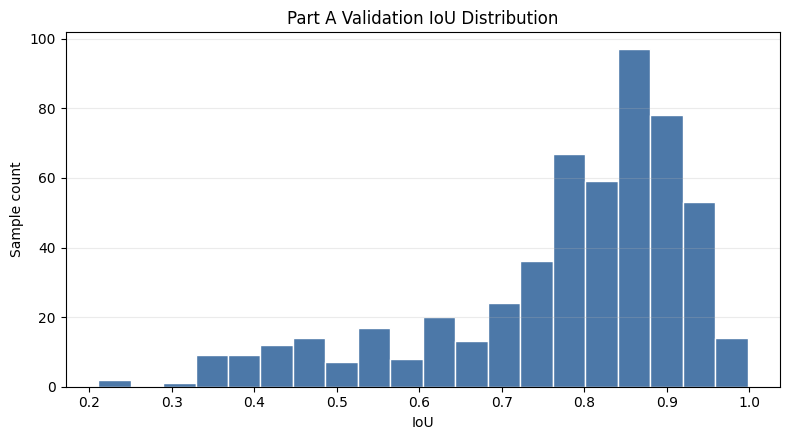

Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/figures/partA_validation_iou_histogram.png


In [28]:
part_a_iou_rows = []
for class_id in [1, 0]:
    for iou in per_class_ious[class_id]:
        part_a_iou_rows.append({"class": CLASS_NAMES[class_id], "iou": iou})

save_dataframe(pd.DataFrame(part_a_iou_rows), RESULTS_TABLES_DIR / "partA_validation_iou_scores.csv", show=False)
plot_metric_histogram(
    [row["iou"] for row in part_a_iou_rows],
    "Part A Validation IoU Distribution",
    "IoU",
    RESULTS_FIGURES_DIR / "partA_validation_iou_histogram.png",
    bins=20,
)


### Part A Error Analysis
This section lists the weakest extraction cases and visualizes ground-truth boxes in green and predicted boxes in red. Low-IoU cases usually come from small shifts, oversized crops, missed detections, or noisy check regions near the amount fields.


In [29]:
part_a_error_records = []
val_image_by_id = {normalize_check_id(path.name): path for path in val_images}

for check_id in sorted(ground_truths):
    for class_id in [1, 0]:
        true_box = ground_truths[check_id][class_id]
        pred_box = predictions[check_id][class_id]
        missed = pred_box == [0, 0, 0, 0]
        iou = 0.0 if missed else calculate_iou(pred_box, true_box)

        if missed or iou < 0.90:
            if missed:
                reason = "missed detection"
            elif iou < 0.50:
                reason = "large localization error"
            elif iou < 0.75:
                reason = "moderate localization error"
            else:
                reason = "small shift below strict IoU"

            part_a_error_records.append({
                "check_id": check_id,
                "class": CLASS_NAMES[class_id],
                "iou": round(float(iou), 4),
                "reason": reason,
                "true_box": true_box,
                "predicted_box": pred_box,
                "image_path": str(val_image_by_id.get(check_id, "")),
            })

part_a_error_records = sorted(part_a_error_records, key=lambda row: row["iou"])
part_a_columns = ["check_id", "class", "iou", "reason", "true_box", "predicted_box"]
display_error_examples(part_a_error_records, part_a_columns, max_examples=10)
write_error_json(PART_A_ERRORS_JSON, part_a_error_records)


,check_id,class,iou,reason,true_box,predicted_box
0,ac01448,courtesy_amount,0.2107,large localization error,"[875, 225, 920, 242]","[839, 218, 960, 248]"
1,ac00982,courtesy_amount,0.2406,large localization error,"[908, 225, 1062, 281]","[940, 233, 1023, 258]"
2,ac00468,courtesy_amount,0.3114,large localization error,"[918, 228, 1056, 265]","[956, 233, 1009, 263]"
3,ac00796,courtesy_amount,0.3324,large localization error,"[883, 215, 960, 236]","[862, 212, 1001, 247]"
4,ac00712,legal_amount,0.3431,large localization error,"[480, 235, 791, 280]","[126, 235, 789, 296]"
5,ac00755,courtesy_amount,0.3461,large localization error,"[937, 232, 1041, 262]","[912, 222, 1108, 268]"
6,ac00646,legal_amount,0.3554,large localization error,"[486, 222, 794, 294]","[295, 225, 784, 340]"
7,ac00560,courtesy_amount,0.3582,large localization error,"[902, 222, 1125, 266]","[952, 226, 1047, 263]"
8,ac01386,courtesy_amount,0.3616,large localization error,"[936, 232, 986, 267]","[903, 229, 1024, 269]"
9,ac00874,courtesy_amount,0.3633,large localization error,"[864, 219, 930, 251]","[823, 217, 994, 251]"


Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/error_analysis/partA_detection_errors.json


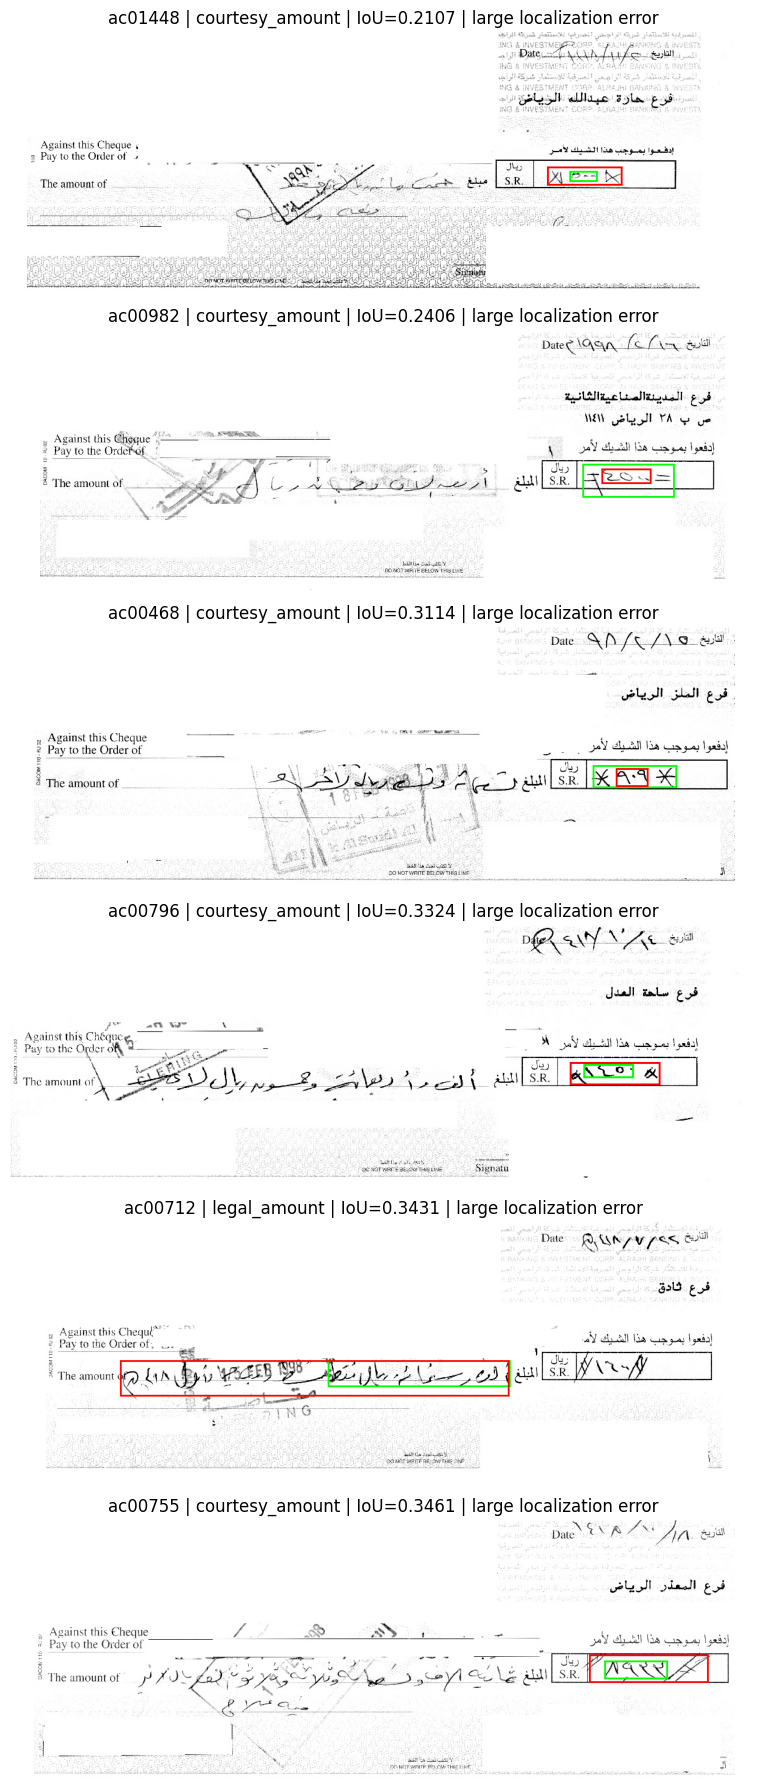

Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/error_analysis/partA_detection_error_examples.png


In [30]:
def show_detection_examples(records, max_examples=6):
    selected = [record for record in records if record.get("image_path") and Path(record["image_path"]).exists()]
    selected = selected[:max_examples]
    if not selected:
        print("No Part-A image examples available.")
        return

    fig, axes = plt.subplots(len(selected), 1, figsize=(12, 3.0 * len(selected)))
    axes = [axes] if len(selected) == 1 else axes

    for ax, record in zip(axes, selected):
        image = Image.open(record["image_path"]).convert("RGB")
        draw = ImageDraw.Draw(image)
        draw.rectangle(record["true_box"], outline="lime", width=3)
        if record["predicted_box"] != [0, 0, 0, 0]:
            draw.rectangle(record["predicted_box"], outline="red", width=3)
        ax.imshow(image)
        ax.axis("off")
        ax.set_title(f"{record['check_id']} | {record['class']} | IoU={record['iou']} | {record['reason']}")

    fig.tight_layout()
    output_path = ERROR_ANALYSIS_DIR / "partA_detection_error_examples.png"
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)

show_detection_examples(part_a_error_records, max_examples=6)


## Part B: Courtesy Amount Recognition

### Crop Courtesy Amount Images


In [31]:
import json
import shutil
from PIL import Image
from ultralytics import YOLO
AMOUNT_IMAGE_EXTENSIONS = {".tif", ".tiff", ".jpg", ".jpeg", ".png"}
PART_A_CONFIDENCE = 0.25

def split_amount_label_line(line):
    stripped = line.strip()
    if not stripped:
        return None
    parts = stripped.split("\t", 1)
    if len(parts) != 2:
        parts = stripped.split(maxsplit=1)
    return parts if len(parts) == 2 else None

def amount_label_ids(label_dir, filename_prefix):
    ids = set()
    row_count = 0
    malformed_rows = []

    for label_path in sorted(Path(label_dir).glob("*.txt")):
        for line_number, line in enumerate(label_path.read_text(encoding="utf-8-sig").splitlines(), start=1):
            parts = split_amount_label_line(line)
            if parts is None:
                if line.strip():
                    malformed_rows.append({"file": label_path.name, "line": line_number, "text": line.strip()})
                continue
            ids.add(normalize_check_id(parts[0], prefix=filename_prefix))
            row_count += 1

    return ids, row_count, malformed_rows

def part_a_detector_weights():
    try:
        return Path(latest_best_model())
    except FileNotFoundError as exc:
        raise FileNotFoundError(
            f"No Part-A YOLO checkpoint found at {PART_A_BEST_MODEL}. "
            "Run the Part-A training cell before cropping recognition patches."
        ) from exc


In [32]:
def clip_prediction_box(box, image_width, image_height):
    x1, y1, x2, y2 = [int(round(value)) for value in box]
    x1 = max(0, min(image_width, x1))
    y1 = max(0, min(image_height, y1))
    x2 = max(0, min(image_width, x2))
    y2 = max(0, min(image_height, y2))
    if x2 <= x1 or y2 <= y1:
        return None
    return [x1, y1, x2, y2]

def best_prediction_for_class(result, target_class):
    best = None
    for box in result.boxes:
        class_id = int(box.cls[0].item())
        if class_id != target_class:
            continue
        confidence = float(box.conf[0].item())
        if best is None or confidence > best["confidence"]:
            best = {"confidence": confidence, "box": box.xyxy[0].tolist()}
    return best


In [33]:
def crop_detected_amounts(label_dir, output_dir, output_prefix, target_class, class_name, audit_path):
    weights_path = part_a_detector_weights()
    model = YOLO(str(weights_path))

    label_ids, label_rows, malformed_rows = amount_label_ids(label_dir, output_prefix)
    source_images = {
        normalize_check_id(path.name): path
        for path in sorted(IMAGES_DIR.iterdir())
        if path.suffix.lower() in AMOUNT_IMAGE_EXTENSIONS
    }

    if output_dir.exists():
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    summary = {
        "class_name": class_name,
        "target_class": target_class,
        "part_a_checkpoint": str(weights_path),
        "confidence_threshold": PART_A_CONFIDENCE,
        "label_rows": label_rows,
        "unique_label_ids": len(label_ids),
        "crops_saved": 0,
        "missing_source_images": [],
        "missed_detections": [],
        "invalid_boxes": [],
        "malformed_label_rows": malformed_rows,
    }

    for check_id in sorted(label_ids):
        image_path = source_images.get(check_id)
        if image_path is None:
            summary["missing_source_images"].append(check_id)
            continue

        with Image.open(image_path) as image:
            image_width, image_height = image.size
            rgb_image = image.convert("RGB")
            result = model.predict(rgb_image, imgsz=640, conf=PART_A_CONFIDENCE, verbose=False)[0]
            prediction = best_prediction_for_class(result, target_class)
            if prediction is None:
                summary["missed_detections"].append(check_id)
                continue
            clipped_box = clip_prediction_box(prediction["box"], image_width, image_height)
            if clipped_box is None:
                summary["invalid_boxes"].append({"check_id": check_id, "box": prediction["box"]})
                continue
            crop = image.crop(clipped_box).convert("L")
            crop.save(output_dir / f"{output_prefix}{check_id}.tif")

        summary["crops_saved"] += 1

    audit_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")

    print(f"Part-A checkpoint: {weights_path}")
    print(f"{class_name} labels: {label_rows} rows, {len(label_ids)} unique IDs")
    print(f"{class_name} crops saved: {summary['crops_saved']} -> {output_dir}")
    print(f"Crop audit saved to: {audit_path}")
    if summary["missing_source_images"] or summary["missed_detections"] or summary["invalid_boxes"]:
        print("Review crop audit before training; some labeled samples were not cropped.")

    return summary


In [34]:
courtesy_crop_summary = crop_detected_amounts(
    label_dir=COURTESY_AMOUNTS_DIR,
    output_dir=COURTESY_IMAGES_DIR,
    output_prefix="C",
    target_class=1,
    class_name="courtesy_amount",
    audit_path=PART_B_CROP_AUDIT,
)

Part-A checkpoint: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/checkpoints/partA_yolov8n/best.pt
courtesy_amount labels: 1799 rows, 1799 unique IDs
courtesy_amount crops saved: 1798 -> /content/arabic_bank_check_work/courtesy_images
Crop audit saved to: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/partB_crop_audit.json
Review crop audit before training; some labeled samples were not cropped.


### Verify Courtesy Crops and Labels


In [35]:
courtesy_label_ids, courtesy_label_rows, courtesy_label_errors = amount_label_ids(COURTESY_AMOUNTS_DIR, "C")
courtesy_crop_ids = {
    normalize_check_id(path.name, prefix="C")
    for path in COURTESY_IMAGES_DIR.iterdir()
    if path.suffix.lower() in AMOUNT_IMAGE_EXTENSIONS
}

missing_crops = sorted(courtesy_label_ids - courtesy_crop_ids)
extra_crops = sorted(courtesy_crop_ids - courtesy_label_ids)
matched_crops = sorted(courtesy_label_ids & courtesy_crop_ids)
print("Courtesy label rows:", courtesy_label_rows)
print("Courtesy unique label IDs:", len(courtesy_label_ids))
print("Courtesy crop images:", len(courtesy_crop_ids))
print("Matched courtesy pairs:", len(matched_crops))
print("Missing courtesy crops:", len(missing_crops))
print("Extra courtesy crops:", len(extra_crops))

if courtesy_label_errors:
    raise ValueError(f"Malformed courtesy label rows found: {courtesy_label_errors[:5]}")
if not matched_crops:
    raise ValueError("No matched courtesy crop/label pairs found. Run the courtesy cropping cell first.")
if missing_crops:
    print("First missing crop IDs:", missing_crops[:10])
if extra_crops:
    print("First extra crop IDs:", extra_crops[:10])

Courtesy label rows: 1799
Courtesy unique label IDs: 1799
Courtesy crop images: 1798
Matched courtesy pairs: 1798
Missing courtesy crops: 1
Extra courtesy crops: 0
First missing crop IDs: ['ac01118']


### Courtesy CRNN Dataloader


In [36]:
import ast
import json
import math
import os
import random
import re
import time
import editdistance
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image, ImageOps
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

In [37]:
COURTESY_BLANK_IDX = 10
COURTESY_IMAGE_SIZE = (32, 160)
COURTESY_BATCH_SIZE = 32

def strip_label_marks(text):
    for mark in ["\ufeff", "\u202a", "\u202b", "\u202c", "‫", "‬"]:
        text = text.replace(mark, "")
    return text.strip()

def parse_courtesy_sequence(sequence_text):
    cleaned = strip_label_marks(sequence_text)
    try:
        parsed = ast.literal_eval(cleaned)
        tokens = parsed if isinstance(parsed, (list, tuple)) else [parsed]
    except Exception:
        tokens = re.findall(r"\d+|[./]", cleaned)
    digits = []
    for token in tokens:
        token_text = str(token).strip()
        if token_text in {"", ".", "/", ","}:
            continue
        if token_text.isdigit():
            value = int(token_text)
            if value == COURTESY_BLANK_IDX:
                continue
            if 0 <= value <= 9:
                digits.append(value)
    return digits

In [38]:
class CourtesyDataset(Dataset):
    def __init__(self, text_dir, image_dir, transform=None):
        self.transform = transform
        self.records = []

        image_map = {
            normalize_check_id(path.name, prefix="C"): path
            for path in sorted(Path(image_dir).iterdir())
            if path.suffix.lower() in AMOUNT_IMAGE_EXTENSIONS
        }

        skipped = []
        for label_path in sorted(Path(text_dir).glob("*.txt")):
            for line_number, line in enumerate(label_path.read_text(encoding="utf-8-sig").splitlines(), start=1):
                parts = split_amount_label_line(line)
                if parts is None:
                    continue

                check_id = normalize_check_id(parts[0], prefix="C")
                image_path = image_map.get(check_id)
                target = parse_courtesy_sequence(parts[1])
                if image_path is None or not target:
                    skipped.append({"file": label_path.name, "line": line_number, "check_id": check_id})
                    continue

                self.records.append({
                    "check_id": check_id,
                    "filename": f"{check_id}.tif",
                    "image_path": image_path,
                    "target": target,
                })

        self.skipped = skipped

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        record = self.records[index]
        image = Image.open(record["image_path"]).convert("L")
        if self.transform is not None:
            image = self.transform(image)
        target = torch.tensor(record["target"], dtype=torch.long)
        return image, target, record["filename"]

def collate_courtesy_batch(batch):
    images, targets, filenames = zip(*batch)
    target_lengths = torch.tensor([len(target) for target in targets], dtype=torch.long)
    padded_targets = torch.nn.utils.rnn.pad_sequence(targets, batch_first=True, padding_value=0)
    return torch.stack(images), padded_targets, target_lengths, filenames

courtesy_transform = transforms.Compose([
    transforms.Resize(COURTESY_IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

In [39]:
courtesy_dataset = CourtesyDataset(
    text_dir=COURTESY_AMOUNTS_DIR,
    image_dir=COURTESY_IMAGES_DIR,
    transform=courtesy_transform,
)

if len(courtesy_dataset) == 0:
    raise ValueError("Courtesy dataset is empty. Run the courtesy cropping cell first.")
if not PART_A_SPLIT.exists():
    raise FileNotFoundError(f"Missing shared split file: {PART_A_SPLIT}. Run Part A dataset preparation first.")

shared_split = json.loads(PART_A_SPLIT.read_text(encoding="utf-8"))
courtesy_index_by_id = {record["check_id"]: index for index, record in enumerate(courtesy_dataset.records)}
courtesy_train_indices = [
    courtesy_index_by_id[check_id]
    for check_id in shared_split["train"]
    if check_id in courtesy_index_by_id
]
courtesy_val_indices = [
    courtesy_index_by_id[check_id]
    for check_id in shared_split["val"]
    if check_id in courtesy_index_by_id
]
missing_courtesy_split_ids = sorted(set(shared_split["train"] + shared_split["val"]) - set(courtesy_index_by_id))

if not courtesy_train_indices or not courtesy_val_indices:
    raise ValueError("Shared Part-A split did not produce non-empty courtesy train/validation subsets.")

courtesy_train_dataset = torch.utils.data.Subset(courtesy_dataset, courtesy_train_indices)
courtesy_val_dataset = torch.utils.data.Subset(courtesy_dataset, courtesy_val_indices)
courtesy_train_ids = [courtesy_dataset.records[index]["check_id"] for index in courtesy_train_indices]
courtesy_val_ids = [courtesy_dataset.records[index]["check_id"] for index in courtesy_val_indices]
courtesy_train_loader = DataLoader(
    courtesy_train_dataset,
    batch_size=COURTESY_BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_courtesy_batch,
    pin_memory=torch.cuda.is_available(),
)

courtesy_val_loader = DataLoader(
    courtesy_val_dataset,
    batch_size=COURTESY_BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_courtesy_batch,
    pin_memory=torch.cuda.is_available(),
)

courtesy_lengths = [len(record["target"]) for record in courtesy_dataset.records]
print("Courtesy matched samples:", len(courtesy_dataset))
print("Courtesy train/validation split:", len(courtesy_train_dataset), len(courtesy_val_dataset))
print("Courtesy validation IDs from shared Part-A split:", len(courtesy_val_ids))
print("Courtesy target length range:", min(courtesy_lengths), "to", max(courtesy_lengths))

if missing_courtesy_split_ids:
    print("Shared split IDs without courtesy crops:", missing_courtesy_split_ids[:20])
if courtesy_dataset.skipped:
    print("Skipped courtesy rows:", len(courtesy_dataset.skipped))

Courtesy matched samples: 1798
Courtesy train/validation split: 1528 270
Courtesy validation IDs from shared Part-A split: 270
Courtesy target length range: 2 to 9
Shared split IDs without courtesy crops: ['ac01118']
Skipped courtesy rows: 1


### Courtesy CRNN Model


In [40]:
class CourtesyCRNN(nn.Module):
    def __init__(self, num_classes=11):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.MaxPool2d((2, 1), (2, 1)),
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True), nn.MaxPool2d((2, 1), (2, 1)),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, None))
        self.rnn = nn.LSTM(512, 256, num_layers=2, bidirectional=True, batch_first=True, dropout=0.2)
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, images):
        features = self.cnn(images)
        sequence = self.pool(features).squeeze(2).permute(0, 2, 1)
        sequence, _ = self.rnn(sequence)
        logits = self.classifier(sequence)
        return logits.log_softmax(2).permute(1, 0, 2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_torch_checkpoint(path):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)

courtesy_model = CourtesyCRNN(num_classes=11).to(device)
print(f"Courtesy CRNN initialized on {device.type.upper()}.")

Courtesy CRNN initialized on CUDA.


### Courtesy CRNN Training


In [41]:
PART_B_EPOCHS = 500
PART_B_PATIENCE = 20
TRAIN_PART_B = True
courtesy_criterion = nn.CTCLoss(blank=COURTESY_BLANK_IDX, zero_infinity=True)
courtesy_optimizer = optim.RMSprop(courtesy_model.parameters(), lr=1e-4)

def run_courtesy_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    total_samples = 0

    for images, targets, target_lengths, _ in loader:
        images = images.to(device)
        targets = targets.to(device)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            outputs = model(images)
            input_lengths = torch.full((images.size(0),), outputs.size(0), dtype=torch.long)
            loss = courtesy_criterion(outputs, targets, input_lengths, target_lengths)

            if training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_samples += images.size(0)

    return total_loss / max(total_samples, 1)

def save_courtesy_checkpoint(path, epoch, train_loss, val_loss, history):
    torch.save(
        {
            "part": "B",
            "epoch": epoch,
            "model_state_dict": courtesy_model.state_dict(),
            "optimizer_state_dict": courtesy_optimizer.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "history": history,
            "blank_idx": COURTESY_BLANK_IDX,
            "image_size": COURTESY_IMAGE_SIZE,
            "num_classes": 11,
        },
        path,
    )

history = []
best_val_loss = math.inf

### Part B Hyperparameter Sweep

Grid: lr in {1e-3, 1e-4} x batch_size in {4, 8} (4 combinations) using AdamW with early-stopping patience 20. Validation set is used here only for hyperparameter selection; the overall-best checkpoint is saved as `PART_B_BEST_MODEL` and feeds the existing evaluation pipeline.

In [42]:
# ---- Part B Hyperparameter Sweep -------------------------------------
# Trains a fresh CourtesyCRNN for each (lr, weight_decay) combination using
# AdamW with early stopping (patience 20). Batch size, optimizer, and
# patience are fixed; learning rate and weight decay are swept. The
# overall-best checkpoint is saved to PART_B_BEST_MODEL so the regular
# evaluation cells downstream pick it up automatically.
RUN_PART_B_HP_SWEEP = True
PART_B_SWEEP_LRS = [1e-3, 1e-4]
PART_B_SWEEP_WEIGHT_DECAYS = [0.0, 1e-4]
PART_B_SWEEP_BATCH_SIZE = 16  # fixed; only learning rate and weight decay are swept
PART_B_SWEEP_PATIENCE = 20
PART_B_SWEEP_MAX_EPOCHS = PART_B_EPOCHS

if RUN_PART_B_HP_SWEEP:
    print(
        f"Part B sweep: {len(PART_B_SWEEP_LRS) * len(PART_B_SWEEP_WEIGHT_DECAYS)} combos | "
        f"batch_size={PART_B_SWEEP_BATCH_SIZE} | AdamW | "
        f"patience {PART_B_SWEEP_PATIENCE} | max_epochs {PART_B_SWEEP_MAX_EPOCHS}"
    )
    part_b_sweep_results = []
    part_b_overall_best = {"val_loss": math.inf, "lr": None, "weight_decay": None,
                          "batch_size": None, "epoch": None, "state_dict": None,
                          "history": None}

    sweep_bs = PART_B_SWEEP_BATCH_SIZE
    for sweep_lr in PART_B_SWEEP_LRS:
        for sweep_wd in PART_B_SWEEP_WEIGHT_DECAYS:
            print(f"\n[Part B sweep] lr={sweep_lr}, weight_decay={sweep_wd}, batch_size={sweep_bs}, optimizer=AdamW")

            sweep_train_loader = DataLoader(
                courtesy_train_dataset,
                batch_size=sweep_bs,
                shuffle=True,
                collate_fn=collate_courtesy_batch,
                pin_memory=torch.cuda.is_available(),
            )
            sweep_val_loader = DataLoader(
                courtesy_val_dataset,
                batch_size=sweep_bs,
                shuffle=False,
                collate_fn=collate_courtesy_batch,
                pin_memory=torch.cuda.is_available(),
            )

            sweep_model = CourtesyCRNN(num_classes=11).to(device)
            sweep_optimizer = optim.AdamW(sweep_model.parameters(), lr=sweep_lr, weight_decay=sweep_wd)
            sweep_criterion = nn.CTCLoss(blank=COURTESY_BLANK_IDX, zero_infinity=True)

            combo_best_loss = math.inf
            combo_best_state = None
            combo_best_epoch = 0
            combo_history = []
            stale = 0
            last_epoch = 0
            for epoch in range(1, PART_B_SWEEP_MAX_EPOCHS + 1):
                sweep_model.train()
                running_loss = 0.0
                running_n = 0
                for images, targets, target_lengths, _ in sweep_train_loader:
                    images = images.to(device)
                    targets = targets.to(device)
                    sweep_optimizer.zero_grad(set_to_none=True)
                    outputs = sweep_model(images)
                    input_lengths = torch.full((images.size(0),), outputs.size(0), dtype=torch.long)
                    loss = sweep_criterion(outputs, targets, input_lengths, target_lengths)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(sweep_model.parameters(), max_norm=5.0)
                    sweep_optimizer.step()
                    running_loss += loss.item() * images.size(0)
                    running_n += images.size(0)
                train_loss = running_loss / max(running_n, 1)

                sweep_model.eval()
                running_loss = 0.0
                running_n = 0
                with torch.no_grad():
                    for images, targets, target_lengths, _ in sweep_val_loader:
                        images = images.to(device)
                        targets = targets.to(device)
                        outputs = sweep_model(images)
                        input_lengths = torch.full((images.size(0),), outputs.size(0), dtype=torch.long)
                        loss = sweep_criterion(outputs, targets, input_lengths, target_lengths)
                        running_loss += loss.item() * images.size(0)
                        running_n += images.size(0)
                val_loss = running_loss / max(running_n, 1)

                last_epoch = epoch
                combo_history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
                if val_loss < combo_best_loss - 1e-4:
                    combo_best_loss = val_loss
                    combo_best_epoch = epoch
                    combo_best_state = {k: v.detach().cpu().clone() for k, v in sweep_model.state_dict().items()}
                    stale = 0
                else:
                    stale += 1
                print(f"  epoch {epoch:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | best={combo_best_loss:.4f}")
                if stale >= PART_B_SWEEP_PATIENCE:
                    print(f"  early stop at epoch {epoch}")
                    break

            part_b_sweep_results.append({
                "lr": sweep_lr,
                "weight_decay": sweep_wd,
                "batch_size": sweep_bs,
                "optimizer": "AdamW",
                "patience": PART_B_SWEEP_PATIENCE,
                "best_val_loss": combo_best_loss,
                "best_epoch": combo_best_epoch,
                "epochs_run": last_epoch,
            })
            if combo_best_loss < part_b_overall_best["val_loss"]:
                part_b_overall_best = {
                    "val_loss": combo_best_loss,
                    "lr": sweep_lr,
                    "weight_decay": sweep_wd,
                    "batch_size": sweep_bs,
                    "epoch": combo_best_epoch,
                    "state_dict": combo_best_state,
                    "history": list(combo_history),
                }

    part_b_sweep_frame = pd.DataFrame(part_b_sweep_results)
    PART_B_SWEEP_XLSX = RESULTS_TABLES_DIR / "partB_hp_sweep.xlsx"
    PART_B_SWEEP_PNG = RESULTS_FIGURES_DIR / "partB_hp_sweep.png"
    part_b_sweep_frame.to_excel(PART_B_SWEEP_XLSX, index=False)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    bar_labels = [f"lr={row['lr']:.0e}, wd={row['weight_decay']:.0e}" for row in part_b_sweep_results]
    bar_values = [row["best_val_loss"] for row in part_b_sweep_results]
    bars = ax.barh(bar_labels, bar_values, color="#4C78A8", edgecolor="white")
    ax.set_xlabel("Best validation CTC loss (lower is better)")
    ax.set_title("Part B Hyperparameter Sweep — AdamW, patience 20")
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.25)
    for bar, value in zip(bars, bar_values):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
                f"{value:.4f}", va="center", fontsize=9)
    fig.tight_layout()
    fig.savefig(PART_B_SWEEP_PNG, dpi=200, bbox_inches="tight")
    plt.close(fig)

    courtesy_model.load_state_dict(part_b_overall_best["state_dict"])
    history = part_b_overall_best["history"]
    best_val_loss = part_b_overall_best["val_loss"]
    save_courtesy_checkpoint(
        PART_B_BEST_MODEL,
        part_b_overall_best["epoch"],
        history[-1]["train_loss"] if history else 0.0,
        best_val_loss,
        history,
    )
    save_courtesy_checkpoint(
        PART_B_LAST_MODEL,
        part_b_overall_best["epoch"],
        history[-1]["train_loss"] if history else 0.0,
        best_val_loss,
        history,
    )
    TRAIN_PART_B = False
    print(
        f"\n[Part B sweep] best lr={part_b_overall_best['lr']}, "
        f"weight_decay={part_b_overall_best['weight_decay']}, "
        f"batch_size={part_b_overall_best['batch_size']}, "
        f"val_loss={best_val_loss:.4f} (epoch {part_b_overall_best['epoch']})"
    )
    print(f"Saved: {PART_B_SWEEP_XLSX}")
    print(f"Saved: {PART_B_SWEEP_PNG}")
    print(f"Best checkpoint written to: {PART_B_BEST_MODEL}")


Part B sweep: 4 combos | batch_size=16 | AdamW | patience 20 | max_epochs 500

[Part B sweep] lr=0.001, weight_decay=0.0, batch_size=16, optimizer=AdamW
  epoch 001 | train_loss=2.5313 | val_loss=3.4448 | best=3.4448
  epoch 002 | train_loss=1.9885 | val_loss=1.9207 | best=1.9207
  epoch 003 | train_loss=1.6764 | val_loss=1.8037 | best=1.8037
  epoch 004 | train_loss=0.9471 | val_loss=0.8810 | best=0.8810
  epoch 005 | train_loss=0.5204 | val_loss=0.4925 | best=0.4925
  epoch 006 | train_loss=0.3145 | val_loss=0.4088 | best=0.4088
  epoch 007 | train_loss=0.2283 | val_loss=0.4024 | best=0.4024
  epoch 008 | train_loss=0.2352 | val_loss=0.3068 | best=0.3068
  epoch 009 | train_loss=0.1758 | val_loss=0.2564 | best=0.2564
  epoch 010 | train_loss=0.1382 | val_loss=0.2564 | best=0.2564
  epoch 011 | train_loss=0.1166 | val_loss=0.2924 | best=0.2564
  epoch 012 | train_loss=0.1162 | val_loss=0.3097 | best=0.2564
  epoch 013 | train_loss=0.0874 | val_loss=0.2847 | best=0.2564
  epoch 014 | t

In [43]:
stale_epochs = 0

if TRAIN_PART_B:
    print(f"Training Part B for up to {PART_B_EPOCHS} epochs with early stopping patience {PART_B_PATIENCE}.")
    for epoch in range(1, PART_B_EPOCHS + 1):
        train_loss = run_courtesy_epoch(courtesy_model, courtesy_train_loader, courtesy_optimizer)
        with torch.no_grad():
            val_loss = run_courtesy_epoch(courtesy_model, courtesy_val_loader, optimizer=None)

        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
        save_courtesy_checkpoint(PART_B_LAST_MODEL, epoch, train_loss, val_loss, history)

        improved = val_loss < best_val_loss - 1e-4
        if improved:
            best_val_loss = val_loss
            stale_epochs = 0
            save_courtesy_checkpoint(PART_B_BEST_MODEL, epoch, train_loss, val_loss, history)
        else:
            stale_epochs += 1

        print(f"Epoch {epoch:03d}/{PART_B_EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | best_val={best_val_loss:.4f}")

        if stale_epochs >= PART_B_PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break
else:
    if not PART_B_BEST_MODEL.exists():
        raise FileNotFoundError(f"TRAIN_PART_B is False, but no checkpoint exists at {PART_B_BEST_MODEL}")
    print(f"Skipping Part B training and using existing checkpoint: {PART_B_BEST_MODEL}")

part_b_info = {
    "part": "B",
    "task": "courtesy_amount_recognition",
    "model": "CNN-BiLSTM-CTC",
    "optimizer": "RMSprop",
    "learning_rate": 1e-4,
    "max_epochs": PART_B_EPOCHS,
    "early_stopping_patience": PART_B_PATIENCE,
    "blank_idx": COURTESY_BLANK_IDX,
    "image_size": COURTESY_IMAGE_SIZE,
    "train_fraction": TRAIN_FRACTION,
    "validation_fraction": VALIDATION_FRACTION,
    "split_seed": SPLIT_SEED,
    "train_count": len(courtesy_train_dataset),
    "validation_count": len(courtesy_val_dataset),
    "train_ids": courtesy_train_ids,
    "validation_ids": courtesy_val_ids,
    "best_checkpoint": str(PART_B_BEST_MODEL),
    "last_checkpoint": str(PART_B_LAST_MODEL),
    "output_file": str(PART_B_OUTPUT),
    "metrics_file": str(PART_B_METRICS),
}

PART_B_MODEL_INFO.write_text(json.dumps(part_b_info, ensure_ascii=False, indent=2), encoding="utf-8")
print("Part-B checkpoints:", PART_B_CHECKPOINT_DIR)

Skipping Part B training and using existing checkpoint: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/checkpoints/partB_courtesy_crnn/best.pt
Part-B checkpoints: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/checkpoints/partB_courtesy_crnn


### Courtesy CRNN Evaluation


In [44]:
def decode_courtesy_batch(log_probs, blank_idx=COURTESY_BLANK_IDX):
    predictions = log_probs.argmax(2).permute(1, 0)
    decoded = []
    for sequence in predictions:
        previous = None
        digits = []
        for value in sequence.tolist():
            if value != previous and value != blank_idx:
                digits.append(str(value))
            previous = value
        decoded.append("".join(digits))
    return decoded

if not PART_B_BEST_MODEL.exists():
    raise FileNotFoundError(f"Part-B checkpoint not found: {PART_B_BEST_MODEL}")

checkpoint = torch.load(PART_B_BEST_MODEL, map_location=device)
courtesy_model.load_state_dict(checkpoint["model_state_dict"])
courtesy_model.eval()
output_lines = []
total_digits = 0
total_errors = 0
error_counts = {0: 0, 1: 0, "2+": 0}

with torch.no_grad():
    for images, targets, target_lengths, filenames in courtesy_val_loader:
        images = images.to(device)
        outputs = courtesy_model(images)
        predicted_strings = decode_courtesy_batch(outputs)

        for row_index, predicted in enumerate(predicted_strings):
            ground_truth = "".join(str(value) for value in targets[row_index, : target_lengths[row_index]].tolist())
            output_lines.append(f"{filenames[row_index]} {predicted}")

            errors = editdistance.eval(predicted, ground_truth)
            total_digits += len(ground_truth)
            total_errors += errors
            if errors == 0:
                error_counts[0] += 1
            elif errors == 1:
                error_counts[1] += 1
            else:
                error_counts["2+"] += 1

sample_count = sum(error_counts.values())

if sample_count == 0 or total_digits == 0:
    raise ValueError("No Part-B validation samples were evaluated.")

digit_accuracy = (1 - total_errors / total_digits) * 100


In [45]:
metrics_lines = [
    "PART B - COURTESY AMOUNT RECOGNITION",
    f"Checkpoint: {PART_B_BEST_MODEL}",
    f"Validation samples: {sample_count}",
    f"Total ground-truth digits: {total_digits}",
    f"Total edit errors: {total_errors}",
    f"Digit-level accuracy (%): {digit_accuracy:.4f}",
    f"Amounts with no errors: {error_counts[0]} ({error_counts[0] / sample_count * 100:.4f}%)",
    f"Amounts with one error: {error_counts[1]} ({error_counts[1] / sample_count * 100:.4f}%)",
    f"Amounts with two or more errors: {error_counts['2+']} ({error_counts['2+'] / sample_count * 100:.4f}%)",
]

PART_B_OUTPUT.write_text("\n".join(output_lines) + "\n", encoding="utf-8")
PART_B_METRICS.write_text("\n".join(metrics_lines) + "\n", encoding="utf-8")
print("\n".join(metrics_lines))
print("Part-B output saved to:", PART_B_OUTPUT)
print("Part-B metrics saved to:", PART_B_METRICS)
print("Sample output:")

for line in output_lines[:5]:
    print(" ", line)

PART B - COURTESY AMOUNT RECOGNITION
Checkpoint: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/checkpoints/partB_courtesy_crnn/best.pt
Validation samples: 270
Total ground-truth digits: 1208
Total edit errors: 65
Digit-level accuracy (%): 94.6192
Amounts with no errors: 221 (81.8519%)
Amounts with one error: 36 (13.3333%)
Amounts with two or more errors: 13 (4.8148%)
Part-B output saved to: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/partB_output.txt
Part-B metrics saved to: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/partB_metrics.txt
Sample output:
  ac00122.tif 5750
  ac01303.tif 6510
  ac01460.tif 3000
  ac00147.tif 38084
  ac00014.tif 3003


### Save Part B Result Tables and Training Curves
Courtesy recognition metrics, training history, and loss curves are saved under `results/`.


Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/tables/partB_validation_metrics.csv
Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/json/partB_validation_metrics.json
Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/tables/partB_training_history.csv


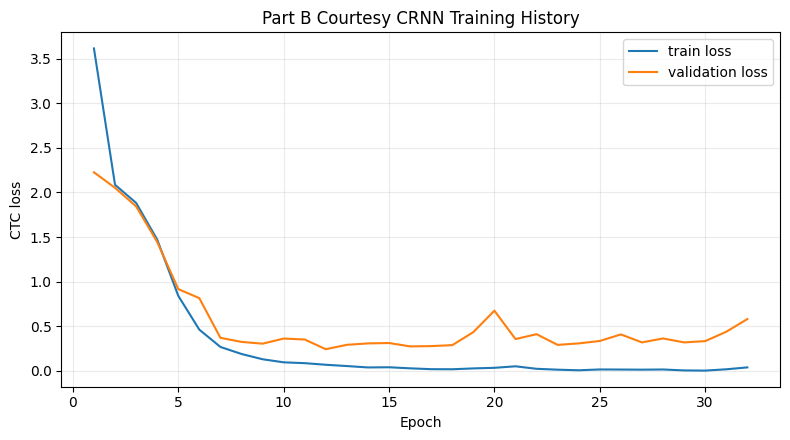

Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/figures/partB_training_history.png


In [46]:
part_b_sample_count = sample_count
part_b_error_counts = dict(error_counts)
part_b_digit_accuracy = digit_accuracy

part_b_metrics_summary = {
    "part": "B",
    "split": "validation",
    "samples": part_b_sample_count,
    "total_digits": total_digits,
    "total_edit_errors": total_errors,
    "digit_level_accuracy_percent": part_b_digit_accuracy,
    "amount_level_accuracy_percent": part_b_error_counts[0] / part_b_sample_count * 100,
    "one_error_percent": part_b_error_counts[1] / part_b_sample_count * 100,
    "two_or_more_errors_percent": part_b_error_counts["2+"] / part_b_sample_count * 100,
}
part_b_metrics_frame = save_dataframe(pd.DataFrame([part_b_metrics_summary]), RESULTS_TABLES_DIR / "partB_validation_metrics.csv")
save_metrics_json(RESULTS_JSON_DIR / "partB_validation_metrics.json", part_b_metrics_summary)

if history:
    save_dataframe(pd.DataFrame(history), RESULTS_TABLES_DIR / "partB_training_history.csv", show=False)
    plot_training_history(history, "Part B Courtesy CRNN Training History", RESULTS_FIGURES_DIR / "partB_training_history.png")

### Part B Error Analysis
This section follows the report-style courtesy analysis: digit-level confusion matrix, insertion/deletion/substitution counts, and incorrectly predicted courtesy samples.


,check_id,true_label,predicted_label,edit_count,insertions,deletions,substitutions,operations
0,ac00547,25000,20,3,0,3,0,D:5; D:0; D:0
1,ac00947,2310,4515,3,0,0,3,S:2->4; S:3->5; S:0->5
2,ac01805,121017,110,3,0,3,0,D:2; D:1; D:7
3,ac00697,428750,4287,2,0,2,0,D:5; D:0
4,ac00755,8922,8933,2,0,0,2,S:2->3; S:2->3
5,ac00766,33333,33322,2,0,0,2,S:3->2; S:3->2
6,ac00936,5944360,5644320,2,0,0,2,S:9->6; S:6->2
7,ac00948,600,40,2,0,1,1,D:6; S:0->4
8,ac01386,1000,310007,2,2,0,0,I:3; I:7
9,ac01520,6472,6275,2,0,0,2,S:4->2; S:2->5


Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/error_analysis/partB_courtesy_errors.json
Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/tables/partB_validation_error_analysis.csv


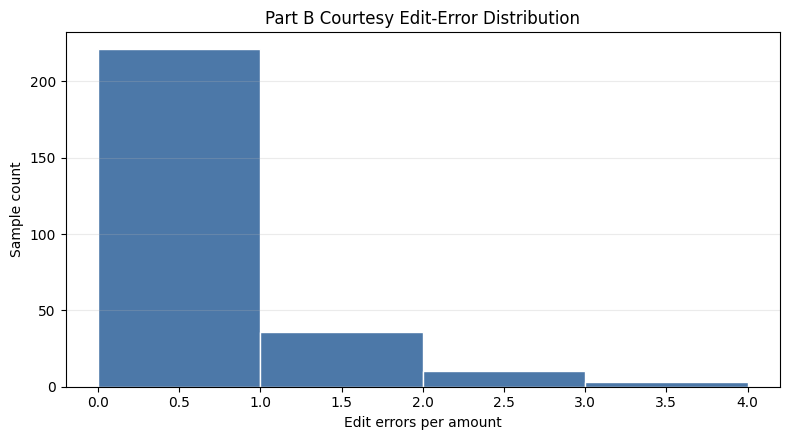

Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/figures/partB_edit_error_histogram.png


In [47]:
part_b_analysis_records = []
courtesy_image_by_id = {record["check_id"]: str(record["image_path"]) for record in courtesy_dataset.records}

with torch.no_grad():
    for images, targets, target_lengths, filenames in courtesy_val_loader:
        images = images.to(device)
        outputs = courtesy_model(images)
        predicted_strings = decode_courtesy_batch(outputs)

        for row_index, predicted in enumerate(predicted_strings):
            target_length = int(target_lengths[row_index].item())
            true_digits = "".join(str(value) for value in targets[row_index, :target_length].tolist())
            summary = alignment_summary(true_digits, predicted)
            check_id = normalize_check_id(filenames[row_index], prefix="C")
            part_b_analysis_records.append({
                "check_id": check_id,
                "true_label": true_digits,
                "predicted_label": predicted,
                "edit_count": summary["edit_count"],
                "insertions": summary["insertions"],
                "deletions": summary["deletions"],
                "substitutions": summary["substitutions"],
                "operations": summary["operations"],
                "image_path": courtesy_image_by_id.get(check_id, ""),
            })

part_b_error_records = sorted(
    [record for record in part_b_analysis_records if record["edit_count"] > 0],
    key=lambda row: (-row["edit_count"], row["check_id"]),
)
part_b_columns = [
    "check_id", "true_label", "predicted_label", "edit_count",
    "insertions", "deletions", "substitutions", "operations",
]
display_error_examples(part_b_error_records, part_b_columns, max_examples=10)
write_error_json(PART_B_ERRORS_JSON, part_b_error_records)


save_dataframe(pd.DataFrame(part_b_analysis_records), RESULTS_TABLES_DIR / "partB_validation_error_analysis.csv", show=False)
plot_metric_histogram(
    [record["edit_count"] for record in part_b_analysis_records],
    "Part B Courtesy Edit-Error Distribution",
    "Edit errors per amount",
    RESULTS_FIGURES_DIR / "partB_edit_error_histogram.png",
    bins=range(0, max(record["edit_count"] for record in part_b_analysis_records) + 2),
)


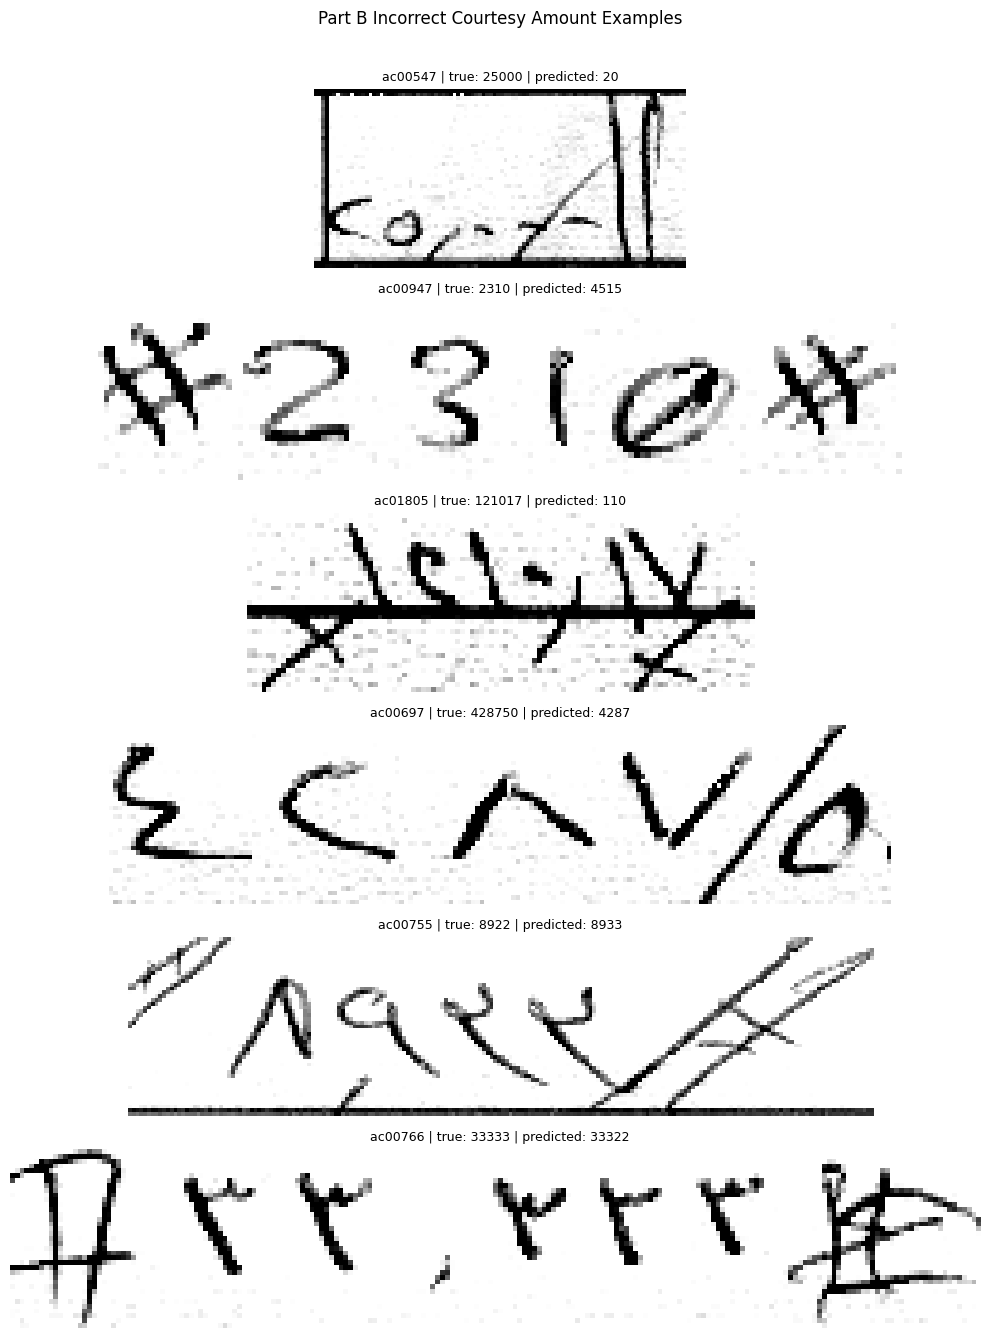

In [48]:
show_crop_examples(
    part_b_error_records,
    image_key="image_path",
    true_key="true_label",
    pred_key="predicted_label",
    title="Part B Incorrect Courtesy Amount Examples",
    max_examples=6,
)

## Part C: Legal Amount Recognition

### Crop Legal Amount Images


In [49]:
if "crop_detected_amounts" not in globals():
    raise RuntimeError("Run the recognition cropping helper cell before Part C cropping.")

legal_crop_summary = crop_detected_amounts(
    label_dir=LEGAL_AMOUNTS_DIR,
    output_dir=LEGAL_IMAGES_DIR,
    output_prefix="L",
    target_class=0,
    class_name="legal_amount",
    audit_path=PART_C_CROP_AUDIT,
)


Part-A checkpoint: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/checkpoints/partA_yolov8n/best.pt
legal_amount labels: 1799 rows, 1799 unique IDs
legal_amount crops saved: 1798 -> /content/arabic_bank_check_work/legal_images
Crop audit saved to: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/partC_crop_audit.json
Review crop audit before training; some labeled samples were not cropped.


### Legal Token Vocabulary and Dataset Setup


In [50]:
LEGAL_BLANK_IDX = 0
LEGAL_IMAGE_SIZE = (140, 1340)
LEGAL_SEQUENCE_STEPS = 84
LEGAL_BATCH_SIZE = 4
LEGAL_EPOCHS = 500
LEGAL_PATIENCE = 20
TRAIN_PART_C = True

def parse_legal_tokens(sequence_text):
    cleaned = strip_label_marks(sequence_text)
    try:
        parsed = ast.literal_eval(cleaned)
        if isinstance(parsed, (list, tuple)):
            return [str(token).strip() for token in parsed if str(token).strip()]
    except Exception:
        pass
    return [token for token in cleaned.split() if token]

ARABIC_NORMALIZATION_MAP = str.maketrans({
    "آ": "ا",  # ALEF WITH MADDA -> ALEF
    "أ": "ا",  # ALEF WITH HAMZA ABOVE -> ALEF
    "إ": "ا",  # ALEF WITH HAMZA BELOW -> ALEF
    "ٱ": "ا",  # ALEF WASLA -> ALEF
    "ى": "ي",  # ALEF MAKSURA -> YA
    "ئ": "ي",  # YA WITH HAMZA -> YA
    "ؤ": "و",  # WAW WITH HAMZA -> WAW
})

def normalize_legal_text(text):
    """Restrict legal text to the Arabic alphabet used in amount labels.

    Strips digits, punctuation and any other non-Arabic characters, and
    merges hamza/alif/ya variants so that the character vocabulary matches
    the ~24-class set used in the report (sec. 7.4, Fig. 12).
    """
    text = text.translate(ARABIC_NORMALIZATION_MAP)
    return "".join(ch for ch in text if "ء" <= ch <= "ي")

def normalize_legal_token(token):
    return normalize_legal_text(token)

def legal_text_from_tokens(tokens):
    return normalize_legal_text("".join(tokens))

def load_legal_records(text_dir, image_dir):
    image_map = {
        normalize_check_id(path.name, prefix="L"): path
        for path in sorted(Path(image_dir).iterdir())
        if path.suffix.lower() in AMOUNT_IMAGE_EXTENSIONS
    }

    records = []
    skipped = []
    for label_path in sorted(Path(text_dir).glob("*.txt")):
        for line_number, line in enumerate(label_path.read_text(encoding="utf-8-sig").splitlines(), start=1):
            parts = split_amount_label_line(line)
            if parts is None:
                continue

            check_id = normalize_check_id(parts[0], prefix="L")
            image_path = image_map.get(check_id)
            raw_tokens = parse_legal_tokens(parts[1])
            tokens = [normalize_legal_token(token) for token in raw_tokens]
            tokens = [token for token in tokens if token]
            target_text = legal_text_from_tokens(tokens)
            if image_path is None or not target_text:
                skipped.append({"file": label_path.name, "line": line_number, "check_id": check_id})
                continue

            records.append({
                "check_id": check_id,
                "filename": f"{check_id}.tif",
                "image_path": image_path,
                "tokens": tokens,
                "target_text": target_text,
            })

    return records, skipped


In [51]:
legal_records, legal_skipped = load_legal_records(LEGAL_AMOUNTS_DIR, LEGAL_IMAGES_DIR)

if not legal_records:
    raise ValueError("Legal dataset is empty. Run the legal cropping cell first.")

legal_chars = sorted({character for record in legal_records for character in record["target_text"]})
legal_char_to_idx = {character: index + 1 for index, character in enumerate(legal_chars)}
legal_idx_to_char = {index + 1: character for index, character in enumerate(legal_chars)}
legal_num_classes = len(legal_chars) + 1
legal_max_target_length = max(len(record["target_text"]) for record in legal_records)
legal_token_vocabulary = sorted(
    {token for record in legal_records for token in record["tokens"]},
    key=lambda token: (-len(token), token),
)

if legal_max_target_length > LEGAL_SEQUENCE_STEPS:
    raise ValueError(
        f"Legal max target length is {legal_max_target_length}, which exceeds the configured "
        f"CTC sequence length {LEGAL_SEQUENCE_STEPS}."
    )

class LegalDataset(Dataset):
    def __init__(self, records, char_to_idx, transform=None):
        self.records = records
        self.char_to_idx = char_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        record = self.records[index]
        image = Image.open(record["image_path"]).convert("L")
        image = ImageOps.mirror(image)
        if self.transform is not None:
            image = self.transform(image)
        target = torch.tensor([self.char_to_idx[character] for character in record["target_text"]], dtype=torch.long)
        return image, target, record["filename"], record["tokens"]

def collate_legal_batch(batch):
    images, targets, filenames, token_lists = zip(*batch)
    target_lengths = torch.tensor([len(target) for target in targets], dtype=torch.long)
    padded_targets = torch.nn.utils.rnn.pad_sequence(targets, batch_first=True, padding_value=0)
    return torch.stack(images), padded_targets, target_lengths, filenames, token_lists

legal_transform = transforms.Compose([
    transforms.Resize(LEGAL_IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])


### Legal Dataloader


In [52]:
legal_dataset = LegalDataset(legal_records, legal_char_to_idx, transform=legal_transform)
if not PART_A_SPLIT.exists():
    raise FileNotFoundError(f"Missing shared split file: {PART_A_SPLIT}. Run Part A dataset preparation first.")

shared_split = json.loads(PART_A_SPLIT.read_text(encoding="utf-8"))
legal_index_by_id = {record["check_id"]: index for index, record in enumerate(legal_dataset.records)}
legal_train_indices = [
    legal_index_by_id[check_id]
    for check_id in shared_split["train"]
    if check_id in legal_index_by_id
]
legal_val_indices = [
    legal_index_by_id[check_id]
    for check_id in shared_split["val"]
    if check_id in legal_index_by_id
]
missing_legal_split_ids = sorted(set(shared_split["train"] + shared_split["val"]) - set(legal_index_by_id))

if not legal_train_indices or not legal_val_indices:
    raise ValueError("Shared Part-A split did not produce non-empty legal train/validation subsets.")

legal_train_dataset = torch.utils.data.Subset(legal_dataset, legal_train_indices)
legal_val_dataset = torch.utils.data.Subset(legal_dataset, legal_val_indices)
legal_train_ids = [legal_dataset.records[index]["check_id"] for index in legal_train_indices]
legal_val_ids = [legal_dataset.records[index]["check_id"] for index in legal_val_indices]
legal_train_loader = DataLoader(
    legal_train_dataset,
    batch_size=LEGAL_BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_legal_batch,
    pin_memory=torch.cuda.is_available(),
)

legal_val_loader = DataLoader(
    legal_val_dataset,
    batch_size=LEGAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_legal_batch,
    pin_memory=torch.cuda.is_available(),
)

print("Legal matched samples:", len(legal_dataset))
print("Legal vocabulary size including blank:", len(legal_idx_to_char))
print("Legal train/validation split:", len(legal_train_dataset), len(legal_val_dataset))
print("Legal validation IDs from shared Part-A split:", len(legal_val_ids))

if missing_legal_split_ids:
    print("Shared split IDs without legal crops:", missing_legal_split_ids[:20])


Legal matched samples: 1798
Legal vocabulary size including blank: 28
Legal train/validation split: 1528 270
Legal validation IDs from shared Part-A split: 270
Shared split IDs without legal crops: ['ac00756']


### Legal CRNN Model


In [53]:
def conv_bn_relu(in_channels, out_channels, kernel_size=3, padding=1):
    return [
        nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
    ]

class LegalCRNN(nn.Module):
    def __init__(self, num_classes, sequence_steps=LEGAL_SEQUENCE_STEPS):
        super().__init__()
        layers = []
        block_plan = [
            (1, 32, 2, (2, 2)),
            (32, 64, 3, (2, 2)),
            (64, 128, 3, (2, 2)),
            (128, 256, 3, (2, 1)),
            (256, 512, 4, None),
        ]
        for in_channels, out_channels, repeats, pool in block_plan:
            current_in = in_channels
            for _ in range(repeats):
                layers.extend(conv_bn_relu(current_in, out_channels))
                current_in = out_channels
            if pool is not None:
                layers.append(nn.MaxPool2d(pool, pool))

        self.cnn = nn.Sequential(*layers)
        self.sequence_pool = nn.AdaptiveAvgPool2d((1, sequence_steps))
        self.rnn = nn.LSTM(512, 256, num_layers=2, bidirectional=True, batch_first=True, dropout=0.2)
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, images):
        features = self.cnn(images)
        sequence = self.sequence_pool(features).squeeze(2).permute(0, 2, 1)
        sequence, _ = self.rnn(sequence)
        logits = self.classifier(sequence)
        return logits.log_softmax(2).permute(1, 0, 2)

legal_model = LegalCRNN(legal_num_classes).to(device)
legal_criterion = nn.CTCLoss(blank=LEGAL_BLANK_IDX, zero_infinity=True)
legal_optimizer = optim.Adam(legal_model.parameters(), lr=1e-4)
legal_scheduler = optim.lr_scheduler.StepLR(legal_optimizer, step_size=10000, gamma=0.9)


### Legal Training Helpers


In [54]:
def run_legal_epoch(model, loader, optimizer=None, scheduler=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    total_samples = 0

    for images, targets, target_lengths, _, _ in loader:
        images = images.to(device)
        targets = targets.to(device)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            outputs = model(images)
            input_lengths = torch.full((images.size(0),), outputs.size(0), dtype=torch.long)
            loss = legal_criterion(outputs, targets, input_lengths, target_lengths)

            if training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
                if scheduler is not None:
                    scheduler.step()

        total_loss += loss.item() * images.size(0)
        total_samples += images.size(0)

    return total_loss / max(total_samples, 1)

def save_legal_checkpoint(path, epoch, train_loss, val_loss, history):
    torch.save(
        {
            "part": "C",
            "epoch": epoch,
            "model_state_dict": legal_model.state_dict(),
            "optimizer_state_dict": legal_optimizer.state_dict(),
            "scheduler_state_dict": legal_scheduler.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "history": history,
            "blank_idx": LEGAL_BLANK_IDX,
            "image_size": LEGAL_IMAGE_SIZE,
            "sequence_steps": LEGAL_SEQUENCE_STEPS,
            "num_classes": legal_num_classes,
            "char_to_idx": legal_char_to_idx,
            "idx_to_char": legal_idx_to_char,
            "token_vocabulary": legal_token_vocabulary,
        },
        path,
    )

legal_history = []
legal_best_val_loss = math.inf
legal_stale_epochs = 0


### Legal CRNN Training


### Part C Hyperparameter Sweep

Same grid as Part B (lr {1e-3, 1e-4} x batch_size {4, 8}, AdamW, patience 20). Saves the overall-best LegalCRNN checkpoint to `PART_C_BEST_MODEL`.

In [57]:
# ---- Part C Hyperparameter Sweep -------------------------------------
# Same protocol as Part B: AdamW with early stopping (patience 20),
# learning rate and weight decay are swept. The overall-best LegalCRNN
# checkpoint is saved to PART_C_BEST_MODEL.
RUN_PART_C_HP_SWEEP = True
PART_C_SWEEP_LRS = [1e-3, 1e-4]
PART_C_SWEEP_WEIGHT_DECAYS = [0.0, 1e-4]
PART_C_SWEEP_BATCH_SIZE = 16  # fixed; only learning rate and weight decay are swept
PART_C_SWEEP_PATIENCE = 20
PART_C_SWEEP_MAX_EPOCHS = LEGAL_EPOCHS

if RUN_PART_C_HP_SWEEP:
    print(
        f"Part C sweep: {len(PART_C_SWEEP_LRS) * len(PART_C_SWEEP_WEIGHT_DECAYS)} combos | "
        f"batch_size={PART_C_SWEEP_BATCH_SIZE} | AdamW | "
        f"patience {PART_C_SWEEP_PATIENCE} | max_epochs {PART_C_SWEEP_MAX_EPOCHS}"
    )
    part_c_sweep_results = []
    part_c_overall_best = {"val_loss": math.inf, "lr": None, "weight_decay": None,
                          "batch_size": None, "epoch": None, "state_dict": None,
                          "history": None}

    sweep_bs = PART_C_SWEEP_BATCH_SIZE
    for sweep_lr in PART_C_SWEEP_LRS:
        for sweep_wd in PART_C_SWEEP_WEIGHT_DECAYS:
            print(f"\n[Part C sweep] lr={sweep_lr}, weight_decay={sweep_wd}, batch_size={sweep_bs}, optimizer=AdamW")

            sweep_train_loader = DataLoader(
                legal_train_dataset,
                batch_size=sweep_bs,
                shuffle=True,
                collate_fn=collate_legal_batch,
                pin_memory=torch.cuda.is_available(),
            )
            sweep_val_loader = DataLoader(
                legal_val_dataset,
                batch_size=sweep_bs,
                shuffle=False,
                collate_fn=collate_legal_batch,
                pin_memory=torch.cuda.is_available(),
            )

            sweep_model = LegalCRNN(legal_num_classes).to(device)
            sweep_optimizer = optim.AdamW(sweep_model.parameters(), lr=sweep_lr, weight_decay=sweep_wd)
            sweep_scheduler = optim.lr_scheduler.StepLR(sweep_optimizer, step_size=10000, gamma=0.9)
            sweep_criterion = nn.CTCLoss(blank=LEGAL_BLANK_IDX, zero_infinity=True)

            combo_best_loss = math.inf
            combo_best_state = None
            combo_best_epoch = 0
            combo_history = []
            stale = 0
            last_epoch = 0
            for epoch in range(1, PART_C_SWEEP_MAX_EPOCHS + 1):
                sweep_model.train()
                running_loss = 0.0
                running_n = 0
                # Fixed: Unpack 5 values (images, targets, target_lengths, filenames, token_lists)
                for images, targets, target_lengths, _, _ in sweep_train_loader:
                    images = images.to(device)
                    targets = targets.to(device)
                    sweep_optimizer.zero_grad(set_to_none=True)
                    outputs = sweep_model(images)
                    input_lengths = torch.full((images.size(0),), outputs.size(0), dtype=torch.long)
                    loss = sweep_criterion(outputs, targets, input_lengths, target_lengths)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(sweep_model.parameters(), max_norm=5.0)
                    sweep_optimizer.step()
                    sweep_scheduler.step()
                    running_loss += loss.item() * images.size(0)
                    running_n += images.size(0)
                train_loss = running_loss / max(running_n, 1)

                sweep_model.eval()
                running_loss = 0.0
                running_n = 0
                with torch.no_grad():
                    # Fixed: Unpack 5 values
                    for images, targets, target_lengths, _, _ in sweep_val_loader:
                        images = images.to(device)
                        targets = targets.to(device)
                        outputs = sweep_model(images)
                        input_lengths = torch.full((images.size(0),), outputs.size(0), dtype=torch.long)
                        loss = sweep_criterion(outputs, targets, input_lengths, target_lengths)
                        running_loss += loss.item() * images.size(0)
                        running_n += images.size(0)
                val_loss = running_loss / max(running_n, 1)

                last_epoch = epoch
                combo_history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
                if val_loss < combo_best_loss - 1e-4:
                    combo_best_loss = val_loss
                    combo_best_epoch = epoch
                    combo_best_state = {k: v.detach().cpu().clone() for k, v in sweep_model.state_dict().items()}
                    stale = 0
                else:
                    stale += 1
                print(f"  epoch {epoch:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | best={combo_best_loss:.4f}")
                if stale >= PART_C_SWEEP_PATIENCE:
                    print(f"  early stop at epoch {epoch}")
                    break

            part_c_sweep_results.append({
                "lr": sweep_lr,
                "weight_decay": sweep_wd,
                "batch_size": sweep_bs,
                "optimizer": "AdamW",
                "patience": PART_C_SWEEP_PATIENCE,
                "best_val_loss": combo_best_loss,
                "best_epoch": combo_best_epoch,
                "epochs_run": last_epoch,
            })
            if combo_best_loss < part_c_overall_best["val_loss"]:
                part_c_overall_best = {
                    "val_loss": combo_best_loss,
                    "lr": sweep_lr,
                    "weight_decay": sweep_wd,
                    "batch_size": sweep_bs,
                    "epoch": combo_best_epoch,
                    "state_dict": combo_best_state,
                    "history": list(combo_history),
                }

    part_c_sweep_frame = pd.DataFrame(part_c_sweep_results)
    PART_C_SWEEP_XLSX = RESULTS_TABLES_DIR / "partC_hp_sweep.xlsx"
    PART_C_SWEEP_PNG = RESULTS_FIGURES_DIR / "partC_hp_sweep.png"
    part_c_sweep_frame.to_excel(PART_C_SWEEP_XLSX, index=False)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    bar_labels = [f"lr={row['lr']:.0e}, wd={row['weight_decay']:.0e}" for row in part_c_sweep_results]
    bar_values = [row["best_val_loss"] for row in part_c_sweep_results]
    bars = ax.barh(bar_labels, bar_values, color="#4C78A8", edgecolor="white")
    ax.set_xlabel("Best validation CTC loss (lower is better)")
    ax.set_title("Part C Hyperparameter Sweep — AdamW, patience 20")
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.25)
    for bar, value in zip(bars, bar_values):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
                f"{value:.4f}", va="center", fontsize=9)
    fig.tight_layout()
    fig.savefig(PART_C_SWEEP_PNG, dpi=200, bbox_inches="tight")
    plt.close(fig)

    legal_model.load_state_dict(part_c_overall_best["state_dict"])
    legal_history = part_c_overall_best["history"]
    legal_best_val_loss = part_c_overall_best["val_loss"]
    save_legal_checkpoint(
        PART_C_BEST_MODEL,
        part_c_overall_best["epoch"],
        legal_history[-1]["train_loss"] if legal_history else 0.0,
        legal_best_val_loss,
        legal_history,
    )
    save_legal_checkpoint(
        PART_C_LAST_MODEL,
        part_c_overall_best["epoch"],
        legal_history[-1]["train_loss"] if legal_history else 0.0,
        legal_best_val_loss,
        legal_history,
    )
    TRAIN_PART_C = False
    print(
        f"\n[Part C sweep] best lr={part_c_overall_best['lr']}, "
        f"weight_decay={part_c_overall_best['weight_decay']}, "
        f"batch_size={part_c_overall_best['batch_size']}, "
        f"val_loss={legal_best_val_loss:.4f} (epoch {part_c_overall_best['epoch']})"
    )
    print(f"Saved: {PART_C_SWEEP_XLSX}")
    print(f"Saved: {PART_C_SWEEP_PNG}")
    print(f"Best checkpoint written to: {PART_C_BEST_MODEL}")

Part C sweep: 4 combos | batch_size=16 | AdamW | patience 20 | max_epochs 500

[Part C sweep] lr=0.001, weight_decay=0.0, batch_size=16, optimizer=AdamW
  epoch 001 | train_loss=2.9734 | val_loss=2.7099 | best=2.7099
  epoch 002 | train_loss=2.4895 | val_loss=2.9558 | best=2.7099
  epoch 003 | train_loss=2.1592 | val_loss=2.0243 | best=2.0243
  epoch 004 | train_loss=1.8451 | val_loss=2.4129 | best=2.0243
  epoch 005 | train_loss=1.6845 | val_loss=1.7494 | best=1.7494
  epoch 006 | train_loss=1.5133 | val_loss=1.5547 | best=1.5547
  epoch 007 | train_loss=1.3598 | val_loss=1.7056 | best=1.5547
  epoch 008 | train_loss=1.2223 | val_loss=1.3291 | best=1.3291
  epoch 009 | train_loss=1.0632 | val_loss=1.1539 | best=1.1539
  epoch 010 | train_loss=0.9214 | val_loss=1.0749 | best=1.0749
  epoch 011 | train_loss=0.8371 | val_loss=1.0162 | best=1.0162
  epoch 012 | train_loss=0.7625 | val_loss=0.9984 | best=0.9984
  epoch 013 | train_loss=0.7009 | val_loss=0.9428 | best=0.9428
  epoch 014 | t

In [58]:
if TRAIN_PART_C:
    print(f"Training Part C for up to {LEGAL_EPOCHS} epochs with early stopping patience {LEGAL_PATIENCE}.")
    for epoch in range(1, LEGAL_EPOCHS + 1):
        train_loss = run_legal_epoch(legal_model, legal_train_loader, legal_optimizer, legal_scheduler)
        with torch.no_grad():
            val_loss = run_legal_epoch(legal_model, legal_val_loader, optimizer=None)

        legal_history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
        save_legal_checkpoint(PART_C_LAST_MODEL, epoch, train_loss, val_loss, legal_history)

        improved = val_loss < legal_best_val_loss - 1e-4
        if improved:
            legal_best_val_loss = val_loss
            legal_stale_epochs = 0
            save_legal_checkpoint(PART_C_BEST_MODEL, epoch, train_loss, val_loss, legal_history)
        else:
            legal_stale_epochs += 1

        print(f"Epoch {epoch:03d}/{LEGAL_EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | best_val={legal_best_val_loss:.4f}")

        if legal_stale_epochs >= LEGAL_PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break
else:
    if not PART_C_BEST_MODEL.exists():
        raise FileNotFoundError(f"TRAIN_PART_C is False, but no checkpoint exists at {PART_C_BEST_MODEL}")
    print(f"Skipping Part C training and using existing checkpoint: {PART_C_BEST_MODEL}")

part_c_info = {
    "part": "C",
    "task": "legal_amount_recognition",
    "model": "15-convolution-layer CNN-BiLSTM-CTC",
    "optimizer": "Adam",
    "learning_rate": 1e-4,
    "lr_decay_factor": 0.9,
    "lr_decay_steps": 10000,
    "max_epochs": LEGAL_EPOCHS,
    "early_stopping_patience": LEGAL_PATIENCE,
    "blank_idx": LEGAL_BLANK_IDX,
    "image_size": LEGAL_IMAGE_SIZE,
    "sequence_steps": LEGAL_SEQUENCE_STEPS,
    "max_target_length": legal_max_target_length,
    "num_classes_including_blank": legal_num_classes,
    "train_fraction": TRAIN_FRACTION,
    "validation_fraction": VALIDATION_FRACTION,
    "split_seed": SPLIT_SEED,
    "train_count": len(legal_train_dataset),
    "validation_count": len(legal_val_dataset),
    "train_ids": legal_train_ids,
    "validation_ids": legal_val_ids,
    "best_checkpoint": str(PART_C_BEST_MODEL),
    "last_checkpoint": str(PART_C_LAST_MODEL),
    "output_file": str(PART_C_OUTPUT),
    "metrics_file": str(PART_C_METRICS),
    "char_to_idx": legal_char_to_idx,
}

PART_C_MODEL_INFO.write_text(json.dumps(part_c_info, ensure_ascii=False, indent=2), encoding="utf-8")
print("Part-C checkpoints:", PART_C_CHECKPOINT_DIR)


Skipping Part C training and using existing checkpoint: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/checkpoints/partC_legal_crnn/best.pt
Part-C checkpoints: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/checkpoints/partC_legal_crnn


### Legal Decoding and Evaluation


In [59]:
def decode_legal_batch(log_probs, idx_to_char, blank_idx=LEGAL_BLANK_IDX):
    predictions = log_probs.argmax(2).permute(1, 0)
    decoded = []
    for sequence in predictions:
        previous = None
        characters = []
        for value in sequence.tolist():
            if value != previous and value != blank_idx:
                characters.append(idx_to_char.get(value, ""))
            previous = value
        decoded.append("".join(characters))
    return decoded

def segment_with_legal_vocabulary(text, vocabulary):
    tokens = []
    position = 0
    while position < len(text):
        match = None
        for token in vocabulary:
            if text.startswith(token, position):
                match = token
                break
        if match is None:
            tokens.append(text[position])
            position += 1
        else:
            tokens.append(match)
            position += len(match)
    return tokens

if not PART_C_BEST_MODEL.exists():
    raise FileNotFoundError(f"Part-C checkpoint not found: {PART_C_BEST_MODEL}")

checkpoint = torch.load(PART_C_BEST_MODEL, map_location=device)
loaded_idx_to_char = {int(key): value for key, value in checkpoint["idx_to_char"].items()}
loaded_token_vocabulary = checkpoint.get("token_vocabulary", legal_token_vocabulary)
legal_model.load_state_dict(checkpoint["model_state_dict"])
legal_model.eval()
output_lines = []
total_characters = 0
total_character_errors = 0
total_tokens = 0
total_token_errors = 0
exact_character_matches = 0


In [60]:
with torch.no_grad():
    for images, targets, target_lengths, filenames, token_lists in legal_val_loader:
        images = images.to(device)
        outputs = legal_model(images)
        predicted_strings = decode_legal_batch(outputs, loaded_idx_to_char)

        for row_index, predicted in enumerate(predicted_strings):
            ground_truth = "".join(
                loaded_idx_to_char[int(value)]
                for value in targets[row_index, : target_lengths[row_index]].tolist()
            )
            output_lines.append(f"{filenames[row_index]} {predicted}")

            character_errors = editdistance.eval(predicted, ground_truth)
            total_characters += len(ground_truth)
            total_character_errors += character_errors
            exact_character_matches += int(character_errors == 0)

            predicted_tokens = segment_with_legal_vocabulary(predicted, loaded_token_vocabulary)
            ground_truth_tokens = list(token_lists[row_index])
            token_errors = editdistance.eval(predicted_tokens, ground_truth_tokens)
            total_tokens += len(ground_truth_tokens)
            total_token_errors += token_errors

sample_count = len(output_lines)

if sample_count == 0 or total_characters == 0 or total_tokens == 0:
    raise ValueError("No Part-C validation samples were evaluated.")

cer = total_character_errors / total_characters * 100
wer = total_token_errors / total_tokens * 100
exact_rate = exact_character_matches / sample_count * 100
metrics_lines = [
    "PART C - LEGAL AMOUNT RECOGNITION",
    f"Checkpoint: {PART_C_BEST_MODEL}",
    f"Validation samples: {sample_count}",
    f"Total ground-truth characters: {total_characters}",
    f"Total character edit errors: {total_character_errors}",
    f"CER (%): {cer:.4f}",
    f"Total ground-truth legal tokens: {total_tokens}",
    f"Total token edit errors: {total_token_errors}",
    f"WER / token error rate (%): {wer:.4f}",
    f"Exact character-sequence matches: {exact_character_matches} ({exact_rate:.4f}%)",
]

PART_C_OUTPUT.write_text("\n".join(output_lines) + "\n", encoding="utf-8")
PART_C_METRICS.write_text("\n".join(metrics_lines) + "\n", encoding="utf-8")
print("\n".join(metrics_lines))
print("Part-C output saved to:", PART_C_OUTPUT)
print("Part-C metrics saved to:", PART_C_METRICS)
print("Sample output:")


PART C - LEGAL AMOUNT RECOGNITION
Checkpoint: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/checkpoints/partC_legal_crnn/best.pt
Validation samples: 270
Total ground-truth characters: 7768
Total character edit errors: 1508
CER (%): 19.4130
Total ground-truth legal tokens: 3870
Total token edit errors: 2139
WER / token error rate (%): 55.2713
Exact character-sequence matches: 37 (13.7037%)
Part-C output saved to: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/partC_output.txt
Part-C metrics saved to: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/partC_metrics.txt
Sample output:


### Save Part C Result Tables and Training Curves
Legal recognition metrics, training history, and loss curves are saved under `results/`.


Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/tables/partC_validation_metrics.csv
Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/json/partC_validation_metrics.json
Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/tables/partC_training_history.csv


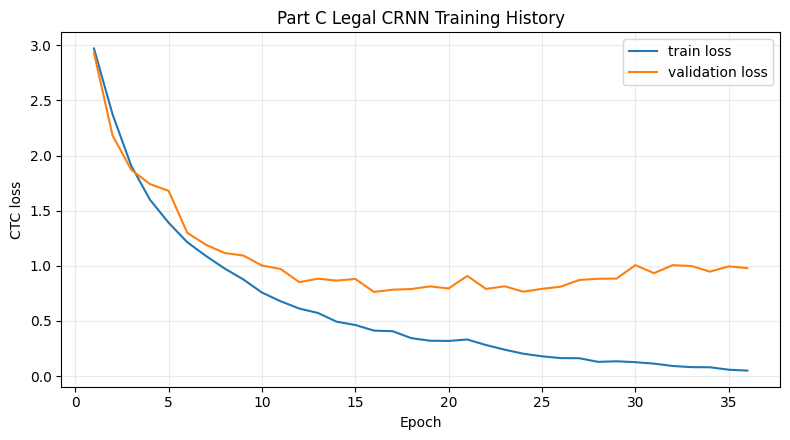

Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/figures/partC_training_history.png


In [61]:
part_c_sample_count = sample_count
part_c_cer = cer
part_c_wer = wer
part_c_exact_rate = exact_rate

part_c_metrics_summary = {
    "part": "C",
    "split": "validation",
    "samples": part_c_sample_count,
    "total_characters": total_characters,
    "total_character_errors": total_character_errors,
    "cer_percent": part_c_cer,
    "total_tokens": total_tokens,
    "total_token_errors": total_token_errors,
    "wer_percent": part_c_wer,
    "exact_character_match_percent": part_c_exact_rate,
}
part_c_metrics_frame = save_dataframe(pd.DataFrame([part_c_metrics_summary]), RESULTS_TABLES_DIR / "partC_validation_metrics.csv")
save_metrics_json(RESULTS_JSON_DIR / "partC_validation_metrics.json", part_c_metrics_summary)

if legal_history:
    save_dataframe(pd.DataFrame(legal_history), RESULTS_TABLES_DIR / "partC_training_history.csv", show=False)
    plot_training_history(legal_history, "Part C Legal CRNN Training History", RESULTS_FIGURES_DIR / "partC_training_history.png")


In [62]:
for line in output_lines[:5]:
    print(" ", line)


  ac00122.tif فقطخمسةالافوسبعمايةوخمسونرياللاغير
  ac01303.tif سةالافوسمايةوسنلير
  ac01460.tif ثلاثةالفرياللاغير
  ac00147.tif ثلاثةالافوثمانمايةواربعهةوثمانونرياللاغير
  ac00014.tif ثلاثالافريالغير


### Part C Error Analysis
This section provides the legal-recognition error analysis requested in the report: a character confusion matrix with insertions/deletions and examples of token-level legal recognition errors. The active `LegalAmounts/` labels are subword tokens without explicit word-boundary labels, so the notebook reports CER plus a WER-style legal token error rate from the available annotations.


In [63]:
part_c_analysis_records = []
legal_image_by_id = {record["check_id"]: str(record["image_path"]) for record in legal_dataset.records}

with torch.no_grad():
    for images, targets, target_lengths, filenames, token_lists in legal_val_loader:
        images = images.to(device)
        outputs = legal_model(images)
        predicted_strings = decode_legal_batch(outputs, loaded_idx_to_char)

        for row_index, predicted in enumerate(predicted_strings):
            target_length = int(target_lengths[row_index].item())
            true_text = "".join(
                loaded_idx_to_char[int(value)]
                for value in targets[row_index, :target_length].tolist()
            )
            predicted_tokens = segment_with_legal_vocabulary(predicted, loaded_token_vocabulary)
            true_tokens = list(token_lists[row_index])
            char_summary = alignment_summary(true_text, predicted)
            token_summary = alignment_summary(true_tokens, predicted_tokens)
            check_id = normalize_check_id(filenames[row_index], prefix="L")
            part_c_analysis_records.append({
                "check_id": check_id,
                "true_text": true_text,
                "predicted_text": predicted,
                "true_tokens": " | ".join(true_tokens),
                "predicted_tokens": " | ".join(predicted_tokens),
                "character_errors": char_summary["edit_count"],
                "token_errors": token_summary["edit_count"],
                "operations": token_summary["operations"],
                "image_path": legal_image_by_id.get(check_id, ""),
            })

part_c_error_records = sorted(
    [record for record in part_c_analysis_records if record["token_errors"] > 0],
    key=lambda row: (-row["token_errors"], -row["character_errors"], row["check_id"]),
)


,check_id,true_text,predicted_text,token_errors,character_errors,true_tokens,predicted_tokens,operations
0,ac00455,فقطمايهوستةعشرالفوستمايهوتسعهوتسعونريالوثمانيه...,فقطمايةوستةعشرالفوستال,21,40,فقط | مايه | و | ست | ة | عشر | ا | لف | و | س...,فقط | ماية | و | ست | ة | عشر | الف | و | ست |...,S:مايه->ماية; D:ا; D:لف; D:و; D:ستمايه; D:و; D...
1,ac01447,اربعةالافوتسعمايهواثنانوتسعونرياللاغير,وقطاربعرعونالفوسوماوالوخماناللاغير,20,22,اربع | ة | ا | لا | ف | و | تسعمايه | و | اثن ...,و | ق | ط | اربع | ر | ع | و | ن | الف | و | س...,I:و; I:ق; I:ط; I:ر; S:ة->ع; S:ا->و; S:لا->ن; S...
2,ac00749,ستهالافواربعمايهوواحدوثلاثينوخمسهوعشرونهللة,سةولوافومسنريالليلاغير,17,33,سته | ا | لا | ف | و | اربعمايه | و | واحد | و...,س | ة | و | ل | و | ا | ف | و | م | س | ن | ر ...,S:سته->س; S:ا->ة; S:لا->و; S:ف->ل; D:اربعمايه;...
3,ac01311,عشرةالافوثلاثميةوثمانخمسونريالفقطلاغيررحبابهم,سةالفالامايةوسونريلولفلاغير,17,25,عشر | ة | ا | لا | ف | و | ثلاثمي | ة | و | ثم...,س | ة | الفا | لا | ماية | و | س | و | ن | ر |...,S:عشر->س; S:ا->الفا; D:ف; D:و; D:ثلاثمي; S:ة->...
4,ac00220,اربعةالافومايتانوسبعةوثمانونريالوهللة,اربعةالافوبعورالوسرنريللاغير,17,20,اربع | ة | ا | لا | ف | و | مايت | ا | ن | و |...,اربعة | الاف | و | ب | ع | و | ر | ا | ل | و |...,S:اربع->اربعة; S:ة->الاف; S:ا->و; S:لا->ب; S:ف...
5,ac01795,فقطستةوعشرونالفاوستةواربعونرياللاغير,خقطالفةوونالفخمريلاغير,16,21,فقط | ست | ة | و | عشر | و | ن | الفا | و | ست...,خ | ق | ط | الف | ة | و | و | ن | الف | خ | م ...,S:فقط->خ; S:ست->ق; S:ة->ط; S:و->الف; S:عشر->ة;...
6,ac00331,فقطتسعهوخمسونالفواربعمايهواربعهوسبعونريالوهلله...,فقطتسعةوخمسونالفواربعايةواربعةوسعون,16,19,فقط | تسعه | و | خمس | و | ن | ا | لف | و | ار...,فقط | تسع | ة | و | خمس | و | ن | الف | و | ار...,I:تسع; S:تسعه->ة; D:ا; S:لف->الف; D:اربعمايه; ...
7,ac01520,وقدرهستةالافواربعمايهواثنانوسبعونريالفقط,وقدسةالافواربمايةوثماناووناللاغير,16,18,وقدره | ست | ة | ا | لا | ف | و | اربعمايه | و...,و | ق | د | س | ة | الاف | و | ا | ر | ب | ماي...,I:و; I:ق; S:وقدره->د; S:ست->س; I:الاف; S:ا->و;...
8,ac00898,خمسهوخمسونالفوثلاثمايهوستهوثلاثونرياللاغير,خمسةورالنرياير,15,30,خمسه | و | خمس | و | ن | ا | لف | و | ثلاثمايه...,خمس | ة | و | ر | ا | ل | ن | ر | يا | ي | ر,D:خمسه; D:و; D:و; D:ن; D:ا; D:لف; D:و; S:ثلاثم...
9,ac01053,ثلاثةالافوستمايةواثنينواربعينريال,فقطثلاثةالفومسريالاغ,15,23,ثلاث | ة | الاف | و | ستماي | ة | و | اثن | ي ...,فقط | ثلاث | ة | الف | و | م | س | ريالا | غ,D:ثلاث; D:ة; D:الاف; S:و->فقط; S:ستماي->ثلاث; ...


Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/error_analysis/partC_legal_errors.json
Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/tables/partC_validation_error_analysis.csv


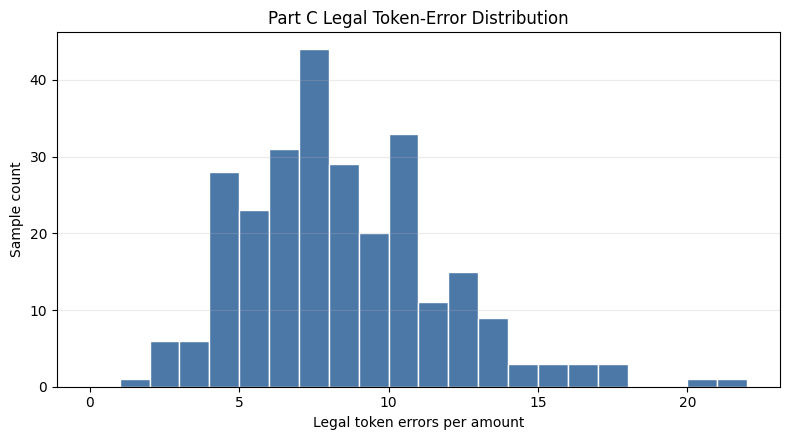

Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/figures/partC_token_error_histogram.png


In [64]:
part_c_columns = [
    "check_id", "true_text", "predicted_text", "token_errors",
    "character_errors", "true_tokens", "predicted_tokens", "operations",
]
display_error_examples(part_c_error_records, part_c_columns, max_examples=10)
write_error_json(PART_C_ERRORS_JSON, part_c_error_records)


save_dataframe(pd.DataFrame(part_c_analysis_records), RESULTS_TABLES_DIR / "partC_validation_error_analysis.csv", show=False)
plot_metric_histogram(
    [record["token_errors"] for record in part_c_analysis_records],
    "Part C Legal Token-Error Distribution",
    "Legal token errors per amount",
    RESULTS_FIGURES_DIR / "partC_token_error_histogram.png",
    bins=range(0, max(record["token_errors"] for record in part_c_analysis_records) + 2),
)


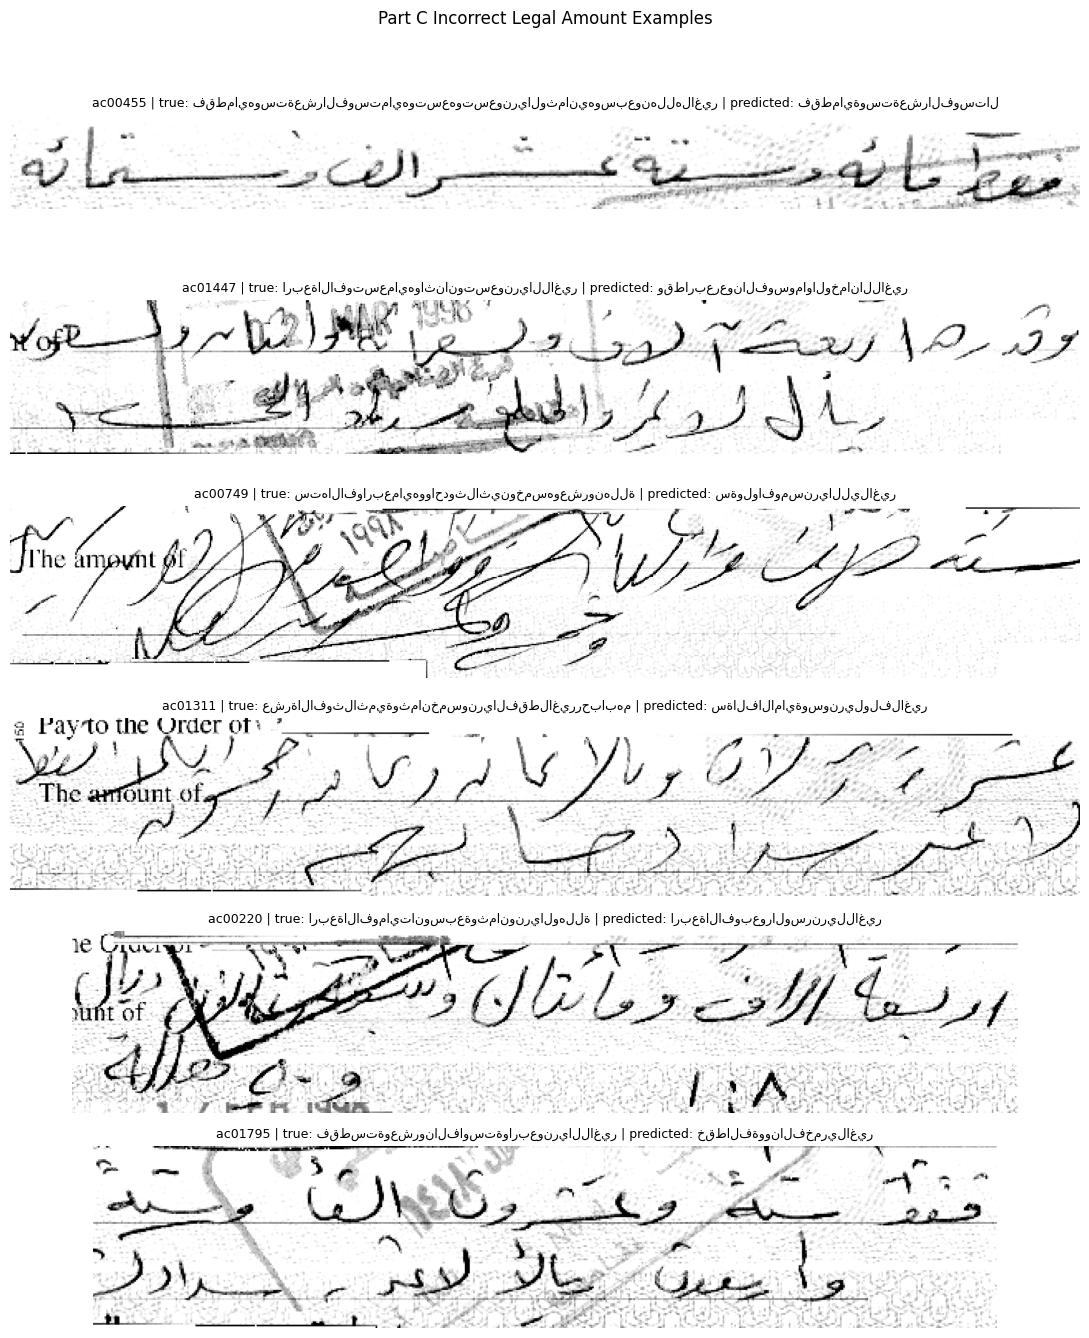

In [65]:
show_crop_examples(
    part_c_error_records,
    image_key="image_path",
    true_key="true_text",
    pred_key="predicted_text",
    title="Part C Incorrect Legal Amount Examples",
    max_examples=6,
)


## Part D: Final Verification

### Legal Amount Conversion Rules


In [66]:
import ast
import itertools
import json
import os
import re
print("\n--- PART D: Final Legal-Courtesy Verification ---")
ARABIC_DIGIT_TRANSLATION = str.maketrans("٠١٢٣٤٥٦٧٨٩", "0123456789")
ARABIC_NORMALIZATION = str.maketrans({
    "أ": "ا",
    "إ": "ا",
    "آ": "ا",
    "ٱ": "ا",
    "ى": "ي",
    "ة": "ه",
    "ؤ": "و",
    "ئ": "ي",
    "ً": "",
    "َ": "",
    "ُ": "",
    "ِ": "",
    "ّ": "",
    "ْ": "",
    "ـ": "",
})

def clean_hidden_marks(text):
    text = str(text)
    for mark in ["\ufeff", "\u202a", "\u202b", "\u202c", "‫", "‬"]:
        text = text.replace(mark, "")
    return text.strip()

def normalize_arabic_text(text):
    text = clean_hidden_marks(text)
    text = text.translate(ARABIC_DIGIT_TRANSLATION).translate(ARABIC_NORMALIZATION)
    text = text.replace("⁄", "/").replace("،", " ").replace("#", " ")
    text = re.sub(r"[^0-9\u0600-\u06FF/ ]+", " ", text)
    return " ".join(text.split())

def compact_token(text):
    return normalize_arabic_text(text).replace(" ", "")

WORD_VALUES = {}
SCALE_VALUES = {}



--- PART D: Final Legal-Courtesy Verification ---


In [67]:
def add_word_values(words, value):
    for word in words:
        WORD_VALUES[compact_token(word)] = value

def add_scale_values(words, scale, dual=False):
    for word in words:
        SCALE_VALUES[compact_token(word)] = {"scale": scale, "dual": dual}

add_word_values(["صفر"], 0)
add_word_values(["واحد", "واحده", "احد", "احدى"], 1)
add_word_values(["اثنان", "اثنين", "اثنا", "اثني", "اثنتان", "اثنتين", "اثنتا", "ثنين"], 2)
add_word_values(["ثلاثه", "ثلاثة", "ثلاث"], 3)
add_word_values(["اربعه", "اربعة", "اربع"], 4)
add_word_values(["خمسه", "خمسة", "خمس"], 5)
add_word_values(["سته", "ستة", "ست"], 6)
add_word_values(["سبعه", "سبعة", "سبع"], 7)
add_word_values(["ثمانيه", "ثمانية", "ثماني", "ثمان"], 8)
add_word_values(["تسعه", "تسعة", "تسع"], 9)
add_word_values(["عشره", "عشرة", "عشر"], 10)
add_word_values(["عشرون", "عشرين"], 20)
add_word_values(["ثلاثون", "ثلاثين"], 30)
add_word_values(["اربعون", "اربعين"], 40)
add_word_values(["خمسون", "خمسين"], 50)
add_word_values(["ستون", "ستين"], 60)
add_word_values(["سبعون", "سبعين"], 70)
add_word_values(["ثمانون", "ثمانين"], 80)
add_word_values(["تسعون", "تسعين"], 90)
# Hundreds are scale tokens (×100) per the report's Algorithm 1 — compound forms (ثلاثمائه=300, etc.) remain in WORD_VALUES below.
add_word_values(["مائتان", "مائتين", "مئتان", "مئتين", "مائتا", "مئتا"], 200)


In [68]:
for prefix, value in [
    ("ثلاث", 300),
    ("اربع", 400),
    ("خمس", 500),
    ("ست", 600),
    ("سبع", 700),
    ("ثمان", 800),
    ("تسع", 900),
]:
    add_word_values(
        [prefix + suffix for suffix in ["مائه", "مائة", "مئه", "مئة", "مايه", "مائ"]],
        value,
    )

add_scale_values(["مائه", "مائة", "مئه", "مئة", "مايه", "ميه"], 100)
add_scale_values(["الف", "الاف"], 1000)
add_scale_values(["الفان", "الفين", "الفا", "الفي"], 1000, dual=True)
add_scale_values(["مليون", "ملايين"], 1_000_000)
add_scale_values(["مليونان", "مليونين"], 1_000_000, dual=True)
RIAL_TOKENS = {compact_token(word) for word in ["ريال", "ريالات", "ريالا", "ريالاً"]}
HALALA_TOKENS = {compact_token(word) for word in ["هلله", "هللة", "هلل", "هللات", "للات"]}
FILLER_TOKENS = {compact_token(word) for word in [
    "و",
    "فقط",
    "لا",
    "غير",
    "لاغير",
    "وقدره",
    "قدره",
    "مبلغ",
    "سعودي",
    "على",
    "الحساب",
    "دفعه",
]}
IGNORED_TOKENS = RIAL_TOKENS | HALALA_TOKENS | FILLER_TOKENS
DICTIONARY_TOKENS = sorted(
    set(WORD_VALUES) | set(SCALE_VALUES) | IGNORED_TOKENS,
    key=lambda token: (-len(token), token),
)

FUZZY_DICTIONARY = sorted(set(WORD_VALUES) | set(SCALE_VALUES) | RIAL_TOKENS | HALALA_TOKENS | FILLER_TOKENS)

def legal_output_to_text(text):
    cleaned = clean_hidden_marks(text)
    try:
        parsed = ast.literal_eval(cleaned)
        if isinstance(parsed, (list, tuple)):
            return "".join(str(token) for token in parsed)
    except Exception:
        pass
    return cleaned


In [69]:
def segment_compact_word(word):
    word = compact_token(word)
    tokens = []
    position = 0

    while position < len(word):
        if word[position].isdigit():
            end = position + 1
            while end < len(word) and (word[end].isdigit() or word[end] == "/"):
                end += 1
            tokens.append(word[position:end])
            position = end
            continue

        if word[position] == "و" and position + 1 < len(word):
            tokens.append("و")
            position += 1
            continue

        match = None
        for candidate in DICTIONARY_TOKENS:
            if candidate and word.startswith(candidate, position):
                match = candidate
                break

        if match is not None:
            tokens.append(match)
            position += len(match)
            continue

        end = position + 1
        while end < len(word) and word[end] != "و" and not word[end].isdigit():
            end += 1
        tokens.append(word[position:end])
        position = end

    return [token for token in tokens if token]

def segment_legal_text(text):
    text = legal_output_to_text(text)
    normalized = normalize_arabic_text(text)
    tokens = []
    for part in normalized.split():
        tokens.extend(segment_compact_word(part))
    return [token for token in tokens if token]


In [70]:
import functools
def edit_distance(a, b):
    try:
        return editdistance.eval(a, b)
    except NameError:
        previous = list(range(len(b) + 1))
        for i, ca in enumerate(a, start=1):
            current = [i]
            for j, cb in enumerate(b, start=1):
                current.append(min(
                    previous[j] + 1,
                    current[j - 1] + 1,
                    previous[j - 1] + (ca != cb),
                ))
            previous = current
        return previous[-1]

@functools.lru_cache(maxsize=8192)
def closest_dictionary_candidates(token):
    if token in WORD_VALUES or token in SCALE_VALUES or token in IGNORED_TOKENS or re.fullmatch(r"\d+(?:/\d+)?", token):
        return (token,)

    distances = [(edit_distance(token, candidate), candidate) for candidate in FUZZY_DICTIONARY if candidate]
    if not distances:
        return (token,)

    best_distance = min(distance for distance, _ in distances)
    threshold = 1 if len(token) <= 5 else 2
    if len(token) >= 10:
        threshold = 3

    if best_distance > threshold:
        return (token,)

    return tuple(candidate for distance, candidate in distances if distance == best_distance)

def candidate_token_sequences(tokens, max_combinations=128):
    """Enumerate fuzzy-replacement combinations, ranked by total edit distance.

    Sorting by the cumulative per-token edit distance from the original
    prediction means unique[0] in convert_legal_amount picks the closest
    match instead of the first alphabetic combination.
    """
    candidate_lists = []
    for token in tokens:
        candidates = closest_dictionary_candidates(token)
        candidate_lists.append([(c, edit_distance(token, c)) for c in candidates])

    scored = []
    for index, combo in enumerate(itertools.product(*candidate_lists)):
        if index >= max_combinations:
            break
        seq = [item[0] for item in combo]
        score = sum(item[1] for item in combo)
        scored.append((score, seq))

    if not scored:
        return [list(tokens)]

    scored.sort(key=lambda pair: pair[0])
    return [seq for _, seq in scored]


In [71]:
def integer_value_from_tokens(tokens):
    total = 0
    current = 0
    found_number = False
    numeric_literals = []

    for token in tokens:
        if token in IGNORED_TOKENS:
            continue
        if re.fullmatch(r"\d+", token):
            numeric_literals.append(int(token))
            continue
        if token in WORD_VALUES:
            current += WORD_VALUES[token]
            found_number = True
            continue
        if token in SCALE_VALUES:
            scale_info = SCALE_VALUES[token]
            if scale_info["dual"] and current == 0:
                current = 2
            elif current == 0:
                current = 1
            total += current * scale_info["scale"]
            current = 0
            found_number = True

    total += current
    if not found_number and numeric_literals:
        return max(numeric_literals), True
    return total, found_number

def cents_value_from_tokens(tokens):
    joined = "".join(tokens)
    fraction_match = re.search(r"(\d{1,2})/100", joined)
    if fraction_match:
        return int(fraction_match.group(1))

    digit_tokens = [int(token) for token in tokens if re.fullmatch(r"\d{1,2}", token)]
    if digit_tokens:
        return digit_tokens[-1]

    value, found = integer_value_from_tokens(tokens)
    if found and 0 <= value <= 99:
        return value
    return None


In [72]:
def amount_strings_from_tokens(tokens):
    candidates = []
    used_fraction = None

    for token in tokens:
        fraction_match = re.fullmatch(r"(\d{1,2})/100", token)
        if fraction_match:
            used_fraction = int(fraction_match.group(1))
            break

    hallalah_positions = [index for index, token in enumerate(tokens) if token in HALALA_TOKENS]
    rial_positions = [index for index, token in enumerate(tokens) if token in RIAL_TOKENS]

    if hallalah_positions:
        hallalah_index = hallalah_positions[0]
        rial_before_halalah = [index for index in rial_positions if index < hallalah_index]
        if rial_before_halalah:
            rial_index = rial_before_halalah[-1]
            whole_tokens = tokens[:rial_index]
            cent_tokens = tokens[rial_index + 1:hallalah_index]
        else:
            whole_tokens = tokens[:hallalah_index]
            cent_tokens = []

        whole_value, whole_found = integer_value_from_tokens(whole_tokens)
        cent_value = cents_value_from_tokens(cent_tokens)
        if whole_found and cent_value is not None:
            candidates.append(f"{whole_value}{cent_value:02d}")

    whole_tokens = [token for token in tokens if not re.fullmatch(r"\d{1,2}/100", token)]
    whole_value, whole_found = integer_value_from_tokens(whole_tokens)
    if whole_found:
        if used_fraction is not None:
            candidates.append(f"{whole_value}{used_fraction:02d}")
        candidates.append(str(whole_value))

    if rial_positions and not hallalah_positions:
        rial_index = rial_positions[0]
        leading_value, leading_found = integer_value_from_tokens(tokens[:rial_index])
        trailing_value, trailing_found = integer_value_from_tokens(tokens[rial_index + 1:])
        if leading_found and trailing_found and 0 <= trailing_value <= 99:
            candidates.append(str(leading_value + trailing_value))
            candidates.append(f"{leading_value}{trailing_value:02d}")

    unique_candidates = []
    for candidate in candidates:
        if candidate and candidate not in unique_candidates:
            unique_candidates.append(candidate)
    return unique_candidates


In [73]:
def convert_legal_amount(legal_text, courtesy_digits=None):
    direct_tokens = segment_legal_text(legal_text)
    amount_candidates = []
    selected_tokens = direct_tokens

    for token_sequence in candidate_token_sequences(direct_tokens):
        for amount in amount_strings_from_tokens(token_sequence):
            amount_candidates.append({"amount": amount, "tokens": token_sequence})

    unique = []
    seen = set()
    for item in amount_candidates:
        key = (item["amount"], tuple(item["tokens"]))
        if key not in seen:
            seen.add(key)
            unique.append(item)

    selected = unique[0] if unique else {"amount": "", "tokens": direct_tokens}
    selected_by_courtesy = False
    if courtesy_digits:
        for item in unique:
            if item["amount"] == courtesy_digits:
                selected = item
                selected_by_courtesy = True
                break

    return {
        "amount": selected["amount"],
        "tokens": selected["tokens"],
        "direct_tokens": direct_tokens,
        "candidates": [item["amount"] for item in unique],
        "selected_by_courtesy": selected_by_courtesy,
    }

def normalize_prediction_filename(filename):
    return normalize_check_id(Path(filename).name)

def load_prediction_file(path):
    if not Path(path).exists():
        raise FileNotFoundError(f"Missing prediction file: {path}. Run Part B and Part C first.")

    predictions = {}
    for line_number, line in enumerate(Path(path).read_text(encoding="utf-8").splitlines(), start=1):
        if not line.strip():
            continue
        parts = line.strip().split(maxsplit=1)
        if len(parts) == 1:
            filename, value = parts[0], ""
        else:
            filename, value = parts
        predictions[normalize_prediction_filename(filename)] = value.strip()
    return predictions

def prediction_to_digits(value):
    return "".join(ch for ch in clean_hidden_marks(value).translate(ARABIC_DIGIT_TRANSLATION) if ch.isdigit())


### Validation Label Parsing


In [74]:
def parse_courtesy_label_digits(sequence_text):
    if "parse_courtesy_sequence" in globals():
        return "".join(str(token) for token in parse_courtesy_sequence(sequence_text))

    cleaned = clean_hidden_marks(sequence_text)
    try:
        parsed = ast.literal_eval(cleaned)
        tokens = parsed if isinstance(parsed, (list, tuple)) else [parsed]
    except Exception:
        tokens = re.findall(r"\d+|[./]", cleaned.translate(ARABIC_DIGIT_TRANSLATION))
    digits = []
    for token in tokens:
        token_text = str(token).strip().translate(ARABIC_DIGIT_TRANSLATION)
        if token_text.isdigit():
            value = int(token_text)
            if value == 10:
                continue
            if 0 <= value <= 9:
                digits.append(str(value))
    return "".join(digits)

def enhance_courtesy_with_legal(courtesy_digits, legal_digits):
    if not courtesy_digits or not legal_digits:
        return courtesy_digits, "none"
    if courtesy_digits == legal_digits:
        return courtesy_digits, "none"
    if edit_distance(courtesy_digits, legal_digits) != 1:
        return courtesy_digits, "none"

    if len(courtesy_digits) + 1 == len(legal_digits):
        for index in range(len(legal_digits)):
            if legal_digits[index] == "0" and courtesy_digits == legal_digits[:index] + legal_digits[index + 1:]:
                return legal_digits, "insert_zero"

    if len(courtesy_digits) - 1 == len(legal_digits):
        for index in range(len(courtesy_digits)):
            if courtesy_digits[index] == "0" and legal_digits == courtesy_digits[:index] + courtesy_digits[index + 1:]:
                return legal_digits, "delete_zero"

    return courtesy_digits, "none"


In [75]:
def parse_true_courtesy_labels(label_dir):
    if not Path(label_dir).exists():
        return {}

    true_values = {}
    for label_path in sorted(Path(label_dir).glob("*.txt")):
        for line in label_path.read_text(encoding="utf-8-sig").splitlines():
            parts = split_amount_label_line(line) if "split_amount_label_line" in globals() else None
            if parts is None:
                stripped = line.strip()
                if not stripped:
                    continue
                parts = stripped.split("	", 1)
                if len(parts) != 2:
                    parts = stripped.split(maxsplit=1)
                if len(parts) != 2:
                    continue
            check_id = normalize_check_id(parts[0], prefix="C")
            true_values[check_id] = parse_courtesy_label_digits(parts[1])
    return true_values

courtesy_predictions = load_prediction_file(PART_B_OUTPUT)
legal_predictions = load_prediction_file(PART_C_OUTPUT)
true_courtesy_values = parse_true_courtesy_labels(COURTESY_AMOUNTS_DIR)
expected_validation_ids = sorted(set(courtesy_val_ids) | set(legal_val_ids))

if not expected_validation_ids:
    raise ValueError("No validation IDs found for final verification.")

common_ids = sorted(set(expected_validation_ids) & set(courtesy_predictions) & set(legal_predictions))
missing_legal = sorted(set(expected_validation_ids) - set(legal_predictions))
missing_courtesy = sorted(set(expected_validation_ids) - set(courtesy_predictions))
unexpected_courtesy = sorted(set(courtesy_predictions) - set(expected_validation_ids))
unexpected_legal = sorted(set(legal_predictions) - set(expected_validation_ids))

if not common_ids:
    raise ValueError("No matching Part B/Part C prediction IDs found for the validation split.")
if unexpected_courtesy or unexpected_legal:
    print("Ignoring predictions outside the validation split:", len(unexpected_courtesy), len(unexpected_legal))

details = []


### Run Final Verification on the Validation Split


In [76]:
for check_id in expected_validation_ids:
    true_courtesy = true_courtesy_values.get(check_id)
    has_courtesy = check_id in courtesy_predictions
    has_legal = check_id in legal_predictions
    if not has_courtesy or not has_legal:
        missing_reason = "missing_both" if not has_courtesy and not has_legal else "missing_courtesy" if not has_courtesy else "missing_legal"
        details.append({
            "check_id": check_id,
            "courtesy_raw": "",
            "courtesy_enhanced": "",
            "legal_converted": "",
            "legal_text": legal_predictions.get(check_id, ""),
            "legal_tokens": [],
            "legal_candidates": [],
            "selected_by_courtesy": False,
            "courtesy_transform": "none",
            "missing_prediction": missing_reason,
            "verified": False,
            "true_courtesy": true_courtesy,
            "verified_against_ground_truth": False if true_courtesy is not None else None,
        })
        continue
    courtesy_digits = prediction_to_digits(courtesy_predictions[check_id])
    conversion = convert_legal_amount(legal_predictions[check_id], courtesy_digits=courtesy_digits)
    legal_digits = conversion["amount"]
    enhanced_courtesy, transform = enhance_courtesy_with_legal(courtesy_digits, legal_digits)
    verified = bool(legal_digits) and enhanced_courtesy == legal_digits
    details.append({
        "check_id": check_id,
        "courtesy_raw": courtesy_digits,
        "courtesy_enhanced": enhanced_courtesy,
        "legal_converted": legal_digits,
        "legal_text": legal_predictions[check_id],
        "legal_tokens": conversion["tokens"],
        "legal_candidates": conversion["candidates"],
        "selected_by_courtesy": conversion["selected_by_courtesy"],
        "courtesy_transform": transform,
        "missing_prediction": "",
        "verified": verified,
        "true_courtesy": true_courtesy,
        "verified_against_ground_truth": None if true_courtesy is None else verified and enhanced_courtesy == true_courtesy,
    })

total_checks = len(details)
verified_count = sum(item["verified"] for item in details)
changed_courtesy = sum(item["courtesy_transform"] != "none" for item in details)
selected_by_courtesy = sum(item["selected_by_courtesy"] for item in details)
empty_legal_conversions = sum(not item["legal_converted"] for item in details)
ground_truth_rows = [item for item in details if item["true_courtesy"] is not None]
ground_truth_correct = sum(item["verified_against_ground_truth"] is True for item in ground_truth_rows)
false_positive_count = sum(
    item["verified"] and item["true_courtesy"] is not None and item["courtesy_enhanced"] != item["true_courtesy"]
    for item in details
)
output_lines = [
    "	".join([item["check_id"], item["courtesy_raw"], item["courtesy_enhanced"], item["legal_converted"], "verified" if item["verified"] else "failed", item["legal_text"]])
    for item in details
]


### Save Part D Metrics


In [77]:
legal_ground_truth_correct = sum(
    item["true_courtesy"] is not None and item["legal_converted"] == item["true_courtesy"]
    for item in details
)
metrics_lines = [
    "PART D - FINAL VERIFICATION",
    f"Part B predictions: {PART_B_OUTPUT}",
    f"Part C predictions: {PART_C_OUTPUT}",
    f"Validation checks evaluated: {total_checks}",
    f"Prediction pairs available: {len(common_ids)}",
    f"Missing legal predictions: {len(missing_legal)}",
    f"Missing courtesy predictions: {len(missing_courtesy)}",
    f"Verified matches: {verified_count} ({verified_count / total_checks * 100:.4f}%)",
    f"Failed matches: {total_checks - verified_count} ({(total_checks - verified_count) / total_checks * 100:.4f}%)",
    f"Empty legal conversions: {empty_legal_conversions}",
    f"Courtesy zero corrections: {changed_courtesy}",
    f"Legal conversion candidates selected using courtesy: {selected_by_courtesy}",
]

if ground_truth_rows:
    metrics_lines.extend([
        f"Rows with ground-truth courtesy labels available: {len(ground_truth_rows)}",
        f"Legal conversion equal to ground truth: {legal_ground_truth_correct} ({legal_ground_truth_correct / len(ground_truth_rows) * 100:.4f}%)",
        f"Verified and equal to ground truth: {ground_truth_correct} ({ground_truth_correct / len(ground_truth_rows) * 100:.4f}%)",
        f"False positives against ground truth: {false_positive_count}",
    ])

PART_D_OUTPUT.write_text("\n".join(output_lines) + "\n", encoding="utf-8")
PART_D_METRICS.write_text("\n".join(metrics_lines) + "\n", encoding="utf-8")
PART_D_DETAILS.write_text(json.dumps(details, ensure_ascii=False, indent=2), encoding="utf-8")
print("\n".join(metrics_lines))
print("Part-D output saved to:", PART_D_OUTPUT)
print("Part-D metrics saved to:", PART_D_METRICS)
print("Part-D detailed JSON saved to:", PART_D_DETAILS)
print("Sample results:")

for line in output_lines[:5]:
    print(" ", line)


PART D - FINAL VERIFICATION
Part B predictions: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/partB_output.txt
Part C predictions: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/partC_output.txt
Validation checks evaluated: 270
Prediction pairs available: 270
Missing legal predictions: 0
Missing courtesy predictions: 0
Verified matches: 108 (40.0000%)
Failed matches: 162 (60.0000%)
Empty legal conversions: 18
Courtesy zero corrections: 5
Legal conversion candidates selected using courtesy: 103
Rows with ground-truth courtesy labels available: 270
Legal conversion equal to ground truth: 109 (40.3704%)
Verified and equal to ground truth: 106 (39.2593%)
False positives against ground truth: 2
Part-D output saved to: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/partD_output.txt
Part-D metrics saved to: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/

### Save Part D Result Tables
Final verification metrics and details are saved as CSV and JSON under `results/`.


In [78]:
part_d_metrics_summary = {
    "part": "D",
    "split": "validation",
    "matched_checks": total_checks,
    "verified_percent": verified_count / total_checks * 100,
    "failed_percent": (total_checks - verified_count) / total_checks * 100,
    "empty_legal_conversions": empty_legal_conversions,
    "courtesy_zero_corrections": changed_courtesy,
    "selected_by_courtesy": selected_by_courtesy,
    "ground_truth_rows": len(ground_truth_rows),
    "legal_conversion_ground_truth_percent": None if not ground_truth_rows else legal_ground_truth_correct / len(ground_truth_rows) * 100,
    "verified_ground_truth_percent": None if not ground_truth_rows else ground_truth_correct / len(ground_truth_rows) * 100,
    "false_positives_against_ground_truth": false_positive_count,
}
save_dataframe(pd.DataFrame([part_d_metrics_summary]), RESULTS_TABLES_DIR / "partD_validation_metrics.csv")
save_dataframe(pd.DataFrame(details), RESULTS_TABLES_DIR / "partD_validation_details.csv", show=False)
save_metrics_json(RESULTS_JSON_DIR / "partD_validation_metrics.json", part_d_metrics_summary)


Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/tables/partD_validation_metrics.csv
Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/tables/partD_validation_details.csv
Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/json/partD_validation_metrics.json


### Part D Error Analysis
This section shows final-verification failures and separates empty legal conversions, legal-courtesy mismatches, and false positive verifications against available courtesy ground truth.


In [79]:
part_d_error_records = []

for item in details:
    true_value = item.get("true_courtesy") or ""
    predicted_value = item.get("courtesy_enhanced") or ""
    summary = alignment_summary(true_value, predicted_value) if true_value else {"edit_count": None, "operations": ""}

    if not item["legal_converted"]:
        reason = "empty legal conversion"
    elif not item["verified"]:
        reason = "legal and courtesy mismatch"
    elif item["verified_against_ground_truth"] is False:
        reason = "verified value differs from ground truth"
    else:
        continue

    part_d_error_records.append({
        "check_id": item["check_id"],
        "reason": reason,
        "true_courtesy": true_value,
        "courtesy_raw": item["courtesy_raw"],
        "courtesy_enhanced": item["courtesy_enhanced"],
        "legal_converted": item["legal_converted"],
        "legal_text": item["legal_text"],
        "edit_count_vs_truth": summary["edit_count"],
        "operations": summary["operations"],
    })

part_d_error_records = sorted(part_d_error_records, key=lambda row: (str(row["edit_count_vs_truth"]), row["check_id"]))
part_d_columns = [
    "check_id", "reason", "true_courtesy", "courtesy_raw",
    "courtesy_enhanced", "legal_converted", "edit_count_vs_truth", "operations",
]
display_error_examples(part_d_error_records, part_d_columns, max_examples=10)
write_error_json(PART_D_ERRORS_JSON, part_d_error_records)


,check_id,reason,true_courtesy,courtesy_raw,courtesy_enhanced,legal_converted,edit_count_vs_truth,operations
0,ac00014,legal and courtesy mismatch,3003,3003,3003,3000,0,
1,ac00023,legal and courtesy mismatch,5520,5520,5520,5500,0,
2,ac00039,legal and courtesy mismatch,3500,3500,3500,500,0,
3,ac00043,legal and courtesy mismatch,13323,13323,13323,50,0,
4,ac00052,legal and courtesy mismatch,2950,2950,2950,2505,0,
5,ac00055,legal and courtesy mismatch,1562,1562,1562,1507,0,
6,ac00090,empty legal conversion,8000,8000,8000,,0,
7,ac00098,legal and courtesy mismatch,5073,5073,5073,5068,0,
8,ac00116,legal and courtesy mismatch,23238,23238,23238,20238,0,
9,ac00133,legal and courtesy mismatch,2152650,2152650,2152650,21526,0,


Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/error_analysis/partD_verification_errors.json


## Ablation Studies


In [80]:
ablation_design = pd.DataFrame([
    {
        "Study": "Part C data augmentation",
        "Comparison": "plain training crops vs zoom-in, left-rotation, right-rotation, elastic transforms",
        "Purpose": "check whether augmentation reduces CER and WER-style legal token error under limited data",
    },
    {
        "Study": "Part C tokenization choice",
        "Comparison": "provided LegalAmounts tokens joined into character-sequence CTC targets vs separate subword/word/enhanced/character label variants",
        "Purpose": "document the active label setup and identify what requires separate training runs",
    },
    {
        "Study": "Part C crop source",
        "Comparison": "ground-truth bounding-box crops vs YOLO-extracted crops",
        "Purpose": "measure how much extraction quality affects legal recognition",
    },
    {
        "Study": "Part D mutual correction",
        "Comparison": "direct legal conversion vs courtesy-guided conversion and zero correction",
        "Purpose": "measure whether one amount field can correct the other",
    },
])


### Part C Data-Augmentation Ablation Setup
The report compares legal recognition before and after augmentation. These transformations match the report direction: zoom-in, left rotation, right rotation, and elastic distortion while avoiding zoom-out because it can crop handwritten text.


In [81]:
def build_legal_augmented_transform(image_size=LEGAL_IMAGE_SIZE):
    augmentations = [
        transforms.Resize(image_size),
        transforms.RandomApply([
            transforms.RandomAffine(degrees=0, scale=(1.03, 1.12), fill=255)
        ], p=0.25),
        transforms.RandomApply([
            transforms.RandomRotation(degrees=(-3, -2), fill=255)
        ], p=0.25),
        transforms.RandomApply([
            transforms.RandomRotation(degrees=(2, 3), fill=255)
        ], p=0.25),
    ]

    if hasattr(transforms, "ElasticTransform"):
        augmentations.append(transforms.RandomApply([
            transforms.ElasticTransform(alpha=30.0, sigma=5.0, fill=255)
        ], p=0.15))

    augmentations.extend([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ])
    return transforms.Compose(augmentations)

legal_augmented_train_transform = build_legal_augmented_transform()
print("Defined legal_augmented_train_transform for the Part-C augmentation ablation.")


Defined legal_augmented_train_transform for the Part-C augmentation ablation.


In [82]:
# Augmentation ablation tracking removed; see partC_augmented_metrics.txt for the run results.


In [83]:
RUN_PART_C_AUGMENTATION_ABLATION = False
PART_C_AUGMENTED_CHECKPOINT_DIR = CHECKPOINTS_DIR / "partC_legal_crnn_augmented"
PART_C_AUGMENTED_BEST_MODEL = PART_C_AUGMENTED_CHECKPOINT_DIR / "best.pt"
PART_C_AUGMENTED_LAST_MODEL = PART_C_AUGMENTED_CHECKPOINT_DIR / "last.pt"
PART_C_AUGMENTED_METRICS = OUTPUTS_DIR / "partC_augmented_metrics.txt"
PART_C_AUGMENTED_MODEL_INFO = PART_C_AUGMENTED_CHECKPOINT_DIR / "model_info.json"
PART_C_AUGMENTED_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


In [84]:
def save_legal_model_checkpoint(path, model, optimizer, scheduler, epoch, train_loss, val_loss, history):
    torch.save(
        {
            "part": "C",
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "history": history,
            "blank_idx": LEGAL_BLANK_IDX,
            "image_size": LEGAL_IMAGE_SIZE,
            "sequence_steps": LEGAL_SEQUENCE_STEPS,
            "num_classes": legal_num_classes,
            "char_to_idx": legal_char_to_idx,
            "idx_to_char": legal_idx_to_char,
            "token_vocabulary": legal_token_vocabulary,
        },
        path,
    )


In [85]:
def train_augmented_legal_model():
    augmented_dataset = LegalDataset(legal_records, legal_char_to_idx, transform=legal_augmented_train_transform)
    augmented_train_dataset = torch.utils.data.Subset(augmented_dataset, legal_train_indices)
    augmented_train_loader = DataLoader(
        augmented_train_dataset,
        batch_size=LEGAL_BATCH_SIZE,
        shuffle=True,
        collate_fn=collate_legal_batch,
        pin_memory=torch.cuda.is_available(),
    )
    augmented_model = LegalCRNN(legal_num_classes).to(device)
    augmented_optimizer = optim.Adam(augmented_model.parameters(), lr=1e-4)
    augmented_scheduler = optim.lr_scheduler.StepLR(augmented_optimizer, step_size=10000, gamma=0.9)
    history, best_val_loss, stale_epochs = [], math.inf, 0

    for epoch in range(1, LEGAL_EPOCHS + 1):
        train_loss = run_legal_epoch(augmented_model, augmented_train_loader, augmented_optimizer, augmented_scheduler)
        with torch.no_grad():
            val_loss = run_legal_epoch(augmented_model, legal_val_loader, optimizer=None)
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
        save_legal_model_checkpoint(PART_C_AUGMENTED_LAST_MODEL, augmented_model, augmented_optimizer, augmented_scheduler, epoch, train_loss, val_loss, history)
        if val_loss < best_val_loss - 1e-4:
            best_val_loss, stale_epochs = val_loss, 0
            save_legal_model_checkpoint(PART_C_AUGMENTED_BEST_MODEL, augmented_model, augmented_optimizer, augmented_scheduler, epoch, train_loss, val_loss, history)
        else:
            stale_epochs += 1
        print(f"Augmented Part C epoch {epoch:03d}/{LEGAL_EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | best_val={best_val_loss:.4f}")
        if stale_epochs >= LEGAL_PATIENCE:
            print(f"Augmented Part C early stopping at epoch {epoch}.")
            break
    return history, best_val_loss


In [86]:
if RUN_PART_C_AUGMENTATION_ABLATION:
    part_c_augmented_history, part_c_augmented_best_val_loss = train_augmented_legal_model()
    PART_C_AUGMENTED_MODEL_INFO.write_text(json.dumps({
        "part": "C",
        "model": "15-convolution-layer CNN-BiLSTM-CTC with augmentation",
        "augmentation": "zoom-in + left/right rotation + optional elastic transform",
        "split": "validation",
        "train_samples": len(legal_train_indices),
        "validation_samples": len(legal_val_indices),
        "best_val_loss": part_c_augmented_best_val_loss,
        "history": part_c_augmented_history,
    }, ensure_ascii=False, indent=2), encoding="utf-8")
elif PART_C_AUGMENTED_BEST_MODEL.exists():
    print("Using existing augmented Part-C checkpoint:", PART_C_AUGMENTED_BEST_MODEL)
else:
    print("Augmentation ablation is skipped. Set RUN_PART_C_AUGMENTATION_ABLATION = True to train it.")


Augmentation ablation is skipped. Set RUN_PART_C_AUGMENTATION_ABLATION = True to train it.


In [87]:
def evaluate_legal_checkpoint(checkpoint_path, eval_loader, model_name):
    if not Path(checkpoint_path).exists():
        return None, []
    checkpoint = load_torch_checkpoint(checkpoint_path)
    idx_to_char = {int(key): value for key, value in checkpoint["idx_to_char"].items()}
    token_vocabulary = checkpoint.get("token_vocabulary", legal_token_vocabulary)
    model = LegalCRNN(
        num_classes=int(checkpoint.get("num_classes", len(idx_to_char) + 1)),
        sequence_steps=int(checkpoint.get("sequence_steps", LEGAL_SEQUENCE_STEPS)),
    ).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    records = []
    total_chars = total_char_errors = total_tokens = total_token_errors = exact = 0
    with torch.no_grad():
        for images, targets, target_lengths, filenames, token_lists in eval_loader:
            images = images.to(device)
            predicted_strings = decode_legal_batch(model(images), idx_to_char)
            for row_index, predicted in enumerate(predicted_strings):
                target_length = int(target_lengths[row_index].item())
                true_text = "".join(idx_to_char[int(value)] for value in targets[row_index, :target_length].tolist())
                true_tokens = list(token_lists[row_index])
                predicted_tokens = segment_with_legal_vocabulary(predicted, token_vocabulary)
                char_errors = editdistance.eval(predicted, true_text)
                token_errors = editdistance.eval(predicted_tokens, true_tokens)
                total_chars += len(true_text)
                total_char_errors += char_errors
                total_tokens += len(true_tokens)
                total_token_errors += token_errors
                exact += int(char_errors == 0)
                records.append({"check_id": normalize_check_id(filenames[row_index], prefix="L"), "predicted": predicted})
    sample_count = len(records)
    metrics = {
        "model": model_name,
        "samples": sample_count,
        "CER": None if total_chars == 0 else total_char_errors / total_chars * 100,
        "WER / token error rate": None if total_tokens == 0 else total_token_errors / total_tokens * 100,
        "exact_character_match": None if sample_count == 0 else exact / sample_count * 100,
    }
    return metrics, records


In [88]:
plain_aug_metrics = {
    "model": "plain Part C",
    "samples": part_c_sample_count,
    "CER": part_c_cer,
    "WER / token error rate": part_c_wer,
    "exact_character_match": part_c_exact_rate,
}
augmented_metrics, part_c_augmented_records = evaluate_legal_checkpoint(
    PART_C_AUGMENTED_BEST_MODEL,
    legal_val_loader,
    "augmented Part C",
)
augmentation_comparison_rows = [plain_aug_metrics]
if augmented_metrics is not None:
    augmentation_comparison_rows.append(augmented_metrics)
    PART_C_AUGMENTED_METRICS.write_text(json.dumps(augmented_metrics, ensure_ascii=False, indent=2), encoding="utf-8")

augmentation_comparison_frame = pd.DataFrame(augmentation_comparison_rows)
save_dataframe(augmentation_comparison_frame, RESULTS_TABLES_DIR / "partC_augmentation_ablation.csv")
save_metrics_json(RESULTS_JSON_DIR / "partC_augmentation_ablation.json", augmentation_comparison_rows)


Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/tables/partC_augmentation_ablation.csv
Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/json/partC_augmentation_ablation.json


### Part C Crop-Source Ablation
This evaluates the same legal recognizer on validation crops made from ground-truth legal boxes and on the automatically extracted YOLO legal crops.


In [89]:
GROUND_TRUTH_LEGAL_CROPS_DIR = ERROR_ANALYSIS_DIR / "legal_ground_truth_crops"
GROUND_TRUTH_LEGAL_CROPS_DIR.mkdir(parents=True, exist_ok=True)

def source_image_map():
    return {
        normalize_check_id(path.name): path
        for path in sorted(IMAGES_DIR.iterdir())
        if path.suffix.lower() in AMOUNT_IMAGE_EXTENSIONS
    }

def load_original_box(check_id, class_id, image_width, image_height):
    label_path = BOUNDING_BOXES_DIR / f"{check_id}.txt"
    if not label_path.exists():
        return None

    for line in label_path.read_text(encoding="utf-8-sig").splitlines():
        parts = line.split()
        if len(parts) != 5 or int(parts[0]) != class_id:
            continue
        x_center, y_center, width, height = map(float, parts[1:])
        return convert_yolo_to_abs_coords(x_center, y_center, width, height, image_width, image_height)
    return None


In [90]:
source_images = source_image_map()
ground_truth_legal_crop_paths = {}

for check_id in sorted(legal_val_ids):
    image_path = source_images.get(check_id)
    if image_path is None:
        continue

    with Image.open(image_path) as image:
        image_width, image_height = image.size
        box = load_original_box(check_id, class_id=0, image_width=image_width, image_height=image_height)
        if box is None:
            continue
        crop_path = GROUND_TRUTH_LEGAL_CROPS_DIR / f"L{check_id}.tif"
        image.crop(box).convert("L").save(crop_path)
        ground_truth_legal_crop_paths[check_id] = crop_path

print("Ground-truth legal crops for ablation:", len(ground_truth_legal_crop_paths))


Ground-truth legal crops for ablation: 270


In [91]:
def evaluate_legal_crop_source(crop_paths, source_name):
    records = []
    total_chars = total_char_errors = 0
    total_tokens = total_token_errors = 0
    exact = 0
    legal_record_by_id = {record["check_id"]: record for record in legal_dataset.records}

    with torch.no_grad():
        for check_id, crop_path in sorted(crop_paths.items()):
            record = legal_record_by_id.get(check_id)
            if record is None:
                continue
            image = ImageOps.mirror(Image.open(crop_path).convert("L"))
            tensor = legal_transform(image).unsqueeze(0).to(device)
            predicted = decode_legal_batch(legal_model(tensor), loaded_idx_to_char)[0]
            predicted_tokens = segment_with_legal_vocabulary(predicted, loaded_token_vocabulary)
            true_text = record["target_text"]
            true_tokens = record["tokens"]
            char_errors = editdistance.eval(predicted, true_text)
            token_errors = editdistance.eval(predicted_tokens, true_tokens)
            total_chars += len(true_text)
            total_char_errors += char_errors
            total_tokens += len(true_tokens)
            total_token_errors += token_errors
            exact += int(char_errors == 0)
            records.append({"check_id": check_id, "source": source_name, "predicted": predicted})

    sample_count = len(records)
    return {
        "source": source_name,
        "samples": sample_count,
        "CER": None if total_chars == 0 else total_char_errors / total_chars * 100,
        "WER / token error rate": None if total_tokens == 0 else total_token_errors / total_tokens * 100,
        "exact_matches": exact,
        "exact_rate": None if sample_count == 0 else exact / sample_count * 100,
    }, records


In [93]:
auto_legal_crop_paths = {
    record["check_id"]: Path(record["image_path"])
    for record in legal_dataset.records
    if record["check_id"] in set(legal_val_ids) and Path(record["image_path"]).exists()
}

crop_ablation_rows = []
crop_ablation_details = []

# Helper to wrap the evaluation and catch decoding errors
def safe_evaluate_legal_crop_source(crop_paths, source_name):
    try:
        return evaluate_legal_crop_source(crop_paths, source_name)
    except OSError as e:
        print(f"Critical decoding error in {source_name}: {e}")
        # Fallback: manually iterate to find the corrupt file
        records = []
        total_chars = total_char_errors = 0
        total_tokens = total_token_errors = 0
        exact = 0
        legal_record_by_id = {record["check_id"]: record for record in legal_dataset.records}

        for check_id, crop_path in sorted(crop_paths.items()):
            try:
                record = legal_record_by_id.get(check_id)
                if record is None: continue
                with Image.open(crop_path) as img:
                    image = ImageOps.mirror(img.convert("L"))
                    # Trigger load to catch decoder error early
                    image.load()

                tensor = legal_transform(image).unsqueeze(0).to(device)
                with torch.no_grad():
                    predicted = decode_legal_batch(legal_model(tensor), loaded_idx_to_char)[0]

                predicted_tokens = segment_with_legal_vocabulary(predicted, loaded_token_vocabulary)
                true_text = record["target_text"]
                true_tokens = record["tokens"]

                char_errors = editdistance.eval(predicted, true_text)
                total_chars += len(true_text)
                total_char_errors += char_errors

                token_errors = editdistance.eval(predicted_tokens, true_tokens)
                total_tokens += len(true_tokens)
                total_token_errors += token_errors

                exact += int(char_errors == 0)
                records.append({"check_id": check_id, "source": source_name, "predicted": predicted})
            except OSError as img_err:
                print(f"Skipping corrupt file {crop_path.name}: {img_err}")
                continue

        sample_count = len(records)
        summary = {
            "source": source_name,
            "samples": sample_count,
            "CER": None if total_chars == 0 else total_char_errors / total_chars * 100,
            "WER / token error rate": None if total_tokens == 0 else total_token_errors / total_tokens * 100,
            "exact_matches": exact,
            "exact_rate": None if sample_count == 0 else exact / sample_count * 100,
        }
        return summary, records

for source_name, crop_paths in [
    ("YOLO extracted crops", auto_legal_crop_paths),
    ("ground-truth box crops", ground_truth_legal_crop_paths),
]:
    summary, records = safe_evaluate_legal_crop_source(crop_paths, source_name)
    crop_ablation_rows.append(summary)
    crop_ablation_details.extend(records)

crop_ablation_frame = pd.DataFrame(crop_ablation_rows)
write_error_json(ERROR_ANALYSIS_DIR / "partC_crop_source_ablation.json", crop_ablation_rows)
display(crop_ablation_frame)

Critical decoding error in ground-truth box crops: decoder error -2
Skipping corrupt file Lac00712.tif: decoder error -2
Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/error_analysis/partC_crop_source_ablation.json


,source,samples,CER,WER / token error rate,exact_matches,exact_rate
0,YOLO extracted crops,270,19.412976,55.271318,37,13.703704
1,ground-truth box crops,269,19.661979,56.772857,34,12.639405


### Part D Mutual-Correction Ablation
This compares direct legal conversion, courtesy-guided legal conversion, and the final zero-correction step used to verify courtesy and legal amounts.


In [94]:
part_d_ablation_rows = []

for check_id in common_ids:
    courtesy_digits = prediction_to_digits(courtesy_predictions[check_id])
    direct = convert_legal_amount(legal_predictions[check_id], courtesy_digits=None)["amount"]
    guided = convert_legal_amount(legal_predictions[check_id], courtesy_digits=courtesy_digits)["amount"]
    enhanced, transform = enhance_courtesy_with_legal(courtesy_digits, guided)
    true_value = true_courtesy_values.get(check_id)
    part_d_ablation_rows.append({
        "check_id": check_id,
        "true_courtesy": true_value,
        "raw_courtesy": courtesy_digits,
        "direct_legal": direct,
        "guided_legal": guided,
        "enhanced_courtesy": enhanced,
        "zero_transform": transform,
        "raw_matches_direct": courtesy_digits == direct,
        "raw_matches_guided": courtesy_digits == guided,
        "enhanced_matches_guided": enhanced == guided,
        "raw_correct": None if true_value is None else courtesy_digits == true_value,
        "guided_correct": None if true_value is None else guided == true_value,
        "final_correct": None if true_value is None else enhanced == true_value and enhanced == guided,
    })

part_d_ablation_frame = pd.DataFrame(part_d_ablation_rows)
summary_columns = ["raw_matches_direct", "raw_matches_guided", "enhanced_matches_guided"]
ablation_summary = part_d_ablation_frame[summary_columns].mean().mul(100).round(4).to_frame("percent")
write_error_json(ERROR_ANALYSIS_DIR / "partD_mutual_correction_ablation.json", part_d_ablation_rows)

Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/error_analysis/partD_mutual_correction_ablation.json


In [95]:
ground_truth_ablation = part_d_ablation_frame.dropna(subset=["true_courtesy"])

if not ground_truth_ablation.empty:
    correctness_columns = ["raw_correct", "guided_correct", "final_correct"]
    correctness_summary = ground_truth_ablation[correctness_columns].mean().mul(100).round(4)
    correctness_summary = correctness_summary.to_frame("percent_correct_against_ground_truth")
else:
    print("No ground-truth courtesy labels available for correctness ablation.")

combined_ablation = {
    "design": ablation_design.to_dict(orient="records"),
    "augmentation": augmentation_comparison_rows if "augmentation_comparison_rows" in globals() else [],
    "crop_source": crop_ablation_rows,
    "mutual_correction_summary": ablation_summary.reset_index().to_dict(orient="records"),
}
write_error_json(ABLATION_SUMMARY_JSON, combined_ablation)


Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/error_analysis/ablation_summary.json


## Saved Validation Results Summary
This section writes the report-ready summary table for validation results after postprocessing.


In [96]:
validation_summary_rows = [
    {"section": "Courtesy Amount Recognition", "metric": "Digit-level accuracy", "value_percent": part_b_digit_accuracy},
    {"section": "Courtesy Amount Recognition", "metric": "Amount-level accuracy", "value_percent": part_b_error_counts[0] / part_b_sample_count * 100},
    {"section": "Legal Amount Recognition", "metric": "Character Error Rate (CER)", "value_percent": part_c_cer},
    {"section": "Legal Amount Recognition", "metric": "WER / legal token error rate", "value_percent": part_c_wer},
    {"section": "Legal Amount Recognition", "metric": "Exact character-sequence match", "value_percent": part_c_exact_rate},
]

if ground_truth_rows:
    validation_summary_rows.append({
        "section": "Legal Amount Recognition",
        "metric": "Legal conversion correct against ground truth",
        "value_percent": legal_ground_truth_correct / len(ground_truth_rows) * 100,
    })

validation_summary_rows.append({
    "section": "Final Results",
    "metric": "Legal-courtesy matching accuracy",
    "value_percent": verified_count / total_checks * 100,
})

if ground_truth_rows:
    validation_summary_rows.append({
        "section": "Final Results",
        "metric": "Verified and correct against ground truth",
        "value_percent": ground_truth_correct / len(ground_truth_rows) * 100,
    })

validation_summary_frame = pd.DataFrame(validation_summary_rows)

VALIDATION_SUMMARY_XLSX = RESULTS_TABLES_DIR / "validation_summary.xlsx"
VALIDATION_SUMMARY_XLSX.parent.mkdir(parents=True, exist_ok=True)
validation_summary_frame.to_excel(VALIDATION_SUMMARY_XLSX, index=False)
save_metrics_json(VALIDATION_SUMMARY_JSON, validation_summary_rows)

fig, ax = plt.subplots(figsize=(10, max(4.0, 0.45 * len(validation_summary_frame))))
labels = [f"{row['section']} — {row['metric']}" for row in validation_summary_rows]
values = [row["value_percent"] for row in validation_summary_rows]
bars = ax.barh(labels, values, color="#4C78A8", edgecolor="white")
ax.set_xlabel("Value (%)")
ax.set_xlim(0, max(100.0, max(values) * 1.05))
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.25)
for bar, value in zip(bars, values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{value:.2f}%", va="center", fontsize=9)
ax.set_title("Validation Results Summary")
fig.tight_layout()
VALIDATION_SUMMARY_PNG.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(VALIDATION_SUMMARY_PNG, dpi=200, bbox_inches="tight")
plt.close(fig)
print("Saved:", VALIDATION_SUMMARY_XLSX)
print("Saved:", VALIDATION_SUMMARY_PNG)


Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/json/validation_summary.json
Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/tables/validation_summary.xlsx
Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/figures/validation_summary.png


## Final Test-Set Evaluation


In [97]:
if not HYPERPARAMETER_DEVELOPMENT_COMPLETE or not RUN_FINAL_TEST_EVALUATION:
    raise RuntimeError(
        "Final test-set evaluation is locked. Use the validation split for development and hyperparameter selection. "
        "After choosing the final configuration, set HYPERPARAMETER_DEVELOPMENT_COMPLETE = True and "
        "RUN_FINAL_TEST_EVALUATION = True in the setup cell."
    )

required_validation_artifacts = [
    PART_A_METRICS,
    PART_A_OUTPUT,
    PART_B_METRICS,
    PART_B_OUTPUT,
    PART_C_METRICS,
    PART_C_OUTPUT,
    PART_D_METRICS,
    PART_D_OUTPUT,
    PART_A_SPLIT,
]
missing_validation_artifacts = [path for path in required_validation_artifacts if not Path(path).exists()]

if missing_validation_artifacts:
    missing_text = "\n".join(str(path) for path in missing_validation_artifacts)
    raise FileNotFoundError(
        "Run the validation evaluation sections for Parts A-D before the final test set. "
        f"Missing validation artifacts:\n{missing_text}"
    )

def output_check_ids(path):
    ids = []
    for line in Path(path).read_text(encoding="utf-8-sig").splitlines():
        if line.strip():
            ids.append(normalize_check_id(line.split()[0]))
    return ids

saved_split = json.loads(PART_A_SPLIT.read_text(encoding="utf-8"))
expected_val_ids = set(saved_split["val"])
artifact_id_checks = {
    "Part-A validation output": set(output_check_ids(PART_A_OUTPUT)),
    "Part-B validation output": set(output_check_ids(PART_B_OUTPUT)),
    "Part-C validation output": set(output_check_ids(PART_C_OUTPUT)),
}

stale_artifacts = []
for name, ids in artifact_id_checks.items():
    if ids != expected_val_ids:
        stale_artifacts.append({
            "artifact": name,
            "expected_validation_ids": len(expected_val_ids),
            "actual_ids": len(ids),
            "missing_ids": sorted(expected_val_ids - ids)[:10],
            "unexpected_ids": sorted(ids - expected_val_ids)[:10],
        })

if stale_artifacts:
    raise ValueError(
        "Validation outputs do not match the shared Part-A validation split. "
        "Rerun Parts B, C, and D after the shared-split cells. "
        f"Details: {stale_artifacts}"
    )

print("Validation artifacts found and aligned with the shared validation split.")
print("Proceeding to final test-set evaluation.")


RuntimeError: Final test-set evaluation is locked. Use the validation split for development and hyperparameter selection. After choosing the final configuration, set HYPERPARAMETER_DEVELOPMENT_COMPLETE = True and RUN_FINAL_TEST_EVALUATION = True in the setup cell.

### Discover Test Data


In [98]:
from collections import Counter

def recursive_files(folder, suffixes):
    if not Path(folder).exists():
        return []
    return sorted(path for path in Path(folder).rglob("*") if path.is_file() and path.suffix.lower() in suffixes)

def first_existing_file(folder, filename):
    if not Path(folder).exists():
        return None
    matches = sorted(Path(folder).rglob(filename))
    if len(matches) > 1:
        raise ValueError(f"Multiple {filename} files found under {folder}: {matches}")
    return matches[0] if matches else None

def find_test_bbox_dir(folder):
    if not Path(folder).exists():
        return None
    candidates = sorted(
        path for path in Path(folder).rglob("*")
        if path.is_dir() and path.name.lower() in {"boundingbox", "boundingboxes"}
    )
    if len(candidates) > 1:
        raise ValueError(f"Multiple test bounding-box folders found under {folder}: {candidates}")
    return candidates[0] if candidates else None

TEST_IMAGE_FILES = recursive_files(TEST_IMAGES_DIR, IMAGE_EXTENSIONS)
test_image_ids = [normalize_check_id(path.name) for path in TEST_IMAGE_FILES]
duplicate_test_image_ids = sorted(check_id for check_id, count in Counter(test_image_ids).items() if count > 1)
if duplicate_test_image_ids:
    raise ValueError(f"Duplicate test image IDs found under {TEST_IMAGES_DIR}: {duplicate_test_image_ids[:20]}")

TEST_BBOX_DIR = find_test_bbox_dir(TEST_ANNOTATIONS_DIR)
TEST_COURTESY_LABELS = first_existing_file(TEST_ANNOTATIONS_DIR, "CourtesyAmounts.txt")
TEST_LEGAL_LABELS = first_existing_file(TEST_ANNOTATIONS_DIR, "LegalAmounts.txt")
required_test_checkpoints = {
    "Part-A checkpoint": PART_A_BEST_MODEL,
    "Part-B checkpoint": PART_B_BEST_MODEL,
    "Part-C checkpoint": PART_C_BEST_MODEL,
}
missing_test_checkpoints = [name for name, path in required_test_checkpoints.items() if not path.exists()]
if missing_test_checkpoints:
    raise FileNotFoundError(f"Missing required checkpoints: {missing_test_checkpoints}. Run the training sections first.")
if not TEST_IMAGE_FILES:
    raise FileNotFoundError(f"No test images found recursively under {TEST_IMAGES_DIR}")

print("Test images found:", len(TEST_IMAGE_FILES))
print("Test image root:", TEST_IMAGES_DIR)
print("Test bounding boxes:", TEST_BBOX_DIR if TEST_BBOX_DIR else "not found")
print("Test courtesy labels:", TEST_COURTESY_LABELS if TEST_COURTESY_LABELS else "not found")
print("Test legal labels:", TEST_LEGAL_LABELS if TEST_LEGAL_LABELS else "not found")


Test images found: 600
Test image root: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/CheckImages-Test
Test bounding boxes: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/CheckAnnotations-Test/CheckAnnotations-Test/BoundingBox
Test courtesy labels: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/CheckAnnotations-Test/CheckAnnotations-Test/CourtesyAmounts.txt
Test legal labels: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/CheckAnnotations-Test/CheckAnnotations-Test/LegalAmounts.txt


### Part A Test Detection and Cropping


In [99]:
def load_test_bbox_ground_truth(check_id, image_width, image_height):
    if TEST_BBOX_DIR is None:
        return None
    label_path = TEST_BBOX_DIR / f"{check_id}.txt"
    if not label_path.exists():
        return None

    boxes = {}
    for line_number, line in enumerate(label_path.read_text(encoding="utf-8-sig").splitlines(), start=1):
        if not line.strip():
            continue
        parts = line.split()
        if len(parts) != 5:
            raise ValueError(f"Malformed test bbox row in {label_path}, line {line_number}: {line}")

        try:
            class_id = int(parts[0])
            x_center, y_center, width, height = map(float, parts[1:])
        except ValueError as exc:
            raise ValueError(f"Non-numeric test bbox row in {label_path}, line {line_number}: {line}") from exc

        values = [x_center, y_center, width, height]
        if class_id not in CLASS_NAMES:
            raise ValueError(f"Unknown class {class_id} in {label_path}, line {line_number}")
        if width <= 0 or height <= 0 or not all(0 <= value <= 1 for value in values):
            raise ValueError(f"Invalid normalized bbox in {label_path}, line {line_number}: {line}")

        x1 = x_center - width / 2
        y1 = y_center - height / 2
        x2 = x_center + width / 2
        y2 = y_center + height / 2
        if x1 < 0 or y1 < 0 or x2 > 1 or y2 > 1:
            raise ValueError(f"Test bbox extends outside image in {label_path}, line {line_number}: {line}")
        boxes[class_id] = convert_yolo_to_abs_coords(x_center, y_center, width, height, image_width, image_height)

    if set(boxes) != {0, 1}:
        raise ValueError(f"Expected one legal and one courtesy test box in {label_path}, found classes {sorted(boxes)}")
    return boxes

for folder in [TEST_COURTESY_CROPS_DIR, TEST_LEGAL_CROPS_DIR]:
    if folder.exists():
        shutil.rmtree(folder)
    folder.mkdir(parents=True, exist_ok=True)

part_a_test_model = YOLO(str(PART_A_BEST_MODEL))
test_source_filenames = {}
part_a_test_predictions = {}
part_a_test_ground_truth = {}
part_a_test_lines = []
test_missed = {"courtesy_amount": 0, "legal_amount": 0}


In [101]:
for image_path in TEST_IMAGE_FILES:
    check_id = normalize_check_id(image_path.name)
    test_source_filenames[check_id] = image_path.name

    with Image.open(image_path) as image:
        image_width, image_height = image.size
        rgb_image = image.convert("RGB")
        result = part_a_test_model.predict(rgb_image, imgsz=640, conf=PART_A_CONFIDENCE, verbose=False)[0]
        courtesy_prediction = best_prediction_for_class(result, 1)
        legal_prediction = best_prediction_for_class(result, 0)
        courtesy_box = [0, 0, 0, 0] if courtesy_prediction is None else clip_prediction_box(courtesy_prediction["box"], image_width, image_height) or [0, 0, 0, 0]
        legal_box = [0, 0, 0, 0] if legal_prediction is None else clip_prediction_box(legal_prediction["box"], image_width, image_height) or [0, 0, 0, 0]

        if courtesy_box == [0, 0, 0, 0]:
            test_missed["courtesy_amount"] += 1
        else:
            image.crop(courtesy_box).convert("L").save(TEST_COURTESY_CROPS_DIR / f"C{check_id}.tif")

        if legal_box == [0, 0, 0, 0]:
            test_missed["legal_amount"] += 1
        else:
            image.crop(legal_box).convert("L").save(TEST_LEGAL_CROPS_DIR / f"L{check_id}.tif")

        # Fix: Robust loading of ground truth to handle slight coordinate overflows
        try:
            ground_truth = load_test_bbox_ground_truth(check_id, image_width, image_height)
        except ValueError as e:
            # If it's just a clipping issue, we can refine the function or handle it here
            # For now, we reuse the existing function but ensure we catch the error
            print(f"Warning: Skipping ground truth for {check_id} due to: {e}")
            ground_truth = None

        if ground_truth is not None:
            part_a_test_ground_truth[check_id] = ground_truth

    part_a_test_predictions[check_id] = {1: courtesy_box, 0: legal_box}
    part_a_test_lines.append(
        f"{image_path.name} "
        f"{courtesy_box[0]} {courtesy_box[1]} {courtesy_box[2]} {courtesy_box[3]} "
        f"{legal_box[0]} {legal_box[1]} {legal_box[2]} {legal_box[3]}"
    )

PART_A_TEST_OUTPUT.write_text("\n".join(part_a_test_lines) + "\n", encoding="utf-8")
part_a_test_metrics = [
    "PART A TEST - DETECTION",
    f"Test images processed: {len(part_a_test_lines)}",
    f"Missed courtesy fields: {test_missed['courtesy_amount']}",
    f"Missed legal fields: {test_missed['legal_amount']}",
]

if part_a_test_ground_truth:
    for class_id in [1, 0]:
        ious = []
        for check_id, gt_boxes in part_a_test_ground_truth.items():
            if class_id in gt_boxes:
                ious.append(calculate_iou(part_a_test_predictions[check_id][class_id], gt_boxes[class_id]))
        if ious:
            summary = summarize_iou_scores(ious)
            class_name = CLASS_NAMES[class_id]
            part_a_test_metrics.append(f"{class_name} samples: {summary['total']}")
            part_a_test_metrics.append(f"{class_name} mean IoU: {summary['mean_iou']:.6f}")
            for threshold, accuracy in summary["accuracies"].items():
                part_a_test_metrics.append(f"{class_name} accuracy IoU>={threshold:.2f}: {accuracy * 100:.4f}%")

PART_A_TEST_METRICS.write_text("\n".join(part_a_test_metrics) + "\n", encoding="utf-8")

481

In [102]:
print("\n".join(part_a_test_metrics))
print("Part-A test output:", PART_A_TEST_OUTPUT)
print("Part-A test metrics:", PART_A_TEST_METRICS)
print("Courtesy test crops:", len(list(TEST_COURTESY_CROPS_DIR.glob("*.tif"))))
print("Legal test crops:", len(list(TEST_LEGAL_CROPS_DIR.glob("*.tif"))))

for line in part_a_test_lines[:5]:
    print(" ", line)


PART A TEST - DETECTION
Test images processed: 1087
Missed courtesy fields: 3
Missed legal fields: 2
courtesy_amount samples: 599
courtesy_amount mean IoU: 0.478185
courtesy_amount accuracy IoU>=0.50: 45.2421%
courtesy_amount accuracy IoU>=0.75: 6.8447%
courtesy_amount accuracy IoU>=0.90: 0.1669%
legal_amount samples: 599
legal_amount mean IoU: 0.712706
legal_amount accuracy IoU>=0.50: 94.4908%
legal_amount accuracy IoU>=0.75: 39.0651%
legal_amount accuracy IoU>=0.90: 4.5075%
Part-A test output: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/partA_test_output.txt
Part-A test metrics: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/partA_test_metrics.txt
Courtesy test crops: 598
Legal test crops: 599
  ac03000.tif 939 229 1077 266 372 231 794 289
  ac03001.tif 955 233 1030 254 198 232 788 289
  ac03003.tif 851 221 966 252 395 229 706 270
  ac03005.tif 830 223 1013 255 67 221 697 271
  ac03006.tif 813 214 984 248 406 22

### Part A Test Error Analysis
When test bounding boxes are available, this saves the weakest IoU examples and a test IoU histogram. These artifacts are for final reporting only after the test section is intentionally unlocked.


Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/tables/partA_test_detection_error_analysis.csv
Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/error_analysis/partA_test_detection_errors.json


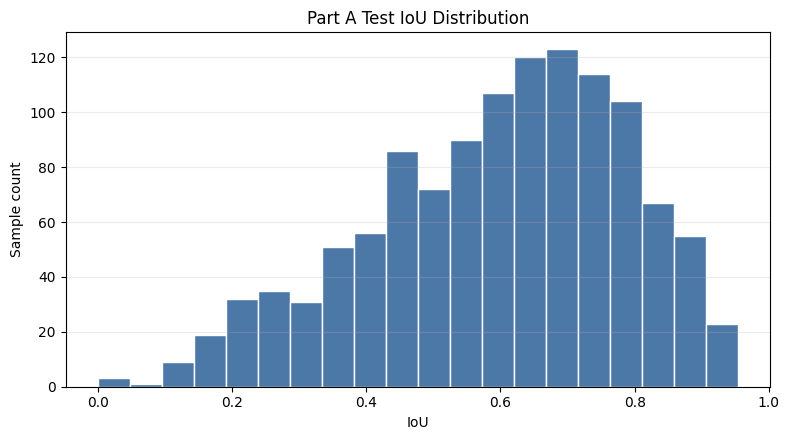

Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/figures/partA_test_iou_histogram.png


In [103]:
if part_a_test_ground_truth:
    part_a_test_error_records = []
    for check_id, gt_boxes in part_a_test_ground_truth.items():
        for class_id in [1, 0]:
            predicted_box = part_a_test_predictions[check_id][class_id]
            true_box = gt_boxes[class_id]
            iou_value = calculate_iou(predicted_box, true_box)
            part_a_test_error_records.append({
                "check_id": check_id,
                "source_filename": test_source_filenames.get(check_id, check_id + ".tif"),
                "class_id": class_id,
                "class_name": CLASS_NAMES[class_id],
                "iou": iou_value,
                "predicted_box": predicted_box,
                "true_box": true_box,
                "missed": predicted_box == [0, 0, 0, 0],
            })

    part_a_test_error_records = sorted(part_a_test_error_records, key=lambda row: (row["iou"], row["check_id"]))
    save_dataframe(pd.DataFrame(part_a_test_error_records), RESULTS_TABLES_DIR / "partA_test_detection_error_analysis.csv", show=False)
    write_error_json(PART_A_TEST_ERRORS_JSON, part_a_test_error_records)
    plot_metric_histogram(
        [record["iou"] for record in part_a_test_error_records],
        "Part A Test IoU Distribution",
        "IoU",
        RESULTS_FIGURES_DIR / "partA_test_iou_histogram.png",
        bins=20,
    )
else:
    part_a_test_error_records = []
    print("No test bounding-box ground truth available for Part A error analysis.")


In [104]:
if part_a_test_error_records:
    display_error_examples(
        part_a_test_error_records,
        ["check_id", "class_name", "iou", "missed", "predicted_box", "true_box"],
        max_examples=10,
    )
    part_a_test_correct = [record for record in part_a_test_error_records if record["iou"] >= 0.90]
    print("High-quality test detections at IoU >= 0.90:", len(part_a_test_correct))


,check_id,class_name,iou,missed,predicted_box,true_box
0,ac03241,legal_amount,0.000000,True,"[0, 0, 0, 0]","[336, 228, 796, 292]"
1,ac03379,courtesy_amount,0.000000,True,"[0, 0, 0, 0]","[914, 224, 1140, 268]"
2,ac04084,courtesy_amount,0.000000,True,"[0, 0, 0, 0]","[906, 220, 1136, 266]"
3,ac03620,courtesy_amount,0.082484,False,"[920, 245, 971, 265]","[914, 222, 1143, 276]"
4,ac03490,courtesy_amount,0.119048,False,"[915, 241, 975, 265]","[911, 220, 1135, 274]"
5,ac03743,courtesy_amount,0.124082,False,"[920, 234, 972, 260]","[911, 216, 1138, 264]"
6,ac04139,courtesy_amount,0.127324,False,"[940, 228, 1000, 253]","[903, 220, 1134, 271]"
7,ac03730,courtesy_amount,0.127706,False,"[915, 234, 974, 261]","[911, 218, 1142, 272]"
8,ac04167,courtesy_amount,0.131092,False,"[910, 233, 964, 260]","[912, 215, 1134, 263]"
9,ac03387,courtesy_amount,0.131958,False,"[959, 229, 1016, 251]","[915, 219, 1136, 262]"


High-quality test detections at IoU >= 0.90: 28


### Part B Test Courtesy Recognition


In [105]:
def load_test_courtesy_ground_truth(path):
    if path is None:
        return {}

    labels = {}
    for line_number, line in enumerate(Path(path).read_text(encoding="utf-8-sig").splitlines(), start=1):
        if not line.strip():
            continue
        parts = split_amount_label_line(line)
        if parts is None:
            raise ValueError(f"Malformed courtesy test label line {line_number}: {line}")
        labels[normalize_check_id(parts[0], prefix="C")] = parse_courtesy_label_digits(parts[1])
    return labels

part_b_test_checkpoint = load_torch_checkpoint(PART_B_BEST_MODEL)
part_b_test_model = CourtesyCRNN(num_classes=int(part_b_test_checkpoint.get("num_classes", 11))).to(device)
part_b_test_model.load_state_dict(part_b_test_checkpoint["model_state_dict"])
part_b_test_model.eval()
part_b_test_blank_idx = int(part_b_test_checkpoint.get("blank_idx", COURTESY_BLANK_IDX))
part_b_test_image_size = tuple(part_b_test_checkpoint.get("image_size", COURTESY_IMAGE_SIZE))
part_b_test_transform = transforms.Compose([
    transforms.Resize(part_b_test_image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])
part_b_test_predictions = {}
part_b_test_lines = []

with torch.no_grad():
    for crop_path in sorted(TEST_COURTESY_CROPS_DIR.glob("*.tif")):
        check_id = normalize_check_id(crop_path.name, prefix="C")
        image = Image.open(crop_path).convert("L")
        tensor = part_b_test_transform(image).unsqueeze(0).to(device)
        output = part_b_test_model(tensor)
        prediction = decode_courtesy_batch(output, blank_idx=part_b_test_blank_idx)[0]
        part_b_test_predictions[check_id] = prediction
        part_b_test_lines.append(f"{test_source_filenames.get(check_id, check_id + '.tif')} {prediction}")

PART_B_TEST_OUTPUT.write_text("\n".join(part_b_test_lines) + "\n", encoding="utf-8")
part_b_test_metrics = [
    "PART B TEST - COURTESY RECOGNITION",
    f"Courtesy crops processed: {len(part_b_test_lines)}",
]

test_courtesy_ground_truth = load_test_courtesy_ground_truth(TEST_COURTESY_LABELS)


In [106]:
if test_courtesy_ground_truth:
    common_ids = sorted(set(part_b_test_predictions) & set(test_courtesy_ground_truth))
    total_digits = 0
    total_errors = 0
    error_counts = {0: 0, 1: 0, "2+": 0}

    for check_id in common_ids:
        predicted = part_b_test_predictions[check_id]
        ground_truth = test_courtesy_ground_truth[check_id]
        errors = editdistance.eval(predicted, ground_truth)
        total_digits += len(ground_truth)
        total_errors += errors
        if errors == 0:
            error_counts[0] += 1
        elif errors == 1:
            error_counts[1] += 1
        else:
            error_counts["2+"] += 1

    if common_ids and total_digits:
        accuracy = (1 - total_errors / total_digits) * 100
        part_b_test_metrics.extend([
            f"Ground-truth rows matched: {len(common_ids)}",
            f"Total ground-truth digits: {total_digits}",
            f"Total edit errors: {total_errors}",
            f"Digit-level accuracy (%): {accuracy:.4f}",
            f"Amounts with no errors: {error_counts[0]} ({error_counts[0] / len(common_ids) * 100:.4f}%)",
            f"Amounts with one error: {error_counts[1]} ({error_counts[1] / len(common_ids) * 100:.4f}%)",
            f"Amounts with two or more errors: {error_counts['2+']} ({error_counts['2+'] / len(common_ids) * 100:.4f}%)",
        ])

PART_B_TEST_METRICS.write_text("\n".join(part_b_test_metrics) + "\n", encoding="utf-8")
print("\n".join(part_b_test_metrics))
print("Part-B test output:", PART_B_TEST_OUTPUT)
print("Part-B test metrics:", PART_B_TEST_METRICS)

for line in part_b_test_lines[:5]:
    print(" ", line)


PART B TEST - COURTESY RECOGNITION
Courtesy crops processed: 598
Ground-truth rows matched: 598
Total ground-truth digits: 2599
Total edit errors: 105
Digit-level accuracy (%): 95.9600
Amounts with no errors: 506 (84.6154%)
Amounts with one error: 81 (13.5452%)
Amounts with two or more errors: 11 (1.8395%)
Part-B test output: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/partB_test_output.txt
Part-B test metrics: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/partB_test_metrics.txt
  ac03000.tif 10000
  ac03001.tif 50000
  ac03003.tif 5000
  ac03005.tif 173387
  ac03006.tif 1000


### Part B Test Error Analysis
This mirrors the validation analysis: edit operations, digit confusion matrix with insertions/deletions, correct examples, incorrect examples, and crop visualizations.


In [107]:
if test_courtesy_ground_truth:
    part_b_test_analysis_records = []
    for check_id in sorted(set(test_courtesy_ground_truth) | set(part_b_test_predictions)):
        true_digits = test_courtesy_ground_truth.get(check_id, "")
        predicted = part_b_test_predictions.get(check_id, "")
        summary = alignment_summary(true_digits, predicted)
        part_b_test_analysis_records.append({
            "check_id": check_id,
            "source_filename": test_source_filenames.get(check_id, check_id + ".tif"),
            "true_label": true_digits,
            "predicted_label": predicted,
            "edit_count": summary["edit_count"],
            "insertions": summary["insertions"],
            "deletions": summary["deletions"],
            "substitutions": summary["substitutions"],
            "operations": summary["operations"],
            "image_path": str(TEST_COURTESY_CROPS_DIR / f"C{check_id}.tif"),
        })

    part_b_test_error_records = sorted(
        [record for record in part_b_test_analysis_records if record["edit_count"] > 0],
        key=lambda row: (-row["edit_count"], row["check_id"]),
    )
    part_b_test_correct_records = [record for record in part_b_test_analysis_records if record["edit_count"] == 0]
    save_dataframe(pd.DataFrame(part_b_test_analysis_records), RESULTS_TABLES_DIR / "partB_test_error_analysis.csv", show=False)
    write_error_json(PART_B_TEST_ERRORS_JSON, part_b_test_error_records)
else:
    part_b_test_analysis_records = []
    part_b_test_error_records = []
    part_b_test_correct_records = []
    print("No courtesy test labels available for Part B error analysis.")


Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/tables/partB_test_error_analysis.csv
Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/error_analysis/partB_test_courtesy_errors.json


,check_id,true_label,predicted_label,edit_count,insertions,deletions,substitutions,operations
0,ac03379,5000,,4,0,4,0,D:5; D:0; D:0; D:0
1,ac03862,1000,1,3,0,3,0,D:0; D:0; D:0
2,ac03866,5000,5788,3,0,0,3,S:0->7; S:0->8; S:0->8
3,ac04084,900,,3,0,3,0,D:9; D:0; D:0
4,ac03168,5000,50,2,0,2,0,D:0; D:0
5,ac03244,10000,2100000,2,2,0,0,I:2; I:0
6,ac03354,10000,700000,2,1,0,1,I:7; S:1->0
7,ac03646,140000,1000,2,0,2,0,D:4; D:0
8,ac03660,22812,28125,2,1,1,0,D:2; I:5
9,ac03878,1911,311,2,0,1,1,D:1; S:9->3


,check_id,true_label,predicted_label,edit_count
0,ac03000,10000,10000,0
1,ac03003,5000,5000,0
2,ac03006,1000,1000,0
3,ac03007,12000,12000,0
4,ac03014,2800,2800,0
5,ac03015,25000,25000,0
6,ac03020,3605,3605,0
7,ac03021,2000,2000,0
8,ac03023,5000,5000,0
9,ac03025,1475,1475,0


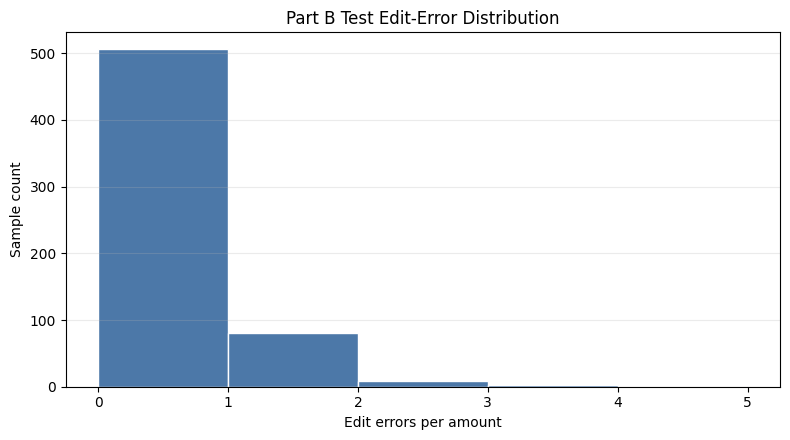

Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/figures/partB_test_edit_error_histogram.png


In [108]:
if part_b_test_analysis_records:
    display_error_examples(
        part_b_test_error_records,
        ["check_id", "true_label", "predicted_label", "edit_count", "insertions", "deletions", "substitutions", "operations"],
        max_examples=10,
    )
    display_error_examples(
        part_b_test_correct_records[:10],
        ["check_id", "true_label", "predicted_label", "edit_count"],
        max_examples=10,
    )
    plot_metric_histogram(
        [record["edit_count"] for record in part_b_test_analysis_records],
        "Part B Test Edit-Error Distribution",
        "Edit errors per amount",
        RESULTS_FIGURES_DIR / "partB_test_edit_error_histogram.png",
        bins=range(0, max(record["edit_count"] for record in part_b_test_analysis_records) + 2),
    )


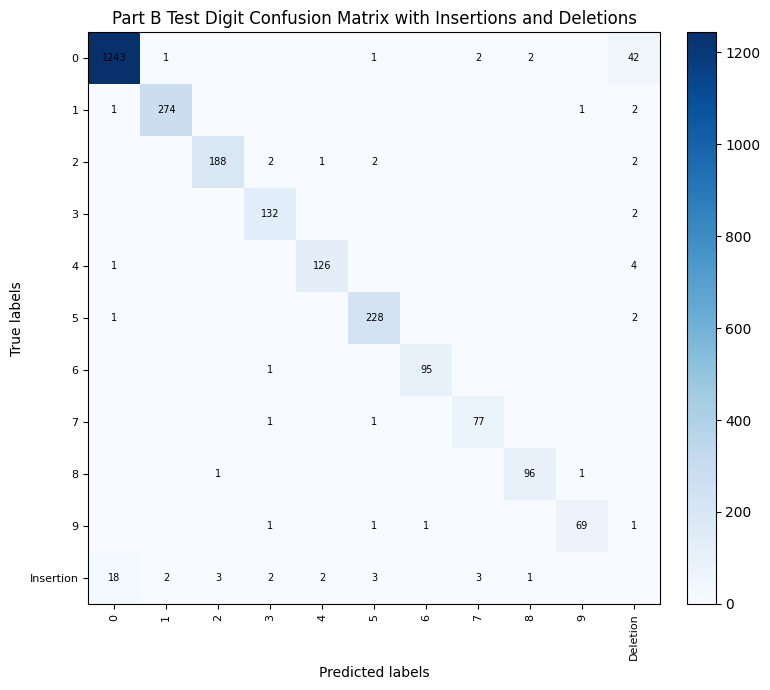

Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/error_analysis/partB_test_digit_confusion_matrix.png


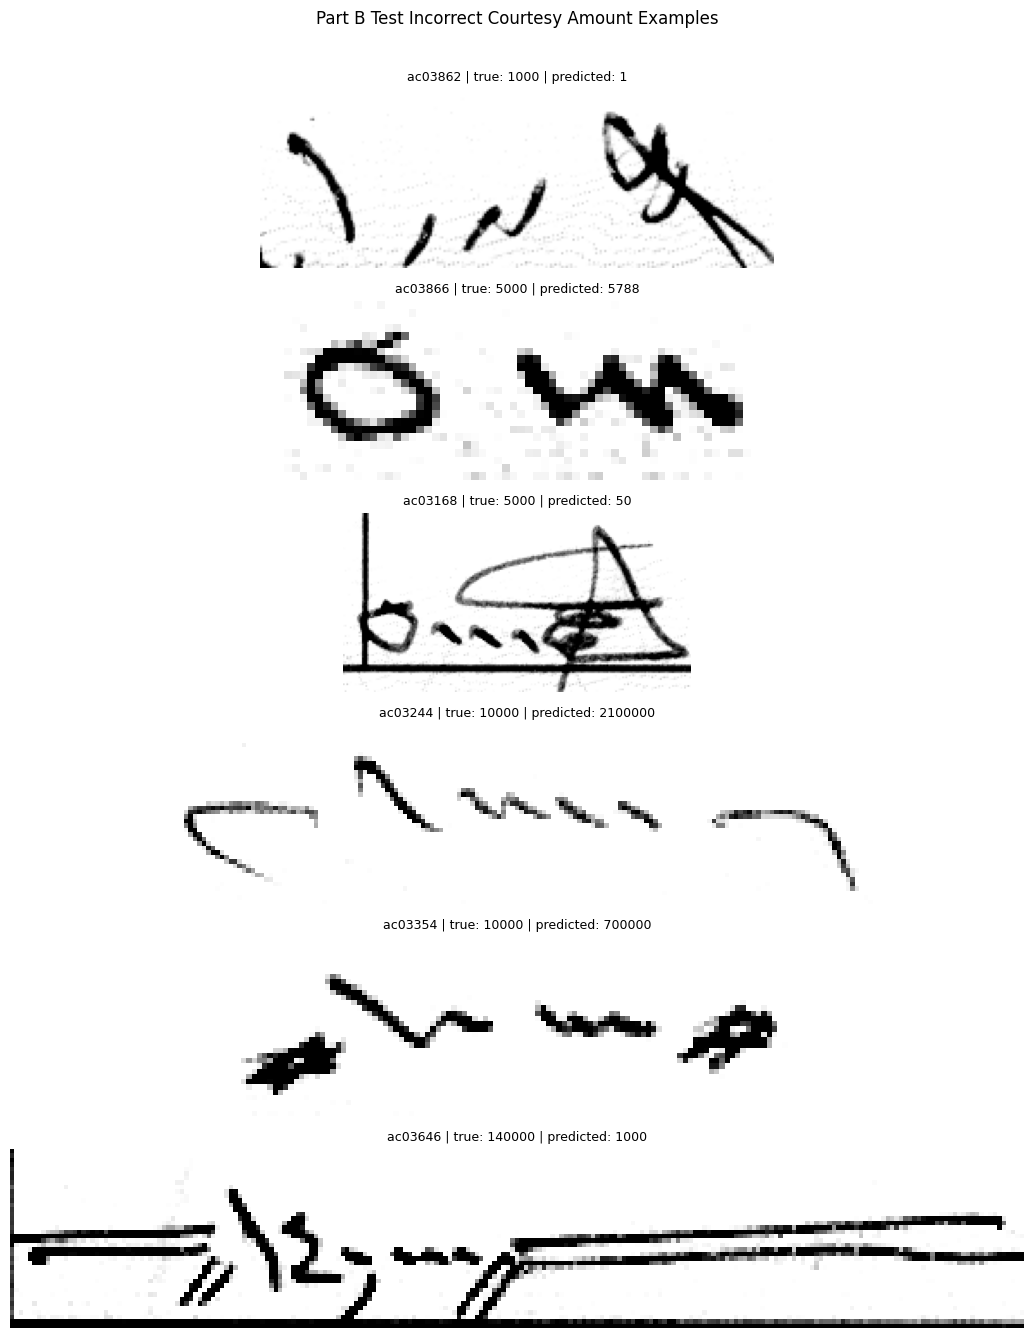

In [109]:
if part_b_test_analysis_records:
    part_b_test_confusion = build_confusion_matrix(
        [record["true_label"] for record in part_b_test_analysis_records],
        [record["predicted_label"] for record in part_b_test_analysis_records],
        labels=[str(value) for value in range(10)],
    )
    plot_confusion_matrix(
        part_b_test_confusion,
        "Part B Test Digit Confusion Matrix with Insertions and Deletions",
        ERROR_ANALYSIS_DIR / "partB_test_digit_confusion_matrix.png",
    )
    show_crop_examples(
        part_b_test_error_records,
        image_key="image_path",
        true_key="true_label",
        pred_key="predicted_label",
        title="Part B Test Incorrect Courtesy Amount Examples",
        max_examples=6,
    )


### Part C Test Legal Recognition


In [110]:
def load_test_legal_ground_truth(path):
    if path is None:
        return {}

    labels = {}
    for line_number, line in enumerate(Path(path).read_text(encoding="utf-8-sig").splitlines(), start=1):
        if not line.strip():
            continue
        parts = split_amount_label_line(line)
        if parts is None:
            raise ValueError(f"Malformed legal test label line {line_number}: {line}")
        tokens = parse_legal_tokens(parts[1])
        labels[normalize_check_id(parts[0], prefix="L")] = {"tokens": tokens, "text": legal_text_from_tokens(tokens)}
    return labels

part_c_test_checkpoint = load_torch_checkpoint(PART_C_BEST_MODEL)
part_c_test_idx_to_char = {int(key): value for key, value in part_c_test_checkpoint["idx_to_char"].items()}
part_c_test_model = LegalCRNN(
    num_classes=int(part_c_test_checkpoint.get("num_classes", len(part_c_test_idx_to_char) + 1)),
    sequence_steps=int(part_c_test_checkpoint.get("sequence_steps", LEGAL_SEQUENCE_STEPS)),
).to(device)
part_c_test_model.load_state_dict(part_c_test_checkpoint["model_state_dict"])
part_c_test_model.eval()
part_c_test_blank_idx = int(part_c_test_checkpoint.get("blank_idx", LEGAL_BLANK_IDX))
part_c_test_image_size = tuple(part_c_test_checkpoint.get("image_size", LEGAL_IMAGE_SIZE))
part_c_test_transform = transforms.Compose([
    transforms.Resize(part_c_test_image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])
part_c_test_predictions = {}
part_c_test_lines = []

with torch.no_grad():
    for crop_path in sorted(TEST_LEGAL_CROPS_DIR.glob("*.tif")):
        check_id = normalize_check_id(crop_path.name, prefix="L")
        image = ImageOps.mirror(Image.open(crop_path).convert("L"))
        tensor = part_c_test_transform(image).unsqueeze(0).to(device)
        output = part_c_test_model(tensor)
        prediction = decode_legal_batch(output, part_c_test_idx_to_char, blank_idx=part_c_test_blank_idx)[0]
        part_c_test_predictions[check_id] = prediction
        part_c_test_lines.append(f"{test_source_filenames.get(check_id, check_id + '.tif')} {prediction}")

PART_C_TEST_OUTPUT.write_text("\n".join(part_c_test_lines) + "\n", encoding="utf-8")
part_c_test_metrics = [
    "PART C TEST - LEGAL RECOGNITION",
    f"Legal crops processed: {len(part_c_test_lines)}",
]

test_legal_ground_truth = load_test_legal_ground_truth(TEST_LEGAL_LABELS)


In [111]:
legal_token_vocabulary = part_c_test_checkpoint.get("token_vocabulary", [])

if test_legal_ground_truth:
    common_ids = sorted(set(part_c_test_predictions) & set(test_legal_ground_truth))
    total_characters = 0
    total_character_errors = 0
    total_tokens = 0
    total_token_errors = 0
    exact_matches = 0

    for check_id in common_ids:
        predicted = part_c_test_predictions[check_id]
        ground_truth_text = test_legal_ground_truth[check_id]["text"]
        ground_truth_tokens = test_legal_ground_truth[check_id]["tokens"]
        char_errors = editdistance.eval(predicted, ground_truth_text)
        total_characters += len(ground_truth_text)
        total_character_errors += char_errors
        exact_matches += int(char_errors == 0)
        predicted_tokens = segment_with_legal_vocabulary(predicted, legal_token_vocabulary) if legal_token_vocabulary else list(predicted)
        total_tokens += len(ground_truth_tokens)
        total_token_errors += editdistance.eval(predicted_tokens, ground_truth_tokens)

    if common_ids and total_characters and total_tokens:
        cer = total_character_errors / total_characters * 100
        wer = total_token_errors / total_tokens * 100
        part_c_test_metrics.extend([
            f"Ground-truth rows matched: {len(common_ids)}",
            f"Total ground-truth characters: {total_characters}",
            f"Total character edit errors: {total_character_errors}",
            f"CER (%): {cer:.4f}",
            f"Total ground-truth legal tokens: {total_tokens}",
            f"Total token edit errors: {total_token_errors}",
            f"WER / token error rate (%): {wer:.4f}",
            f"Exact character-sequence matches: {exact_matches} ({exact_matches / len(common_ids) * 100:.4f}%)",
        ])

PART_C_TEST_METRICS.write_text("\n".join(part_c_test_metrics) + "\n", encoding="utf-8")
print("\n".join(part_c_test_metrics))
print("Part-C test output:", PART_C_TEST_OUTPUT)
print("Part-C test metrics:", PART_C_TEST_METRICS)

for line in part_c_test_lines[:5]:
    print(" ", line)


PART C TEST - LEGAL RECOGNITION
Legal crops processed: 599
Ground-truth rows matched: 599
Total ground-truth characters: 14564
Total character edit errors: 1580
CER (%): 10.8487
Total ground-truth legal tokens: 7629
Total token edit errors: 5029
WER / token error rate (%): 65.9195
Exact character-sequence matches: 134 (22.3706%)
Part-C test output: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/partC_test_output.txt
Part-C test metrics: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/partC_test_metrics.txt
  ac03000.tif عشرةالفريالفقطلاغير
  ac03001.tif خمسةالافريالفقطغير
  ac03003.tif خمسةالافرياللاغير
  ac03005.tif فقطسبعةعشرةالفوثاثايةوخمسةولاثونرياربعولونهلاللاغير
  ac03006.tif فقطالفرياللاغير


### Part C Test Error Analysis
This saves legal-recognition character/token errors, a character confusion matrix with insertions/deletions, correct examples, incorrect examples, and legal crop visualizations.


In [112]:
if test_legal_ground_truth:
    part_c_test_analysis_records = []
    for check_id in sorted(set(test_legal_ground_truth) | set(part_c_test_predictions)):
        label = test_legal_ground_truth.get(check_id, {"tokens": [], "text": ""})
        true_text = label["text"]
        true_tokens = label["tokens"]
        predicted = part_c_test_predictions.get(check_id, "")
        predicted_tokens = segment_with_legal_vocabulary(predicted, legal_token_vocabulary) if legal_token_vocabulary else list(predicted)
        char_summary = alignment_summary(true_text, predicted)
        token_summary = alignment_summary(true_tokens, predicted_tokens)
        part_c_test_analysis_records.append({
			"check_id": check_id,
            "source_filename": test_source_filenames.get(check_id, check_id + ".tif"),
            "true_text": true_text,
            "predicted_text": predicted,
            "true_tokens": " | ".join(true_tokens),
            "predicted_tokens": " | ".join(predicted_tokens),
            "character_errors": char_summary["edit_count"],
            "token_errors": token_summary["edit_count"],
            "operations": token_summary["operations"],
            "image_path": str(TEST_LEGAL_CROPS_DIR / f"L{check_id}.tif"),
        })

    part_c_test_error_records = sorted(
        [record for record in part_c_test_analysis_records if record["token_errors"] > 0],
        key=lambda row: (-row["token_errors"], -row["character_errors"], row["check_id"]),
    )
    part_c_test_correct_records = [record for record in part_c_test_analysis_records if record["character_errors"] == 0]
    save_dataframe(pd.DataFrame(part_c_test_analysis_records), RESULTS_TABLES_DIR / "partC_test_error_analysis.csv", show=False)
    write_error_json(PART_C_TEST_ERRORS_JSON, part_c_test_error_records)
else:
    part_c_test_analysis_records = []
    part_c_test_error_records = []
    part_c_test_correct_records = []
    print("No legal test labels available for Part C error analysis.")


Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/tables/partC_test_error_analysis.csv
Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/error_analysis/partC_test_legal_errors.json


,check_id,true_text,predicted_text,token_errors,character_errors,true_tokens,predicted_tokens,operations
0,ac03005,فقطسبعةعشرةالفاوثلاثمايهوخمسةوثلاثونريالاوسبعة...,فقطسبعةعشرةالفوثاثايةوخمسةولاثونرياربعولونهلال...,22,20,فقط | سبعة | عشر | ة | أ | لفا | و | ثلا | ثما...,فقط | سبع | ة | عشر | ة | الف | و | ث | ا | ث ...,I:سبع; S:سبعة->ة; I:الف; I:و; S:أ->ث; S:لفا->ا...
1,ac03084,فقطاربعمايةوستهوعشرونالفوخمسمايةوستهعشرريالا,فقطسبعمايةنالفوسمةسةوسنفرلاغير,18,24,فقط | ا | ر | بعما | ئة | و | سته | و | عشر | ...,فقط | سبعماية | ن | الف | و | س | م | ة | س | ...,D:ا; D:ر; D:بعما; S:ئة->سبعماية; S:و->ن; S:سته...
2,ac03899,فقطثلاثهالافوتسعمايهخمسهوثلاثونرياللاغير,فقطثلاثةالافلسير,17,26,فقط | ثلا | ثه | ا | لا | ف | و | تسعما | ئه |...,فقط | ثلاث | ة | الاف | ل | س | ي | ر,D:ثلا; D:ثه; D:ا; D:لا; D:ف; D:و; D:تسعما; S:ئ...
3,ac03859,اربعهالافوخمسمايهريالسبعوديفقطلاغير,اربعةالافوخمسمايهراعولونللر,17,13,ا | ر | بعه | ا | لا | ف | و | خمسما | ئه | ر ...,اربعة | الاف | و | خمسمايه | ر | ا | ع | و | ل...,D:ا; D:ر; D:بعه; D:ا; S:لا->اربعة; S:ف->الاف; ...
4,ac03664,تسعهالافوسبعمايهوثمانيهوتسعونريالا,ععةالافوسبعمايةوثمانيوتعسعونريالفقطاغ,17,10,تسعه | ا | لا | ف | و | سبعما | ئه | و | ثما |...,ع | ع | ة | الاف | و | سبعماية | و | ثماني | و...,S:تسعه->ع; S:ا->ع; S:لا->ة; S:ف->الاف; I:سبعما...
5,ac03143,فقطثلاثةالافوثمانمايهواربعهواربعونرياللاغير,فقطثلاثةالافوثمانمايةواربعةواربعونرياللاغير,17,2,فقط | ثلا | ثة | ا | لا | ف | و | ثما | نما | ...,فقط | ثلاث | ة | الاف | و | ثمانماي | ة | و | ...,D:ثلا; D:ثة; S:ا->ثلاث; S:لا->ة; S:ف->الاف; D:...
6,ac03722,فقطثمانيهوسبعونالفوخمسمايهوستونريال,ثقلثمايةوستونالفوخمسمايةوستونرياللاغير,16,12,فقط | ثما | نيه | و | سبعو | ن | أ | لف | و | ...,ث | ق | ل | ثم | ا | ي | ة | و | ست | و | ن | ...,I:ث; I:ق; I:ل; I:ثم; S:فقط->ا; S:ثما->ي; S:نيه...
7,ac03284,فقطثمانيةوستينالفاوثمانمايةوعشرينريالا,فقطثمايوستةالفاومانمايةوعشونرياللاغير,16,11,فقط | ثما | نية | و | ستين | أ | لفاً | و | ثم...,فقط | ثم | ا | ي | و | ست | ة | الفا | و | م |...,I:ثم; S:ثما->ا; S:نية->ي; S:ستين->ست; S:أ->ة; ...
8,ac04113,مايةالفوثمانيهمايهاربعةوثمانونريالافقطلاغير,مايتالفوثمانومايهواربعهوثمانونريالللاغير,16,9,ما | ئة | أ | لف | و | ثما | نيه | ما | ئه | أ...,مايتا | لف | و | ثمان | و | مايه | و | اربعه |...,D:ما; D:ئة; S:أ->مايتا; D:ثما; D:نيه; S:ما->ثم...
9,ac03148,فقطثلاثةالافوثلاثمايةواثنانوثمانونريال,فقطاثاثةالافوثلاثمايةواثنانوثمانونرياللغر,16,5,فقط | ثلا | ثة | ا | لا | ف | و | ثلا | ثما | ...,فقط | ا | ث | ا | ث | ة | الاف | و | ثلاثماية ...,D:ثلا; D:ثة; D:لا; S:ف->ث; S:و->ا; S:ثلا->ث; S...


,check_id,true_text,predicted_text,character_errors
0,ac03003,خمسةالافرياللاغير,خمسةالافرياللاغير,0
1,ac03006,فقطالفرياللاغير,فقطالفرياللاغير,0
2,ac03008,فقطاربعمايةوخمسونرياللاغير,فقطاربعمايةوخمسونرياللاغير,0
3,ac03014,فقطالفانوثمانمايةرياللاغير,فقطالفانوثمانمايةرياللاغير,0
4,ac03015,فقطخمسةوعشرونالفرياللاغير,فقطخمسةوعشرونالفرياللاغير,0
5,ac03021,الفانريالفقطلاغير,الفانريالفقطلاغير,0
6,ac03027,فقطخمسةوتسعونالفرياللاغير,فقطخمسةوتسعونالفرياللاغير,0
7,ac03035,فقطخمسمايةرياللاغير,فقطخمسمايةرياللاغير,0
8,ac03044,ثلاثةالافريالفقطلاغير,ثلاثةالافريالفقطلاغير,0
9,ac03047,مايةالفريالفقط,مايةالفريالفقط,0


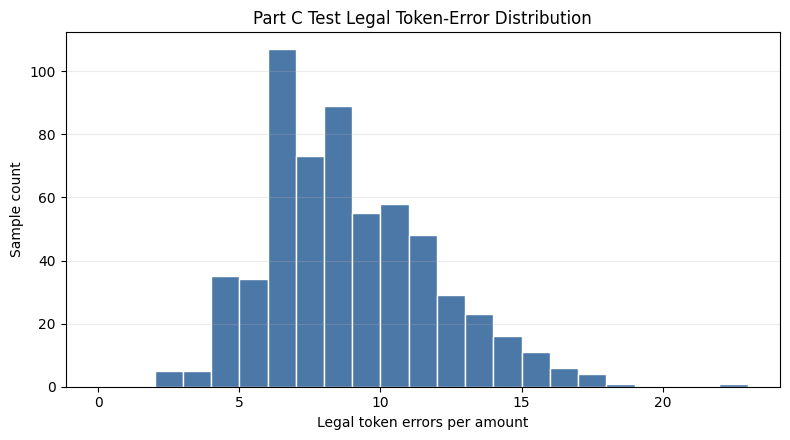

Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/figures/partC_test_token_error_histogram.png


In [113]:
if part_c_test_analysis_records:
    display_error_examples(
        part_c_test_error_records,
        ["check_id", "true_text", "predicted_text", "token_errors", "character_errors", "true_tokens", "predicted_tokens", "operations"],
        max_examples=10,
    )
    display_error_examples(
        part_c_test_correct_records[:10],
        ["check_id", "true_text", "predicted_text", "character_errors"],
        max_examples=10,
    )
    plot_metric_histogram(
        [record["token_errors"] for record in part_c_test_analysis_records],
        "Part C Test Legal Token-Error Distribution",
        "Legal token errors per amount",
        RESULTS_FIGURES_DIR / "partC_test_token_error_histogram.png",
        bins=range(0, max(record["token_errors"] for record in part_c_test_analysis_records) + 2),
    )


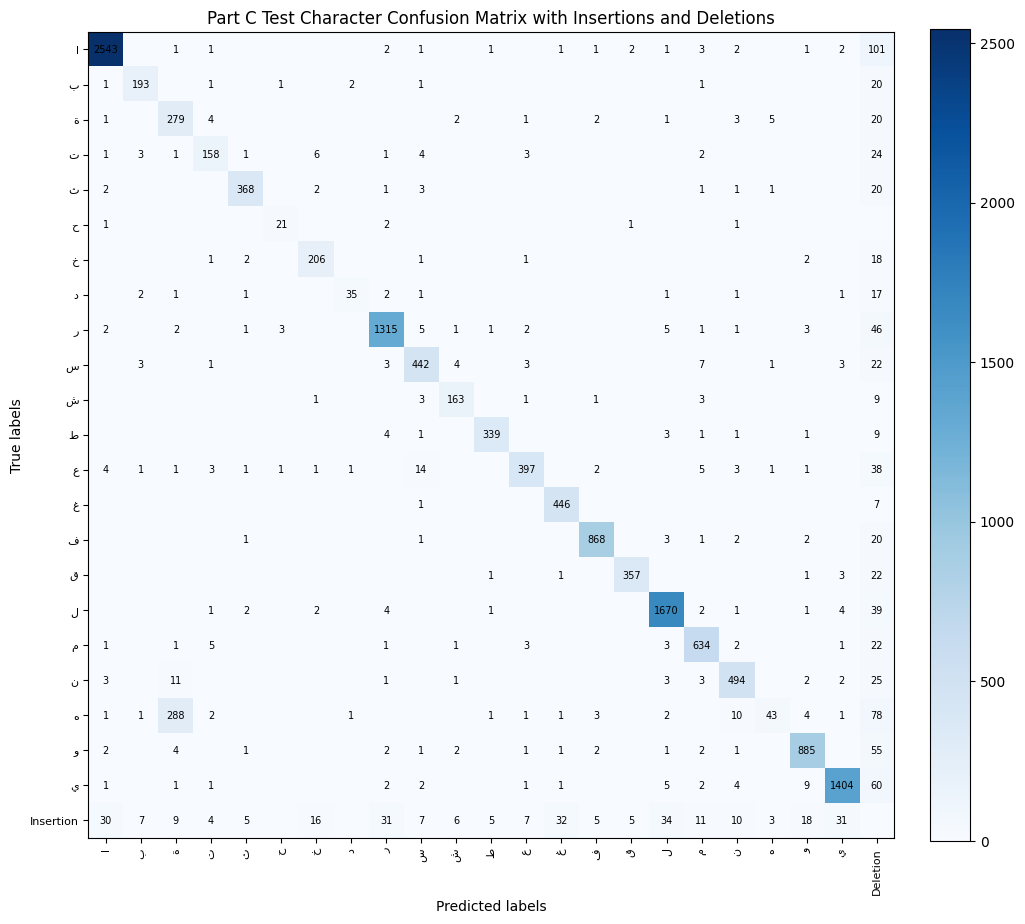

Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/error_analysis/partC_test_character_confusion_matrix.png


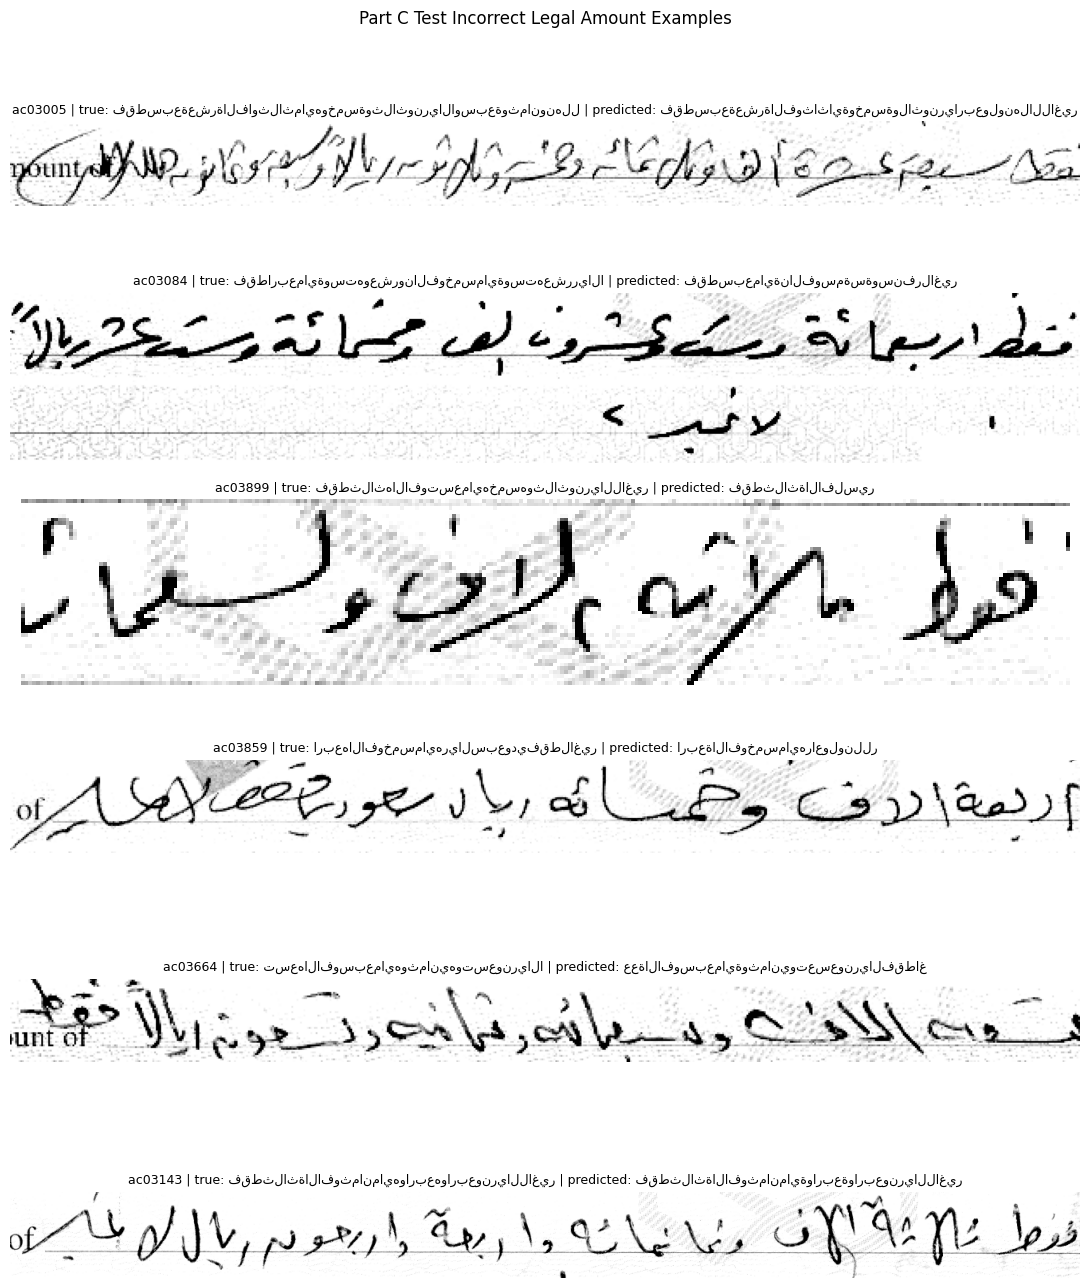

In [114]:
if part_c_test_analysis_records:
    part_c_test_char_labels = sorted({
        character
        for record in part_c_test_analysis_records
        for character in record["true_text"] + record["predicted_text"]
    })
    part_c_test_confusion = build_confusion_matrix(
        [record["true_text"] for record in part_c_test_analysis_records],
        [record["predicted_text"] for record in part_c_test_analysis_records],
        labels=part_c_test_char_labels,
    )
    plot_confusion_matrix(
        part_c_test_confusion,
        "Part C Test Character Confusion Matrix with Insertions and Deletions",
        ERROR_ANALYSIS_DIR / "partC_test_character_confusion_matrix.png",
    )
    show_crop_examples(
        part_c_test_error_records,
        image_key="image_path",
        true_key="true_text",
        pred_key="predicted_text",
        title="Part C Test Incorrect Legal Amount Examples",
        max_examples=6,
    )


### Part D Test Final Verification


In [115]:
courtesy_test_predictions_for_verification = load_prediction_file(PART_B_TEST_OUTPUT)
legal_test_predictions_for_verification = load_prediction_file(PART_C_TEST_OUTPUT)
test_courtesy_ground_truth = load_test_courtesy_ground_truth(TEST_COURTESY_LABELS)
expected_test_ids = sorted(test_source_filenames) or sorted(set(courtesy_test_predictions_for_verification) | set(legal_test_predictions_for_verification))
common_test_ids = sorted(set(expected_test_ids) & set(courtesy_test_predictions_for_verification) & set(legal_test_predictions_for_verification))
missing_test_legal = sorted(set(expected_test_ids) - set(legal_test_predictions_for_verification))
missing_test_courtesy = sorted(set(expected_test_ids) - set(courtesy_test_predictions_for_verification))
if not expected_test_ids:
    raise ValueError("No test IDs found for final verification.")
if not common_test_ids:
    raise ValueError("No matching Part B/Part C test prediction IDs found.")

test_details = []
for check_id in expected_test_ids:
    true_courtesy = test_courtesy_ground_truth.get(check_id)
    source_filename = test_source_filenames.get(check_id, check_id + ".tif")
    has_courtesy = check_id in courtesy_test_predictions_for_verification
    has_legal = check_id in legal_test_predictions_for_verification
    if not has_courtesy or not has_legal:
        missing_reason = "missing_both" if not has_courtesy and not has_legal else "missing_courtesy" if not has_courtesy else "missing_legal"
        test_details.append({
            "check_id": check_id,
            "source_filename": source_filename,
            "courtesy_raw": "",
            "courtesy_enhanced": "",
            "legal_converted": "",
            "legal_text": legal_test_predictions_for_verification.get(check_id, ""),
            "legal_tokens": [],
            "legal_candidates": [],
            "selected_by_courtesy": False,
            "courtesy_transform": "none",
            "missing_prediction": missing_reason,
            "verified": False,
            "true_courtesy": true_courtesy,
            "verified_against_ground_truth": False if true_courtesy is not None else None,
        })
        continue
    courtesy_digits = prediction_to_digits(courtesy_test_predictions_for_verification[check_id])
    conversion = convert_legal_amount(legal_test_predictions_for_verification[check_id], courtesy_digits=courtesy_digits)
    legal_digits = conversion["amount"]
    enhanced_courtesy, transform = enhance_courtesy_with_legal(courtesy_digits, legal_digits)
    verified = bool(legal_digits) and enhanced_courtesy == legal_digits
    test_details.append({
        "check_id": check_id,
        "source_filename": source_filename,
        "courtesy_raw": courtesy_digits,
        "courtesy_enhanced": enhanced_courtesy,
        "legal_converted": legal_digits,
        "legal_text": legal_test_predictions_for_verification[check_id],
        "legal_tokens": conversion["tokens"],
        "legal_candidates": conversion["candidates"],
        "selected_by_courtesy": conversion["selected_by_courtesy"],
        "courtesy_transform": transform,
        "missing_prediction": "",
        "verified": verified,
        "true_courtesy": true_courtesy,
        "verified_against_ground_truth": None if true_courtesy is None else verified and enhanced_courtesy == true_courtesy,
    })

total_test_checks = len(test_details)
verified_test_count = sum(item["verified"] for item in test_details)
changed_test_courtesy = sum(item["courtesy_transform"] != "none" for item in test_details)
selected_test_by_courtesy = sum(item["selected_by_courtesy"] for item in test_details)
empty_test_legal_conversions = sum(not item["legal_converted"] for item in test_details)
test_ground_truth_rows = [item for item in test_details if item["true_courtesy"] is not None]
test_ground_truth_correct = sum(item["verified_against_ground_truth"] is True for item in test_ground_truth_rows)
test_false_positive_count = sum(
    item["verified"] and item["true_courtesy"] is not None and item["courtesy_enhanced"] != item["true_courtesy"]
    for item in test_details
)


In [116]:
test_legal_ground_truth_correct = sum(
    item["true_courtesy"] is not None and item["legal_converted"] == item["true_courtesy"]
    for item in test_details
)
part_d_test_lines = [
    "\t".join([
        item["source_filename"],
        item["courtesy_raw"],
        item["courtesy_enhanced"],
        item["legal_converted"],
        "verified" if item["verified"] else "failed",
        item["legal_text"],
    ])
    for item in test_details
]

part_d_test_metrics = [
    "PART D TEST - FINAL VERIFICATION",
    f"Part B test predictions: {PART_B_TEST_OUTPUT}",
    f"Part C test predictions: {PART_C_TEST_OUTPUT}",
    f"Test checks evaluated: {total_test_checks}",
    f"Prediction pairs available: {len(common_test_ids)}",
    f"Missing legal predictions: {len(missing_test_legal)}",
    f"Missing courtesy predictions: {len(missing_test_courtesy)}",
    f"Verified matches: {verified_test_count} ({verified_test_count / total_test_checks * 100:.4f}%)",
    f"Failed matches: {total_test_checks - verified_test_count} ({(total_test_checks - verified_test_count) / total_test_checks * 100:.4f}%)",
    f"Empty legal conversions: {empty_test_legal_conversions}",
    f"Courtesy zero corrections: {changed_test_courtesy}",
    f"Legal conversion candidates selected using courtesy: {selected_test_by_courtesy}",
]

if test_ground_truth_rows:
    part_d_test_metrics.extend([
        f"Rows with ground-truth courtesy labels available: {len(test_ground_truth_rows)}",
        f"Legal conversion equal to ground truth: {test_legal_ground_truth_correct} ({test_legal_ground_truth_correct / len(test_ground_truth_rows) * 100:.4f}%)",
        f"Verified and equal to ground truth: {test_ground_truth_correct} ({test_ground_truth_correct / len(test_ground_truth_rows) * 100:.4f}%)",
        f"False positives against ground truth: {test_false_positive_count}",
    ])

PART_D_TEST_OUTPUT.write_text("\n".join(part_d_test_lines) + "\n", encoding="utf-8")
PART_D_TEST_METRICS.write_text("\n".join(part_d_test_metrics) + "\n", encoding="utf-8")
PART_D_TEST_DETAILS.write_text(json.dumps(test_details, ensure_ascii=False, indent=2), encoding="utf-8")
print("\n".join(part_d_test_metrics))
print("Part-D test output:", PART_D_TEST_OUTPUT)
print("Part-D test metrics:", PART_D_TEST_METRICS)
print("Part-D test details:", PART_D_TEST_DETAILS)

for line in part_d_test_lines[:5]:
    print(" ", line)


PART D TEST - FINAL VERIFICATION
Part B test predictions: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/partB_test_output.txt
Part C test predictions: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/partC_test_output.txt
Test checks evaluated: 600
Prediction pairs available: 597
Missing legal predictions: 1
Missing courtesy predictions: 2
Verified matches: 343 (57.1667%)
Failed matches: 257 (42.8333%)
Empty legal conversions: 57
Courtesy zero corrections: 29
Legal conversion candidates selected using courtesy: 314
Rows with ground-truth courtesy labels available: 600
Legal conversion equal to ground truth: 361 (60.1667%)
Verified and equal to ground truth: 336 (56.0000%)
False positives against ground truth: 7
Part-D test output: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/partD_test_output.txt
Part-D test metrics: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Pr

### Part D Test Error Analysis
This separates verification failures into missing predictions, empty legal conversions, legal-courtesy mismatches, false positives, and successful verified examples.


In [117]:
part_d_test_error_records = []
part_d_test_correct_records = []
for item in test_details:
    if item["verified"] and item.get("verified_against_ground_truth") is not False:
        part_d_test_correct_records.append(item)
        continue
    if item["missing_prediction"]:
        reason = item["missing_prediction"]
    elif not item["legal_converted"]:
        reason = "empty legal conversion"
    elif item["courtesy_enhanced"] != item["legal_converted"]:
        reason = "legal-courtesy mismatch"
    elif item.get("verified_against_ground_truth") is False:
        reason = "false positive against ground truth"
    else:
        reason = "verification failed"
    record = dict(item)
    record["failure_reason"] = reason
    part_d_test_error_records.append(record)

save_dataframe(pd.DataFrame(test_details), RESULTS_TABLES_DIR / "partD_test_verification_details.csv", show=False)
write_error_json(PART_D_TEST_ERRORS_JSON, part_d_test_error_records)
print("Part D test failures:", len(part_d_test_error_records))
print("Part D test verified examples:", len(part_d_test_correct_records))


Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/tables/partD_test_verification_details.csv
Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/error_analysis/partD_test_verification_errors.json
Part D test failures: 264
Part D test verified examples: 336


In [118]:
if part_d_test_error_records:
    display_error_examples(
        part_d_test_error_records,
        ["check_id", "failure_reason", "true_courtesy", "courtesy_raw", "courtesy_enhanced", "legal_converted", "legal_text"],
        max_examples=10,
    )

if part_d_test_correct_records:
    display_error_examples(
        part_d_test_correct_records[:10],
        ["check_id", "true_courtesy", "courtesy_raw", "courtesy_enhanced", "legal_converted", "legal_text"],
        max_examples=10,
    )



,check_id,failure_reason,true_courtesy,courtesy_raw,courtesy_enhanced,legal_converted,legal_text
0,ac03005,legal-courtesy mismatch,1733587,173387,173387,17305,فقطسبعةعشرةالفوثاثايةوخمسةولاثونرياربعولونهلال...
1,ac03007,legal-courtesy mismatch,12000,12000,12000,2,اثنيناعشرالفريالفقطلاغير
2,ac03008,legal-courtesy mismatch,450,5450,5450,450,فقطاربعمايةوخمسونرياللاغير
3,ac03023,empty legal conversion,5000,5000,5000,,فقطاثمةالافرياللاغير
4,ac03043,legal-courtesy mismatch,1500,1500,1500,5000,مالوخمسالفرياللاغير
5,ac03047,legal-courtesy mismatch,100000,100000,100000,1100,مايةالفريالفقط
6,ac03063,legal-courtesy mismatch,800,800,800,5,خمسامايةرياللاغير
7,ac03065,legal-courtesy mismatch,39000,39000,39000,12000,تسعةوثلاثةالفرياللاغير
8,ac03066,legal-courtesy mismatch,4200,4200,4200,4000,فقطاربعةالافومايتنريالاغير
9,ac03067,legal-courtesy mismatch,6860,6860,6860,6360,ستةالافوثلاثنمايةوستونريالاغ


,check_id,true_courtesy,courtesy_raw,courtesy_enhanced,legal_converted,legal_text
0,ac03000,10000,10000,10000,10000,عشرةالفريالفقطلاغير
1,ac03001,5000,50000,5000,5000,خمسةالافريالفقطغير
2,ac03003,5000,5000,5000,5000,خمسةالافرياللاغير
3,ac03006,1000,1000,1000,1000,فقطالفرياللاغير
4,ac03014,2800,2800,2800,2800,فقطالفانوثمانمايةرياللاغير
5,ac03015,25000,25000,25000,25000,فقطخمسةوعشرونالفرياللاغير
6,ac03020,3605,3605,3605,3605,فقطثلاثةالافوستمايةوخمسةرياللاغير
7,ac03021,2000,2000,2000,2000,الفانريالفقطلاغير
8,ac03025,1475,1475,1475,1475,الفواربعمايةوخمسةوسبعونرياللاغير
9,ac03027,95000,95000,95000,95000,فقطخمسةوتسعونالفرياللاغير


### Save Final Test Results Summary
This writes a compact test-set summary table when test annotations are available.


Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/tables/test_summary.csv
Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/json/test_summary.json


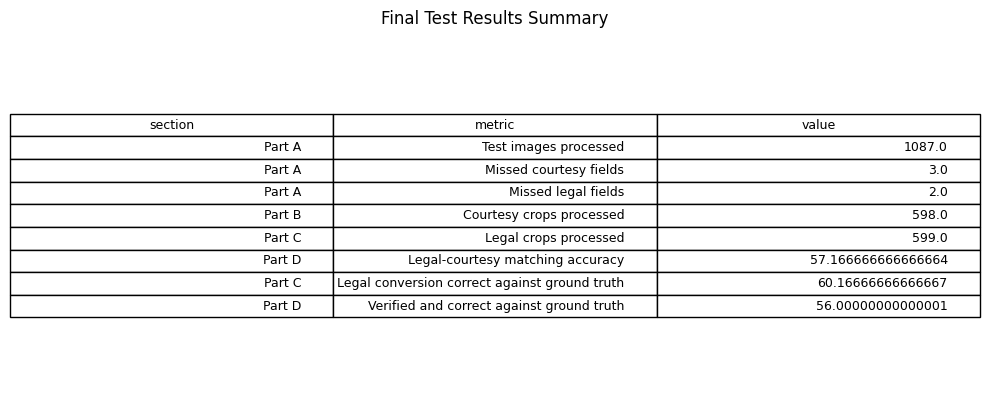

Saved: /content/drive/MyDrive/Arabic-Bank-Check-Amount-Extraction-and-Processing/results/figures/test_summary.png


In [119]:
test_summary_rows = [
    {"section": "Part A", "metric": "Test images processed", "value": len(part_a_test_lines)},
    {"section": "Part A", "metric": "Missed courtesy fields", "value": test_missed["courtesy_amount"]},
    {"section": "Part A", "metric": "Missed legal fields", "value": test_missed["legal_amount"]},
    {"section": "Part B", "metric": "Courtesy crops processed", "value": len(part_b_test_lines)},
    {"section": "Part C", "metric": "Legal crops processed", "value": len(part_c_test_lines)},
    {"section": "Part D", "metric": "Legal-courtesy matching accuracy", "value": verified_test_count / total_test_checks * 100},
]

if test_ground_truth_rows:
    test_summary_rows.extend([
        {
            "section": "Part C",
            "metric": "Legal conversion correct against ground truth",
            "value": test_legal_ground_truth_correct / len(test_ground_truth_rows) * 100,
        },
        {
            "section": "Part D",
            "metric": "Verified and correct against ground truth",
            "value": test_ground_truth_correct / len(test_ground_truth_rows) * 100,
        },
    ])

test_summary_frame = pd.DataFrame(test_summary_rows)
save_dataframe(test_summary_frame, TEST_SUMMARY_CSV)
save_metrics_json(TEST_SUMMARY_JSON, test_summary_rows)
save_table_image(test_summary_frame, "Final Test Results Summary", TEST_SUMMARY_PNG)
